AnomalyDetectorcomQC.ipynb

Célula inicial para cronometrar performance


# **1. Configuração do Ambiente e Acesso aos Dados**
Nesta etapa inicial, preparamos o ambiente de execução do Google Colab:
1.  **Instalação de Bibliotecas:** Instalamos o `lasio`, a biblioteca padrão da indústria para leitura e exportação de arquivos de perfil de poço (.LAS).
2.  **Montagem do Google Drive:** Conectamos ao Google Drive para acessar os arquivos de dados brutos armazenados na nuvem.
Bloco 2: Importação de Bibliotecas


In [1]:
!pip install -U lasio
!pip install ipytest

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **2. Importação de Bibliotecas Científicas**
Importamos as ferramentas necessárias para o processamento estatístico e visualização:
* **Manipulação de Dados:** `pandas` e `numpy` para estruturar os dados do poço em tabelas (DataFrames) e realizar operações vetoriais.
* **Estatística Robusta:**
    * `MinCovDet` (Scikit-Learn): Para estimar a covariância dos dados ignorando outliers (fundamental para a distância de Mahalanobis).
    * `chi2` (Scipy): Para calcular os limites estatísticos de corte (thresholds) baseados na distribuição Qui-quadrado.
    * `entropy`: Para análises de distribuição.
* **Visualização:** `matplotlib`, `seaborn` e `plotly` para criar gráficos de perfis (tracks) estáticos e interativos.


In [3]:
import lasio
import pandas as pd
import numpy as np
import os
import zipfile
import shutil
from google.colab import files
import io

In [4]:
#plotagem
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.colors as mcolors
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms

In [5]:
#estatística
from sklearn.covariance import MinCovDet
from scipy.stats import chi2, entropy
from itertools import combinations

In [6]:
import sklearn
import gc
import logging

In [7]:
# =============================================================================
# Configuração Centralizada de Logging
# =============================================================================
# canal de log padronizado, com
# níveis de severidade (DEBUG/INFO/WARNING/ERROR) e persistência em arquivo
# para fins de auditoria e reprodutibilidade.
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)-8s | %(name)s | %(message)s",
    handlers=[
        logging.StreamHandler(),                                # saída no próprio Colab
        logging.FileHandler('/content/pipeline_outliers.log'),  # log persistente para auditoria
    ],
    force=True,
)
logger = logging.getLogger("anomaly_detector")

In [8]:
P_ESPERADO = {
    'PETROFISICA_BASICA': 5,
    'ELEMENTARES': 4,
    'ESPECTRAL': 4,
    'RESSONANCIA': 4,
    'QUALITY_CONTROL': 2,
}

In [9]:
# Flag de isolamento do pipeline exploratório.
# Mantenha False para reproduzir exatamente os resultados reportados no artigo
# (Tabela 2 / Figura 3), que usam exclusivamente o pipeline oficial
# (calcular_mahalanobis_multigrupo + unificar_outliers_por_masks, alphamg=0.01).
EXECUTAR_PIPELINE_EXPLORATORIO = False

In [10]:
import time

In [11]:
# Registra o carimbo de data/hora do início da execução
inicio_notebook = time.time()
logger.info("⏱️ Cronômetro iniciado! A execução do notebook está sendo contabilizada.")

2026-09-04 21:37:33,655 | INFO     | anomaly_detector | ⏱️ Cronômetro iniciado! A execução do notebook está sendo contabilizada.


# Tratamento inicial dos dados





In [12]:
# =============================================================================
# Leitura do Arquivo LAS e Extração Inicial
# =============================================================================
# Defina o caminho para o seu arquivo LAS
file_path = '/content/drive/MyDrive/artigo outliers/dados_artigo/sapinhoa/9-SPS-95-SP_BASE.las'
lito_path = '/content/drive/MyDrive/artigo outliers/dados_artigo/litologias_P14.xlsx'

In [13]:
df_lito_p14 = pd.read_excel(lito_path)

In [14]:
# 3. Visualizar as primeiras linhas e informações básicas para confirmar a leitura
logger.info("--- Primeiras linhas do DataFrame litologias_P14 ---")
print(df_lito_p14.head())

2026-09-04 21:37:33,915 | INFO     | anomaly_detector | --- Primeiras linhas do DataFrame litologias_P14 ---


       MD  Lito Plug
0  5123.0        116
1  5125.0        118
2  5128.0         15
3  5129.0        116
4  5130.0        118


In [15]:
logger.info("\n--- Informações do DataFrame ---")
df_lito_p14.info()

2026-09-04 21:37:33,934 | INFO     | anomaly_detector | 
--- Informações do DataFrame ---


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   MD         249 non-null    float64
 1   Lito Plug  249 non-null    int64  
dtypes: float64(1), int64(1)
memory usage: 4.0 KB


---------------------------------------------------------------------------------------------------------

In [16]:
# 1. Dados do arquivo 'Litologias.xlsx - LITOLOGIA.csv'
# Substitua a string abaixo pelo caminho do seu arquivo se estiver no ambiente local ou Drive:
# Ex: csv_data = 'caminho/para/Litologias.xlsx - LITOLOGIA.csv'
lito_code_data = '/content/drive/MyDrive/artigo outliers/dados_artigo/Litologias.xlsx'

In [17]:
# 2. Carregar os dados para o DataFrame
# (Se estiver usando um arquivo físico, use: df_litologia = pd.read_csv(csv_data))
df_litologia = pd.read_excel(lito_code_data)

In [18]:
# 3. Tratamento e Limpeza (Garantir tipos de dados corretos para mapeamento)
df_litologia["CODIGO"] = df_litologia["CODIGO"].astype(int)
df_litologia["ROCK_NAME"] = df_litologia["ROCK_NAME"].str.strip()
df_litologia["ROCK_SG"] = df_litologia["ROCK_SG"].str.strip()
df_litologia["COLOR"] = df_litologia["COLOR"].str.strip()

In [19]:
# 4. Criar dicionários de mapeamento para facilitar a plotagem posterior
# Isso permite que você aplique as cores e nomes direto no DataFrame do poço usando o código da fácies
mapeamento_cores = dict(zip(df_litologia["CODIGO"], df_litologia["COLOR"]))
mapeamento_nomes = dict(zip(df_litologia["CODIGO"], df_litologia["ROCK_NAME"]))
mapeamento_siglas = dict(zip(df_litologia["CODIGO"], df_litologia["ROCK_SG"]))

In [20]:
# Visualizar o DataFrame estruturado
logger.info("DataFrame de Litologias:")
print(df_litologia.head())

2026-09-04 21:37:34,060 | INFO     | anomaly_detector | DataFrame de Litologias:


   CODIGO            ROCK_NAME ROCK_SG    COLOR
0       0          NAO REVISTO      NR  #000000
1       1             CALCARIO     CAL  #c0ffff
2       2  CALCARIO CRISTALINO     CLC  #00ffff
3       3              MARMORE     MRM  #ffc0ff
4       4              COQUINA     COQ  #add8e6


In [21]:
logger.info("\nExemplo de mapeamento de cores (Código -> Hex):")
print({k: mapeamento_cores[k] for k in list(mapeamento_cores)[:5]})

2026-09-04 21:37:34,080 | INFO     | anomaly_detector | 
Exemplo de mapeamento de cores (Código -> Hex):


{0: '#000000', 1: '#c0ffff', 2: '#00ffff', 3: '#ffc0ff', 4: '#add8e6'}


In [22]:
#-----------------------------------------------------------------------------------------------------------
try:
    las = lasio.read(file_path, encoding='latin-1')
    logger.info(f"Arquivo LAS '{las.well.WELL.value}' lido com sucesso!")
except FileNotFoundError:
    logger.error(f"ERRO: Arquivo não encontrado em '{file_path}'")
    logger.info("Por favor, verifique se o caminho está correto e se seu Google Drive está montado.")
except Exception as e:
    logger.error(f"Ocorreu um erro inesperado ao ler o arquivo LAS: {e}")

2026-09-04 21:37:34,103 | INFO     | lasio.reader | Opening /content/drive/MyDrive/artigo outliers/dados_artigo/sapinhoa/9-SPS-95-SP_BASE.las as latin-1 and treating errors with "replace"
2026-09-04 21:37:34,999 | INFO     | lasio.las | The read substitutions ['run-on(-)']have been removed as this file appears to contain hyphens.
2026-09-04 21:37:36,373 | INFO     | anomaly_detector | Arquivo LAS '9-BRSA-1037-SPS' lido com sucesso!


In [23]:
# =============================================================================
# Análise e Diagnóstico dos Dados Brutos
# =============================================================================
if 'las' in locals():
    logger.info("\n--- 📋 Informações do Cabeçalho do Poço (Header) ---")
    logger.info(f"Nome do Poço (WELL): {las.well.WELL.value}")
    logger.info(f"Empresa (COMP): {las.well.COMP.value}")
    logger.info(f"Campo (FLD): {las.well.FLD.value}")
    logger.info(f"Profundidade Inicial (STRT): {las.well.STRT.value} {las.well.STRT.unit}")
    logger.info(f"Profundidade Final (STOP): {las.well.STOP.value} {las.well.STOP.unit}")
    logger.info(f"Passo de Amostragem (STEP): {las.well.STEP.value} {las.well.STEP.unit}")
    logger.info(f"Valor Nulo (NULL): {las.well.NULL.value}")

    logger.info("\n--- 📏 Curvas Disponíveis no Arquivo LAS ---")
    # Imprime uma tabela com as curvas, unidades e descrições
    print(las.df().reset_index()[['DEPTH'] + list(las.df().columns)].head(1).to_string(index=False))
    logger.info("---------------------------------------------")
    for curve in las.curves:
        logger.info(f"- {curve.mnemonic:<10} ({curve.unit:<8}): {curve.descr}")

    # Converte o objeto LAS para um DataFrame do Pandas
    df_raw = las.df()

2026-09-04 21:37:36,397 | INFO     | anomaly_detector | 
--- 📋 Informações do Cabeçalho do Poço (Header) ---
2026-09-04 21:37:36,400 | INFO     | anomaly_detector | Nome do Poço (WELL): 9-BRSA-1037-SPS
2026-09-04 21:37:36,402 | INFO     | anomaly_detector | Empresa (COMP): PETROBRAS
2026-09-04 21:37:36,403 | INFO     | anomaly_detector | Campo (FLD): PA SPS-55
2026-09-04 21:37:36,404 | INFO     | anomaly_detector | Profundidade Inicial (STRT): 2150.0 M
2026-09-04 21:37:36,405 | INFO     | anomaly_detector | Profundidade Final (STOP): 6048.392 M
2026-09-04 21:37:36,407 | INFO     | anomaly_detector | Passo de Amostragem (STEP): 0.152 M
2026-09-04 21:37:36,408 | INFO     | anomaly_detector | Valor Nulo (NULL): -9999
2026-09-04 21:37:36,410 | INFO     | anomaly_detector | 
--- 📏 Curvas Disponíveis no Arquivo LAS ---
2026-09-04 21:37:36,560 | INFO     | anomaly_detector | ---------------------------------------------
2026-09-04 21:37:36,566 | INFO     | anomaly_detector | - DEPTH      (M  

 DEPTH  BS       DT  DWAL  DWCA  DWFE  DWSI     GR  HCAL  HDRA  HFK  HTHO  HURA  KSDR  KTIM  NMRE_FINAL  NMRFL_FINAL  NMRT_FINAL  NPHI  PE  RD  RHOB  RM  RS  TVDSS
2150.0 NaN -99999.0   NaN   NaN   NaN   NaN 20.662   NaN   NaN  NaN   NaN   NaN   NaN   NaN         NaN          NaN         NaN   NaN NaN NaN   NaN NaN NaN 2126.0


In [24]:
# =============================================================================
# Limpeza e Preparação do DataFrame (Pipeline de Tratamento)
# =============================================================================
if 'df_raw' in locals():
    logger.info("\n--- 🛠️ Iniciando Pipeline de Limpeza e Preparação ---")
    df_logs=df_raw.copy()
    #Padronização dos Nomes das Curvas (Mnemonics)
    rename_map = {
        'DEPT': 'DEPTH', 'GR_EDTC': 'GR', 'RHOB_EDTC': 'RHOB', 'NPHI_EDTC': 'NPHI',
        'DT_EDTC': 'DT', 'CALI_EDTC': 'CALI', 'PEF_EDTC': 'PEF', 'ATRT': 'RT',
        'DRHO_EDTC': 'DRHO',
    }
    df_logs.rename(columns=rename_map, inplace=True)
    logger.info("1. Nomes das curvas padronizados.")

    #Tratamento de Valores Nulos Padrão
    null_value = las.well.NULL.value
    df_logs.replace(null_value, np.nan, inplace=True)
    logger.info(f"2. Valor nulo ({null_value}) substituído por NaN.")
  #_____________________________________________________________________________
    #Seleção das Curvas de Interesse
    curves_of_interest = [
    'BS', 'DT', 'DWAL', 'DWCA', 'DWFE', 'DWSI', 'GR', 'HCAL', 'HDRA', 'HFK', 'HTHO', 'HURA', 'NMRE_FINAL', 'NMRFL_FINAL', 'NMRT_FINAL', 'NPHI', 'PE', 'RHOB'
]

    grupos_mahalanobis = {
    'PETROFISICA_BASICA': ['RHOB', 'NPHI', 'PE', 'HDRA', 'DT'],
    'ELEMENTARES': ['DWAL', 'DWCA', 'DWFE', 'DWSI', 'DWTI', 'DWGD', 'DWS'],
    'ESPECTRAL': ['GR', 'HFK', 'HTHO', 'HURA'],
    'RESSONANCIA': ['NMRE_FINAL', 'NMRFL_FINAL', 'NMRT_FINAL', 'T2LM', 'MPERM', 'NPHI'],
    'QUALITY_CONTROL': ['BS', 'HCAL' ]
}

2026-09-04 21:37:36,697 | INFO     | anomaly_detector | 
--- 🛠️ Iniciando Pipeline de Limpeza e Preparação ---
2026-09-04 21:37:36,727 | INFO     | anomaly_detector | 1. Nomes das curvas padronizados.
2026-09-04 21:37:36,732 | INFO     | anomaly_detector | 2. Valor nulo (-9999) substituído por NaN.


In [25]:
# Regras baseadas UNICAMENTE nos outputs do Grupo QC
CONFIG_FLAG_4 = {
    'ELEMENTARES': {
        'z_hcal_limit': 1.2,        # Muito sensível: HCAL não pode oscilar quase nada
        'mcd_qc_sensitivity': 0.7,   # Fator de sensibilidade sobre o Threshold do QC
        'doi': 'Muito Rasa'
    },
    'PETROFISICA_BASICA': {
        'z_hcal_limit': 2.0,        # Sensibilidade média
        'mcd_qc_sensitivity': 1.0,   # Usa o threshold padrão do QC
        'doi': 'Média'
    },
    'RESSONANCIA': {
        'z_hcal_limit': 1.8,        # Sensível devido ao tempo de aquisição
        'mcd_qc_sensitivity': 0.9,
        'doi': 'Média/Rasa'
    },
    'ESPECTRAL': {
        'z_hcal_limit': 3.0,        # Tolerante: GR lê bem mesmo em poços largos
        'mcd_qc_sensitivity': 1.5,   # Só gera flag se o QC estiver MUITO ruim
        'doi': 'Profunda'
    }
}

In [26]:
#_______________________________________________________________________________
# Mapa reverso para saber quem pertence a quem (será usado na classificação)
# Ajustado para suportar o mapeamento multi-grupo consistente com o pipeline do artigo.
mapa_curva_para_grupo = {}
for grupo, curvas in grupos_mahalanobis.items():
    for curva in curvas:
        if curva not in mapa_curva_para_grupo:
            mapa_curva_para_grupo[curva] = []
        mapa_curva_para_grupo[curva].append(grupo)

available_curves = [col for col in curves_of_interest if col in df_logs.columns]
df_logs = df_logs[available_curves]
logger.info(f"3. Selecionadas as curvas de interesse: {available_curves}")

# Indexação pela Profundidade
if 'DEPTH' in df_logs.columns:
    df_logs.set_index('DEPTH', inplace=True)
    logger.info("Coluna 'DEPTH' definida como índice.")

2026-09-04 21:37:36,762 | INFO     | anomaly_detector | 3. Selecionadas as curvas de interesse: ['BS', 'DT', 'DWAL', 'DWCA', 'DWFE', 'DWSI', 'GR', 'HCAL', 'HDRA', 'HFK', 'HTHO', 'HURA', 'NMRE_FINAL', 'NMRFL_FINAL', 'NMRT_FINAL', 'NPHI', 'PE', 'RHOB']


In [27]:
# =============================================================================
# SNAPSHOT PRE-DROPNA GLOBAL
# =============================================================================
# Guardamos uma copia do DataFrame ANTES do dropna() global (linha-a-linha,
# sobre TODAS as 27 curvas) que sera aplicado logo abaixo. Sem este snapshot
# nao e possivel calcular, por grupo, quantos registros sao de fato validos
# e quantos sao ausentes -- a Tabela 2 do artigo assume implicitamente que
# todos os grupos tem o mesmo N (2884), o que so e verdade DEVIDO a este
# dropna global e precisa ser demonstrado, nao presumido.
df_logs_before_dropna = df_logs.copy()
logger.info("Snapshot pre-dropna-global salvo: %d linhas x %d colunas.",
            df_logs_before_dropna.shape[0], df_logs_before_dropna.shape[1])


2026-09-04 21:37:36,774 | INFO     | anomaly_detector | Snapshot pre-dropna-global salvo: 25581 linhas x 18 colunas.


In [28]:
#Remoção de Linhas Totalmente Vazias e remoção de NANs (garantia extra)
initial_rows = len(df_logs)
df_logs.dropna(how='all', inplace=True)
final_rows = len(df_logs)
logger.info("Removidas %d linhas completamente vazias (se houver).", initial_rows - final_rows)
df_logs.dropna(inplace=True)
logger.info("4. Removidas linhas com NANs.")

2026-09-04 21:37:36,798 | INFO     | anomaly_detector | Removidas 4 linhas completamente vazias (se houver).
2026-09-04 21:37:36,824 | INFO     | anomaly_detector | 4. Removidas linhas com NANs.


In [29]:
#Verificação Final de Tipos de Dados
for col in df_logs.columns:
    df_logs[col] = pd.to_numeric(df_logs[col], errors='coerce')
logger.info("Tipos de dados garantidos como numéricos.")

2026-09-04 21:37:36,882 | INFO     | anomaly_detector | Tipos de dados garantidos como numéricos.


In [30]:
logger.info("--- ✅ Processo de Preparação Concluído ---")

2026-09-04 21:37:36,896 | INFO     | anomaly_detector | --- ✅ Processo de Preparação Concluído ---


In [31]:
#Resetar o índice para que DEPTH volte a ser uma coluna <<
# Isso prepara o DataFrame para funções que esperam 'DEPTH' como uma coluna.
df_logs.reset_index(inplace=True)
logger.info("Índice 'DEPTH' revertido para coluna, preparando para a análise final.")

2026-09-04 21:37:36,913 | INFO     | anomaly_detector | Índice 'DEPTH' revertido para coluna, preparando para a análise final.


In [32]:
# trava de sanidade contra a coluna espúria 'index',
# que surgiria caso reset_index() fosse chamado novamente sobre um índice
# que já não é mais 'DEPTH' .
if 'index' in df_logs.columns:
    logger.warning("Coluna 'index' espúria detectada após reset_index(); removendo.")
    df_logs.drop(columns=['index'], inplace=True)

In [33]:
logger.info("--- ✅ Processo de reversão do indice Concluído ---")

2026-09-04 21:37:36,943 | INFO     | anomaly_detector | --- ✅ Processo de reversão do indice Concluído ---


2026-09-04 21:37:36,974 | INFO     | anomaly_detector | --- 📊 Verificação Final do DataFrame Tratado (df_logs) ---
2026-09-04 21:37:36,975 | INFO     | anomaly_detector | 
[INFO] Informações Gerais e Tipos de Dados:
2026-09-04 21:37:36,989 | INFO     | anomaly_detector | 
[STATS] Estatísticas Descritivas das Curvas Principais:
2026-09-04 21:37:37,020 | INFO     | anomaly_detector | 
[HEAD] Primeiras 5 linhas do DataFrame final:
2026-09-04 21:37:37,043 | INFO     | anomaly_detector | 
[TAIL] Últimas 5 linhas do DataFrame final:
2026-09-04 21:37:37,067 | INFO     | anomaly_detector | --- 📈 Gerando Plot de Verificação Rápida ---


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2884 entries, 0 to 2883
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   DEPTH        2884 non-null   float64
 1   BS           2884 non-null   float64
 2   DT           2884 non-null   float64
 3   DWAL         2884 non-null   float64
 4   DWCA         2884 non-null   float64
 5   DWFE         2884 non-null   float64
 6   DWSI         2884 non-null   float64
 7   GR           2884 non-null   float64
 8   HCAL         2884 non-null   float64
 9   HDRA         2884 non-null   float64
 10  HFK          2884 non-null   float64
 11  HTHO         2884 non-null   float64
 12  HURA         2884 non-null   float64
 13  NMRE_FINAL   2884 non-null   float64
 14  NMRFL_FINAL  2884 non-null   float64
 15  NMRT_FINAL   2884 non-null   float64
 16  NPHI         2884 non-null   float64
 17  PE           2884 non-null   float64
 18  RHOB         2884 non-null   float64
dtypes: flo

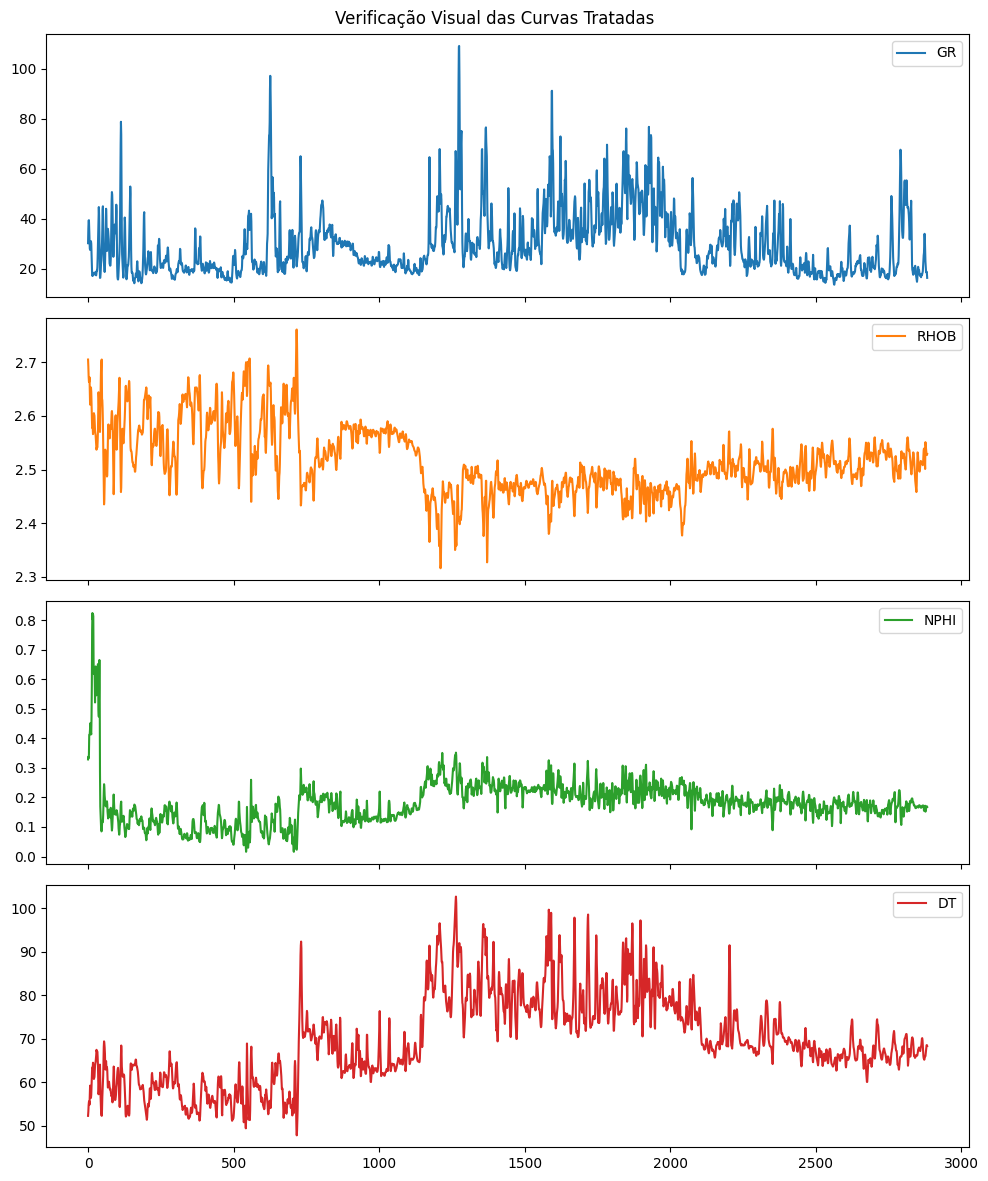

2026-09-04 21:37:38,738 | INFO     | anomaly_detector | --- ✅ Processo de verificação final Concluído ---
2026-09-04 21:37:38,742 | INFO     | anomaly_detector | 
O DataFrame 'df_logs' está pronto para ser usado no pipeline de detecção de outliers.


In [34]:
# =============================================================================
# Verificação de Integridade e Estatísticas Finais
# =============================================================================
if 'df_logs' in locals():
    logger.info("--- 📊 Verificação Final do DataFrame Tratado (df_logs) ---")

    # Prints de inspeção interativa (head/info/describe/tail) são mantidos como
    # print(), pois servem à leitura direta no notebook, não a eventos de pipeline
    # (ver Item 4.1 da Auditoria: "manter os print() de exibição de tabelas").
    logger.info("\n[INFO] Informações Gerais e Tipos de Dados:")
    df_logs.info()

    logger.info("\n[STATS] Estatísticas Descritivas das Curvas Principais:")
    display_stats_curves = [c for c in ['GR', 'RHOB', 'NPHI', 'DT', 'RT'] if c in df_logs.columns]
    print(df_logs[display_stats_curves].describe())

    logger.info("\n[HEAD] Primeiras 5 linhas do DataFrame final:")
    print(df_logs.head())

    logger.info("\n[TAIL] Últimas 5 linhas do DataFrame final:")
    print(df_logs.tail())

    # Plot Rápido para verificação visual
    logger.info("--- 📈 Gerando Plot de Verificação Rápida ---")
    df_logs[display_stats_curves].plot(subplots=True, figsize=(10, 12), title="Verificação Visual das Curvas Tratadas")
    plt.tight_layout()
    plt.show()
    plt.close('all')
    gc.collect()

    # >> ETAPA 9 : Resetar o índice para que DEPTH volte a ser uma coluna <<
    # Isso prepara o DataFrame para funções que esperam 'DEPTH' como uma coluna.
    # =========================================================================
    # Item 1.2 da Auditoria (CRÍTICO): esta chamada era incondicional e rodava
    # sobre um df_logs cujo índice JÁ havia sido resetado no bloco anterior,
    # inserindo uma coluna 'index' espúria (RangeIndex 0..N-1) que poderia ser
    # capturada por select_dtypes(include=np.number) em chamadas futuras sem
    # 'columns' explícito, distorcendo o MCD/Z-score. Agora é idempotente:
    # só reseta se 'DEPTH' ainda for o índice.
    if df_logs.index.name == 'DEPTH':
        df_logs.reset_index(inplace=True)
        logger.info("9. Índice 'DEPTH' revertido para coluna, preparando para a análise final.")
    else:
        logger.debug("9. 'DEPTH' já está como coluna; reset_index ignorado (evita coluna 'index' espúria).")

    if 'index' in df_logs.columns:
        logger.warning("Coluna 'index' espúria detectada; removendo antes da etapa de detecção.")
        df_logs.drop(columns=['index'], inplace=True)

    logger.info("--- ✅ Processo de verificação final Concluído ---")

    logger.info("\nO DataFrame 'df_logs' está pronto para ser usado no pipeline de detecção de outliers.")

# Lógica Principal


In [35]:
#___ F U N Ç Õ E S   B Á S I C A S ___
#--------------------------------------------
def detectar_anomalia_unidimensional_iqr(df: pd.DataFrame, columns: list = None, factor_iqr: float = 1.5) -> pd.DataFrame:
    """
    Identifica outliers em um DataFrame usando o método do Intervalo Interquartil (IQR).

    Args:
        df (pd.DataFrame): O DataFrame de entrada.
        columns (list, optional): Uma lista com os nomes das colunas para analisar.
                                  Se o valor for None, a função analisará todas as
                                  colunas numéricas do DataFrame. Padrão é None.
        factor_iqr (float, optional): O fator multiplicativo para o IQR que define
                                      os limites de detecção de outliers.
                                      O valor comum é 1.5. Padrão é 1.5.

    Returns:
        pd.DataFrame: Um DataFrame booleano com as mesmas dimensões do input,
                      onde True indica a presença de um outlier.
    """
    # Cria um DataFrame booleano para armazenar a máscara de outliers
    df_outliers_mask = pd.DataFrame(False, index=df.index, columns=df.columns)

    # Se nenhuma coluna for especificada, seleciona todas as colunas numéricas
    if columns is None:
        columns = df.select_dtypes(include=np.number).columns.tolist()

    logger.info(f"Colunas a serem tratadas: {columns}\n")

    for col in columns:
        if col not in df.columns:
            logger.warning(f"Aviso: A coluna '{col}' não foi encontrada no DataFrame. Pulando.")
            continue

        if not pd.api.types.is_numeric_dtype(df[col]):
            logger.warning(f"Aviso: A coluna '{col}' não é numérica. Pulando.")
            continue

        # 1. Calcula Q1, Q3 e IQR
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1

        # 2. Define os limites inferior e superior
        limite_inferior = q1 - factor_iqr * iqr
        limite_superior = q3 + factor_iqr * iqr

        logger.info(f"Analisando coluna '{col}':")
        logger.info(f"  - Limite Inferior: {limite_inferior:.2f}")
        logger.info(f"  - Limite Superior: {limite_superior:.2f}")

        # 3. Identifica e marca os outliers na máscara
        outliers_inf_mask = df[col] < limite_inferior
        outliers_sup_mask = df[col] > limite_superior

        df_outliers_mask[col] = outliers_inf_mask | outliers_sup_mask

        # 4. Conta e imprime o número de outliers
        outliers_inf_count = outliers_inf_mask.sum()
        outliers_sup_count = outliers_sup_mask.sum()

        logger.info(f"  - Número de Outliers (Inferior): {outliers_inf_count}")
        logger.info(f"  - Número de Outliers (Superior): {outliers_sup_count}")

    return df_outliers_mask

In [36]:
def detectar_anomalia_zscore_padrao(df: pd.DataFrame, columns: list = None, threshold: float = 3.0) -> pd.DataFrame:
    """
    Identifica outliers usando Média e Desvio Padrão (Z-Score Clássico).
    """
    df_outliers_mask = pd.DataFrame(False, index=df.index, columns=df.columns)
    if columns is None:
        columns = df.select_dtypes(include=np.number).columns.tolist()

    for col in columns:
        if col in df.columns:
            mean = df[col].mean()
            std = df[col].std()
            z_score = np.abs((df[col] - mean) / std)
            df_outliers_mask[col] = z_score > threshold

    return df_outliers_mask

In [37]:
def detectar_anomalia_zscore_robusto(df: pd.DataFrame, columns: list = None, threshold: float = 3.5) -> pd.DataFrame:
    """
    Identifica outliers em um DataFrame usando o método do Z-score Robusto.
    Este método utiliza a Mediana e o Desvio Absoluto Mediano (MAD), sendo
    mais resistente a outliers do que o Z-score padrão.

    Args:
        df (pd.DataFrame): O DataFrame de entrada.
        columns (list, optional): Uma lista com os nomes das colunas para analisar.
                                  Se o valor for None, a função analisará todas as
                                  colunas numéricas do DataFrame. Padrão é None.
        threshold (float, optional): O limiar para o Z-score Robusto. Pontos cujo
                                     valor absoluto do Z-score Robusto excederem
                                     este limiar são considerados outliers.
                                     O valor comum é 3.5. Padrão é 3.5.

    Returns:
        pd.DataFrame: Um DataFrame booleano com as mesmas dimensões do input,
                      onde True indica a presença de um outlier.
    """
    # Cria um DataFrame booleano para armazenar a máscara de outliers
    df_outliers_mask = pd.DataFrame(False, index=df.index, columns=df.columns)

    # Se nenhuma coluna for especificada, seleciona todas as colunas numéricas
    if columns is None:
        columns = df.select_dtypes(include=np.number).columns.tolist()

    logger.debug("Colunas a serem tratadas (Z-score Robusto): %s", columns)

    for col in columns:
        if col not in df.columns:
            logger.warning("Aviso: A coluna '%s' não foi encontrada no DataFrame. Pulando.", col)
            continue

        if not pd.api.types.is_numeric_dtype(df[col]):
            logger.warning("Aviso: A coluna '%s' não é numérica. Pulando.", col)
            continue

        # 1. Calcula a mediana e o MAD (Desvio Absoluto Mediano)
        median = df[col].median()
        diff = np.abs(df[col] - median)
        mad = diff.median()

        logger.debug("Analisando coluna '%s': mediana=%.4f, MAD=%.4f, limiar=%.2f", col, median, mad, threshold)

        # Se o MAD for 0, não há desvio, então não há outliers.
        # Isso evita divisão por zero.
        if mad == 0:
            logger.warning("Coluna '%s': MAD é zero, não há outliers a serem detectados. Pulando.", col)
            continue

        # 2. Calcula o Z-score Robusto (Modified Z-score)
        # O fator 0.6745 torna o MAD comparável ao desvio padrão para dados normais
        modified_z_score = 0.6745 * diff / mad

        # 3. Identifica e marca os outliers na máscara
        outliers_mask = modified_z_score > threshold
        df_outliers_mask[col] = outliers_mask

        # 4. Conta e loga o número de outliers
        outliers_count = outliers_mask.sum()
        logger.debug("Coluna '%s': %d outliers identificados.", col, outliers_count)

    return df_outliers_mask

In [38]:
def calcular_zscore_robusto_matriz(df: pd.DataFrame, columns: list) -> pd.DataFrame:
    """
    Item 3.1 da Auditoria (Performance): calcula |Zrob| (Eq. 2 do artigo) UMA
    ÚNICA VEZ por coluna, de forma vetorizada, para todo o DataFrame.

    Reaproveitada por unificar_outliers_por_masks() para eliminar a recomputação
    redundante de mediana/MAD que antes ocorria 4 vezes (uma por combinação de
    threshold padrão/QC x extremo/moderado) sobre as mesmas colunas.

    Args:
        df (pd.DataFrame): DataFrame de entrada.
        columns (list): Colunas para as quais calcular |Zrob|.

    Returns:
        pd.DataFrame: |Zrob| para cada coluna. Colunas com MAD=0 recebem 0.0
                      em todas as linhas (nunca ultrapassam nenhum threshold > 0),
                      preservando o comportamento original de "pular" a coluna.
    """
    medianas = df[columns].median()
    mad = (df[columns] - medianas).abs().median()
    mad_seguro = mad.replace(0, np.nan)  # evita divisão por zero
    z_abs = (0.6745 * (df[columns] - medianas).abs()).divide(mad_seguro)
    return z_abs.fillna(0.0)

In [39]:
def detectar_anomalia_multidimensional_mahalanobis_robusto(df: pd.DataFrame, columns: list = None, alpha: float = 0.01) -> pd.Series:
    """
    Identifica outliers multidimensionais em um DataFrame usando a Distância de
    Mahalanobis Robusta, baseada no estimador Minimum Covariance Determinant (MCD).

    Esta abordagem é ideal para dados com mùltiplas variáveis correlacionadas
    (ex: mùltiplos logs de poço), pois avalia cada ponto no espaço n-dimensional.

    Args:
        df (pd.DataFrame): O DataFrame de entrada.
        columns (list, optional): Uma lista com os nomes das colunas que definem o
                                  espaço multidimensional a ser analisado. Se None,
                                  a função usará todas as colunas numéricas.
                                  Padrão é None.
        alpha (float, optional): O nível de significância estatística para definir
                                 o limiar de outlier. Corresponde à probabilidade de
                                 um ponto ser falsamente classificado como outlier.
                                 Um valor menor torna a detecção mais rigorosa.
                                 Padrão é 0.01 (1%).

    Returns:
        pd.Series: Uma Série booleana com o mesmo índice do DataFrame de entrada,
                   onde True indica a presença de um outlier multidimensional.
    """
    # Se nenhuma coluna for especificada, seleciona todas as colunas numéricas
    if columns is None:
        columns = df.select_dtypes(include=np.number).columns.tolist()

    logger.debug("Colunas que definem o espaço multidimensional: %s", columns)

    # 1. Preparar os dados
    # Apenas as colunas de interesse
    data_subset = df[columns]


    if data_subset.shape[0] < len(columns):
        logger.warning("Número de amostras após remover NAs é menor que o número de dimensões. "
                        "Não é possível calcular a distância. Retornando uma máscara vazia.")
        return pd.Series(False, index=df.index, name='outlier_mahalanobis')

    logger.debug("Analisando %d amostras em um espaço de %d dimensões.", data_subset.shape[0], data_subset.shape[1])

    # 2. Calcular a covariância robusta usando MCD
    # Item 2.1 da Auditoria: parâmetros explicitados (não apenas herdados do
    # padrão da biblioteca) para reprodutibilidade — random_state=42,
    # assume_centered=False e support_fraction=None reproduzem exatamente o
    # que está declarado na Seção 3.3 do artigo.
    mcd = MinCovDet(random_state=42, assume_centered=False, support_fraction=None)
    mcd.fit(data_subset)
    logger.debug("MinCovDet: support_fraction efetivo=%.4f (n=%d, p=%d)",
                 mcd.support_.mean(), *data_subset.shape)

    # 3. Calcular a distância de Mahalanobis (ao quadrado) para cada ponto
    # O método .mahalanobis() do objeto ajustado já retorna a distância ao quadrado
    mahal_dist_sq = mcd.mahalanobis(data_subset)

    # 4. Determinar o limiar de outlier usando a distribuição Qui-quadrado
    # A distância de Mahalanobis ao quadrado segue uma distribuição Chi-squared
    # com 'p' graus de liberdade (p = número de dimensões/colunas)
    p = len(columns)  # Graus de liberdade
    # Usamos a PPF (Percent Point Function), que é a inversa da CDF
    # para encontrar o valor crítico da distância
    threshold = chi2.ppf(1 - alpha, df=p)

    logger.debug("Nível de significância (alpha): %s | Limiar da Qui-quadrado (%d g.l.): %.4f", alpha, p, threshold)

    # 5. Identificar os outliers
    outliers_mask_cleaned = mahal_dist_sq > threshold

    # 6. Mapear os resultados de volta para o índice original do DataFrame
    # Isso garante que a saída tenha o mesmo tamanho do df original,
    # mesmo que algumas linhas tenham sido removidas por conter NaN.
    outlier_series = pd.Series(False, index=df.index, name='outlier_mahalanobis')
    outlier_series.loc[data_subset.index] = outliers_mask_cleaned

    logger.debug("Número total de outliers multidimensionais identificados: %d", outlier_series.sum())

    return outlier_series, mcd

In [40]:
#___ F U N Ç Õ E S  H Í B R I D A S ___
#--------------------------------------------
def detectar_outliers_multidimensionais_simples (
    df: pd.DataFrame,
    columns: list = None,
    method: str = 'zscore',         # <-- Seletor de método ('zscore' or 'iqr')
    factor_iqr: float = 3.5,        # <-- Parâmetro da Função 1
    zscore_threshold: float = 3.5,  # <-- Parâmetro da Função 2
    mahalanobis_alpha: float = 0.01
) -> pd.DataFrame:

    """
    Identifica outliers que são detectados simultaneamente por um método univariado
    robusto e um método multivariado robusto (Distância de Mahalanobis).

    O método univariado pode ser selecionado pelo parâmetro 'method':
    1. 'zscore': Z-Score Robusto (baseado em Mediana/MAD).
    2. 'iqr': Método de Quartis (baseado no Fator IQR).

    O método multivariado é fixo:
    - Distância de Mahalanobis Robusta (baseada em MCD).

    Um ponto (célula) só é marcado como outlier se for detectado pelo método
    univariado E a linha inteira à qual pertence for considerada um outlier
    multidimensional (Mahalanobis).

    Args:
        df (pd.DataFrame): O DataFrame de entrada.
        columns (list, optional): Lista de colunas para analisar. Se None, usa todas
                                  as colunas numéricas. Padrão é None.
        method (str, optional): O método univariado a ser usado.
                                Opções: 'zscore' (padrão) ou 'iqr'.
        factor_iqr (float, optional): Fator (multiplicador) do IQR.
                                      Usado apenas se method='iqr'. Padrão é 3.5.
        zscore_threshold (float, optional): Limiar para o Z-Score Robusto.
                                            Usado apenas se method='zscore'. Padrão é 3.5.
        mahalanobis_alpha (float, optional): Nível de significância para a Distância
                                             de Mahalanobis. Padrão é 0.01.

    Returns:
        pd.DataFrame: Um DataFrame booleano com as mesmas dimensões do input, onde
                      True indica a presença de um outlier confirmado pelos dois métodos.

    Raises:
        ValueError: Se o 'method' fornecido não for 'zscore' ou 'iqr'.
    """
    # Se nenhuma coluna for especificada, seleciona todas as colunas numéricas
    if columns is None:
        columns = df.select_dtypes(include=np.number).columns.tolist()

    logger.info("### INICIANDO DETECÇÃO HÍBRIDA ###")

    # --- ETAPA 1: Executa a detecção univariada (Método Selecionado) ---
    method_lower = method.lower()
    mascara_univariada = None # Inicializa a variável

    if method_lower == 'iqr':
        logger.info("\n--- 1/3: Executando IQR (Quartis) ---")
        # Chama a função de IQR (lógica da detectar_outliers_hibridos1)
        mascara_univariada = detectar_anomalia_unidimensional_iqr(df, columns=columns, factor_iqr=factor_iqr)
        logger.info(f"--> IQR encontrou {mascara_univariada[columns].sum().sum()} outliers potenciais (pontos individuais).")

    elif method_lower == 'zscore':
        logger.info("\n--- 1/3: Executando Z-Score Robusto ---")
        # Chama a função de Z-Score Robusto (lógica da detectar_outliers_hibridos2)
        mascara_univariada = detectar_anomalia_zscore_robusto(df, columns=columns, threshold=zscore_threshold)
        logger.info(f"--> Z-Score Robusto encontrou {mascara_univariada[columns].sum().sum()} outliers potenciais (pontos individuais).")

    else:
        raise ValueError(f"Método '{method}' desconhecido. Esperado 'zscore' ou 'iqr'.")

    # --- ETAPA 2: Executa a detecção por Mahalanobis Robusto ---
    # (Esta parte é idéntica em ambas as funções originais)
    logger.info("\n--- 2/3: Executando Distância de Mahalanobis Robusta ---")
    series_mahalanobis, _ = detectar_anomalia_multidimensional_mahalanobis_robusto(df, columns=columns, alpha=mahalanobis_alpha)

    # Converte a Série de outliers (por linha) para um DataFrame de máscara (por célula)
    mascara_mahalanobis = pd.DataFrame(False, index=df.index, columns=df.columns)
    for col in columns:
        mascara_mahalanobis.loc[series_mahalanobis, col] = True
    logger.info(f"--> Mahalanobis Robusto encontrou {series_mahalanobis.sum()} linhas de outliers potenciais.")

    # --- ETAPA 3: Combina as duas máscaras usando um "E" lógico ---
    # (Esta parte também é idéntica)
    logger.info("\n--- 3/3: Combinando os resultados (Univariado & Mahalanobis) ---")
    mascara_final = mascara_univariada & mascara_mahalanobis

    total_outliers_finais = mascara_final[columns].sum().sum()
    logger.info(f"\n### DETECÇÃO HÍBRIDA CONCLUÍDA ###")
    logger.info(f"--> Total de outliers finais (confirmados por ambos os métodos): {total_outliers_finais}")

    return mascara_final

In [41]:
def detectar_outliers_multidimensionais(
    df: pd.DataFrame,
    columns: list = None,
    method: str = 'zscore',
    factor_iqr: float = 3.5,
    zscore_threshold: float = 3.5,
    mahalanobis_alpha: float = 0.01
) -> tuple[pd.DataFrame, pd.DataFrame]:

    """
    Identifica e classifica outliers univariados em duas categorias distintas,
    cruzando a intensidade (Univariado) com o contexto (Multivariado - Mahalanobis).

    Diferente da detecção simples, esta função separa o que é provável ruído do que
    é provável evento geológico, retornando duas máscaras separadas.

    As categorias são:
    1. Outliers com Contexto Multidimensional (Interseção):
       - Pontos que são extremos univariados E onde a correlação entre curvas foi quebrada.
       - Indicativo forte de ruído, erro de ferramenta ou washout.

    2. Outliers Univariados Isolados (Sem Contexto Multidimensional):
       - Pontos que são extremos univariados, MAS onde a correlação física se manteve
         (Mahalanobis considerou a linha normal).
       - Indicativo de eventos geológicos reais (ex: camadas finas, hard streaks).

    O método univariado pode ser selecionado pelo parâmetro 'method':
    - 'zscore': Z-Score Robusto (baseado em Mediana/MAD).
    - 'iqr': Método de Quartis (baseado no Fator IQR).

    Args:
        df (pd.DataFrame): O DataFrame de entrada.
        columns (list, optional): Lista de colunas para analisar. Se None, usa todas
                                  as colunas numéricas. Padrão é None.
        method (str, optional): O método univariado a ser usado.
                                Opções: 'zscore' (padrão) ou 'iqr'.
        factor_iqr (float, optional): Fator (multiplicador) do IQR.
                                      Usado apenas se method='iqr'. Padrão é 3.5.
        zscore_threshold (float, optional): Limiar para o Z-Score Robusto.
                                            Usado apenas se method='zscore'. Padrão é 3.5.
        mahalanobis_alpha (float, optional): Nível de significância para a Distância
                                             de Mahalanobis (cutoff). Padrão é 0.01.

    Returns:
        tuple[pd.DataFrame, pd.DataFrame]: Uma tupla contendo dois DataFrames booleanos:
            1. mask_uni_com_multi: True onde é outlier Univariado E Multivariado (Provável Erro).
            2. mask_uni_sem_multi: True onde é outlier Univariado MAS NÃO Multivariado (Provável Geologia).

    Raises:
        ValueError: Se o 'method' fornecido não for 'zscore' ou 'iqr'.
    """


    # Validação e seleção de colunas
    if columns is None:
        columns = df.select_dtypes(include=np.number).columns.tolist()

    logger.info("### INICIANDO CATEGORIZAÇÃO DE OUTLIERS ###")

    # --- ETAPA 1: Identificar Linhas Multidimensionais (O Contexto) ---
    # Retorna uma Series Booleana onde True = Linha Anômala
    series_mahalanobis, _ = detectar_anomalia_multidimensional_mahalanobis_robusto(
        df, columns=columns, alpha=mahalanobis_alpha
    )
    logger.info(f"--> Linhas multidimensionais detectadas: {series_mahalanobis.sum()}")

    # --- ETAPA 2: Identificar Outliers Univariados (O Detalhe) ---
    method_lower = method.lower()
    mascara_univariada_total = None

    if method_lower == 'iqr':
        mascara_univariada_total = detectar_anomalia_unidimensional_iqr(
            df, columns=columns, factor_iqr=factor_iqr
        )
    elif method_lower == 'zscore':
        mascara_univariada_total = detectar_anomalia_zscore_robusto(
            df, columns=columns, threshold=zscore_threshold
        )
    else:
        raise ValueError("Método deve ser 'zscore' ou 'iqr'.")

    total_uni = mascara_univariada_total[columns].sum().sum()
    logger.info(f"--> Total de células univariadas detectadas: {total_uni}")

    # --- ETAPA 3: Criar as Duas Máscaras ---

    # Inicializa ambas as máscaras como False (tamanho original do df)
    mask_uni_com_multi = pd.DataFrame(False, index=df.index, columns=df.columns)
    mask_uni_sem_multi = pd.DataFrame(False, index=df.index, columns=df.columns)

    # Lógica de Separação:

    # Máscara 1: Onde a linha É multidimensional (series_mahalanobis == True)
    # Pegamos apenas as linhas 'True' do univariado que coincidem com índice 'True' do Mahalanobis
    mask_uni_com_multi.update(mascara_univariada_total.loc[series_mahalanobis, columns])

    # Máscara 2: Onde a linha NÃO É multidimensional (usando o tio '~' para inverter)
    # Pegamos apenas as linhas 'True' do univariado que coincidem com índice 'False' do Mahalanobis
    mask_uni_sem_multi.update(mascara_univariada_total.loc[~series_mahalanobis, columns])

    # Estatísticas para validação
    count_com_multi = mask_uni_com_multi.sum().sum()
    count_sem_multi = mask_uni_sem_multi.sum().sum()

    logger.info("\n### SEPARAÇÃO CONCLUÍDA ###")
    logger.info(f"--> Outliers Univariados em contexto Multidimensional: {count_com_multi}")
    logger.info(f"--> Outliers Univariados ISOLADOS (sem contexto Multi): {count_sem_multi}")
    logger.info(f"--> Validação (Soma deve ser igual ao total univariado): {count_com_multi + count_sem_multi == total_uni}")

    return mask_uni_com_multi, mask_uni_sem_multi

In [42]:
def calcular_mahalanobis_multigrupo(df_completo, dict_grupos, alphamg):
    """
    Função GERENTE: Orquestra a análise multivariada dividindo o poço em domínios
    físicos (Grupos) e gerenciando a disponibilidade de dados para cada um.

    CORREÇÃO (Item 3 da revisão do artigo):
    1) Linhas removidas pelo dropna() LOCAL de cada grupo deixam de ser
       preenchidas com False. Um dado ausente não é evidência de "não anômalo";
       ele é reportado como <NA> (dtype 'boolean' do pandas, que preserva a
       semântica de três estados e implementa lógica de Kleene em & / | / ~).
    2) mapa_curva_grupo deixa de sobrescrever o grupo de curvas compartilhadas
       entre múltiplos grupos (ex.: NPHI pertence a PETROFISICA_BASICA e a
       RESSONANCIA). Agora cada curva mapeia para uma LISTA de grupos. A regra
       de combinação (como os grupos são unidos na classificação final) é
       aplicada explicitamente em unificar_outliers_por_masks: OU lógico
       (Kleene) — se QUALQUER grupo ao qual a curva pertence sinalizar quebra
       de correlação física, a curva herda esse contexto; se todos os grupos
       aplicáveis estiverem indisponíveis (dado ausente), o contexto fica <NA>.

    Args:
        df_completo (pd.DataFrame): DataFrame principal com todas as curvas do poço.
        dict_grupos (dict): {nome_do_grupo: [lista_de_mnemônicos]}.
        alphamg (float): nível de significância (alpha) do teste de Mahalanobis/MCD.

    Returns:
        tuple[pd.DataFrame, dict]:
            1. df_flags: DataFrame (dtype 'boolean', 3 estados) por Grupo.
               True = contexto físico quebrado; False = contexto OK;
               <NA> = não calculável (grupo com <2 curvas presentes, dados
               vazios após dropna local, ou linha ausente naquele grupo).
            2. mapa_curva_grupo: {curva: [lista_de_grupos]}.
    """
    df_flags = pd.DataFrame(index=df_completo.index)
    mapa_curva_grupo = {}

    logger.info("--- Iniciando Cálculo de Mahalanobis por Grupos (versão corrigida: NA preservado + multi-grupo) ---")

    for nome_grupo, lista_curvas in dict_grupos.items():
        curvas_existentes = [c for c in lista_curvas if c in df_completo.columns]

        p_efetivo = len(curvas_existentes)
        logger.info("Grupo %s: p=%d graus de liberdade (curvas: %s)", nome_grupo, p_efetivo, curvas_existentes)
        if nome_grupo in P_ESPERADO and p_efetivo != P_ESPERADO[nome_grupo] and p_efetivo >= 2:
            logger.warning(
                "Grupo %s: p efetivo (%d) difere do p do artigo (%d) - o limiar "
                "da Qui-quadrado (Eq. 1) muda em relação ao reportado na Seção 3.3.",
                nome_grupo, p_efetivo, P_ESPERADO[nome_grupo]
            )

        # Mapa é sempre atualizado, mesmo se o grupo não puder ser calculado
        # (a curva ainda "pertence" ao grupo fisicamente; a impossibilidade de
        # cálculo será refletida como <NA> na coluna de flags, não removendo o
        # vínculo curva->grupo).
        for curva in curvas_existentes:
            mapa_curva_grupo.setdefault(curva, []).append(nome_grupo)

        if len(curvas_existentes) < 2:
            logger.info(f"Skipping {nome_grupo}: Curvas insuficientes ({len(curvas_existentes)})")
            df_flags[nome_grupo] = pd.array([pd.NA] * len(df_completo), dtype='boolean')
            continue

        df_grupo = df_completo[curvas_existentes].dropna()

        if df_grupo.empty:
            logger.info(f"Skipping {nome_grupo}: Dados vazios após limpeza.")
            df_flags[nome_grupo] = pd.array([pd.NA] * len(df_completo), dtype='boolean')
            continue

        try:
            series_outliers, _ = (detectar_anomalia_multidimensional_mahalanobis_robusto(
                df_grupo,
                alpha=alphamg
            ))

            aligned = series_outliers.reindex(df_completo.index)
            df_flags[nome_grupo] = aligned.astype('boolean')

            n_ausentes = int(df_flags[nome_grupo].isna().sum())
            logger.info(
                "Grupo %s: OK -> %d anomalias detectadas | %d linhas <NA> (ausência local de dado no grupo)",
                nome_grupo, int(series_outliers.sum()), n_ausentes
            )

        except Exception as e:
            logger.error(f"Erro ao processar grupo {nome_grupo}: {str(e)}")
            df_flags[nome_grupo] = pd.array([pd.NA] * len(df_completo), dtype='boolean')

    logger.info("--- Cálculo Finalizado ---\n")
    return df_flags, mapa_curva_grupo


In [43]:
#___ F U N Ç Õ E S   A U X I L I A R E S ___
#--------------------------------------------
def integrar_dados_categoricos_excel(
    df_referencia,
    path_excel,
    coluna_categorica_excel,
    coluna_depth_excel='DEPTH'
):
    """
    Integra dados categóricos de um arquivo Excel em um DataFrame de poço existente (df_referencia),
    forçando a amostragem dos dados do Excel a ser igual à do DataFrame de referência.

    MODIFICADO: Esta versão assume que a coluna categórica no Excel já é numérica
    (ex: 1.0, 2.0, 3.0) e apenas a converte de float para inteiro.

    A função alinha as profundidades do Excel com as do df_referencia usando
    reindexação com preenchimento 'forward fill' (ffill).

    Argumentos:
        df_referencia (pd.DataFrame): O DataFrame principal (ex: df_logs) que
                                      contém a coluna 'DEPTH' de referência.
        path_excel (str): O caminho para o arquivo .xlsx ou .xls.
        coluna_categorica_excel (str): O nome da coluna no Excel que contém
                                       os dados (ex: 'FACIES', que deve
                                       conter valores como 1.0, 2.0, etc.).
        coluna_depth_excel (str): O nome da coluna de profundidade no Excel.
                                  O padrão é 'DEPTH'.

    Retorna:
        pd.DataFrame: O df_referencia original com a nova coluna (agora inteira)
                      integrada e reamostrada, ou o df_referencia original
                      se a leitura do Excel falhar.
    """
    logger.info(f"Iniciando integração de dados categóricos do arquivo: {path_excel}")

    # --- 1. Leitura e Preparação do DataFrame de Referência ---
    if 'DEPTH' not in df_referencia.columns:
        logger.error("Erro: O DataFrame de referência não possui uma coluna 'DEPTH'.")
        return df_referencia

    # Define 'DEPTH' como índice para facilitar a junção e reindexação
    df_principal_idx = df_referencia.set_index('DEPTH')

    # --- 2. Leitura e Preparação dos Dados do Excel ---
    try:
        # Lê apenas as colunas necessárias
        df_excel = pd.read_excel(
            path_excel,
            usecols=[coluna_depth_excel, coluna_categorica_excel]
        )

        # Limpeza básica
        df_excel = df_excel.dropna(
            subset=[coluna_depth_excel, coluna_categorica_excel]
        )
        df_excel = df_excel.drop_duplicates(subset=[coluna_depth_excel])
        df_excel = df_excel.sort_values(by=coluna_depth_excel)

    except FileNotFoundError:
        logger.error(f"Erro: Arquivo Excel não encontrado em {path_excel}")
        return df_referencia
    except ValueError as e:
        logger.error(f"Erro ao ler colunas do Excel. Verifique os nomes das colunas.")
        logger.info(f"Detalhe: {e}")
        return df_referencia
    except Exception as e:
        logger.error(f"Ocorreu um erro inesperado ao ler o Excel: {e}")
        return df_referencia
    if not df_excel.empty:
        logger.info(f"  Convertendo coluna '{coluna_categorica_excel}' de float para inteiro.")
        try:

            # Usamos 'Int64' (com 'I' maiúsculo) pois ele suporta
            # valores nulos (NaN), o que dá mais robustez, embora
            # os NaNs já tenham sido removidos acima.
            df_excel[coluna_categorica_excel] = df_excel[coluna_categorica_excel].astype('Int64')
            logger.info(f"  Conversão de '{coluna_categorica_excel}' para inteiro concluída.")

        except Exception as e:
            logger.error(f"Erro ao tentar converter '{coluna_categorica_excel}' para inteiro.")
            logger.info(f"  Verifique se a coluna contém valores não numéricos (ex: texto).")
            logger.info(f"  Detalhe: {e}")
            return df_referencia
    else:
        logger.info("Arquivo Excel lido, mas está vazio ou as colunas especificadas não têm dados.")
        return df_referencia

    # Define a profundidade do Excel como índice
    df_excel_idx = df_excel.set_index(coluna_depth_excel)
    # Seleciona apenas a coluna categórica (agora com ints) para reindexar
    df_excel_cat_only = df_excel_idx[[coluna_categorica_excel]]

    # --- 3. Checagem e Relatório da Amostragem (Conforme Solicitado) ---
    taxa_ref_mediana = df_referencia['DEPTH'].diff().median()
    taxa_excel_mediana = df_excel[coluna_depth_excel].diff().median()

    logger.info(f"  Taxa de amostragem (mediana) do DF de referência: {taxa_ref_mediana:.4f}")
    logger.info(f"  Taxa de amostragem (mediana) do arquivo Excel: {taxa_excel_mediana:.4f}")

    if not np.isclose(taxa_ref_mediana, taxa_excel_mediana, atol=1e-4):
        logger.info("  Status: Taxas de amostragem são diferentes. Realizando reindexação.")
    else:
        logger.info("  Status: Taxas de amostragem parecem similares, mas a reindexação garantirá o alinhamento.")

    # --- 4. Reindexação e Preenchimento (O "Coração" da Lógica) ---
    logger.info(f"Realizando reindexação de '{coluna_categorica_excel}' para o índice de profundidade do poço...")

    # Reindexa os dados (agora inteiros) para o índice de profundidade do poço principal
    # method='ffill' (forward fill): preenche os valores para baixo.
    df_cat_reindexado = df_excel_cat_only.reindex(
        df_principal_idx.index,
        method='ffill'
    )

    # O 'ffill' pode deixar NaNs no *topo* do poço (antes da primeira entrada do Excel).
    # O 'bfill' (backward fill) preenche esses valores restantes.
    df_cat_reindexado = df_cat_reindexado.bfill()

    # Garantir que o resultado final seja inteiro (ffill/bfill podem reintroduzir float se houver NaNs)
    # Usamos Int64 (com 'I' maiúsculo) para permitir NaNs, se algum ainda existir, embora bfill deva resolver.
    df_cat_reindexado[coluna_categorica_excel] = df_cat_reindexado[coluna_categorica_excel].astype('Int64')


    # --- 5. Integração (Join) ---
    # Junta a nova coluna categórica e reamostrada ao DataFrame principal
    df_integrado = df_principal_idx.join(df_cat_reindexado)

    # Verifica se a coluna já existe e renomeia se necessário
    if coluna_categorica_excel in df_principal_idx.columns:
        nova_coluna = f"{coluna_categorica_excel}_excel"
        logger.warning(f"Aviso: Coluna '{coluna_categorica_excel}' já existe. Dados integrados como '{nova_coluna}'.")
        df_integrado.rename(
            columns={coluna_categorica_excel: nova_coluna},
            inplace=True
        )

    logger.info("Integração concluída com sucesso.")

    # Retorna o DataFrame ao formato original (com 'DEPTH' como coluna)
    return df_integrado.reset_index()

In [44]:
def contar_outliers_por_linha(df: pd.DataFrame, mascara_final: pd.DataFrame) -> pd.DataFrame:
    """
    Gera uma métrica de severidade linha a linha, contabilizando quantos
    outliers simultâneos ocorrem em cada profundidade.

    Esta função é uma ferramenta de diagnóstico que transforma a matriz dispersa
    de flags (True/False) em uma curva contínua de "Qualidade do Dado".

    A lógica de interpretação é:
    1. Diagnóstico de Severidade:
       - Linhas com contagem 0: Dados limpos.
       - Linhas com contagem 1: Erro pontual (ex: spike em uma curva).
       - Linhas com contagem alta (ex: >3): Problema sistêmico (ex: desmoronamento
         do poço, falha de ferramenta combinada ou litologia muito complexa).

    2. Segurança de Integridade:
       - A função realiza um alinhamento explícito de índices (`align`) para garantir
         que a máscara booleana corresponda exatamente à profundidade correta do
         DataFrame de dados, evitando erros de deslocamento.

    Args:
        df (pd.DataFrame): O DataFrame principal contendo as curvas originais.
        mascara_final (pd.DataFrame): A máscara booleana final (onde True indica outlier),
                                      resultante das etapas de detecção anteriores.

    Returns:
        pd.DataFrame: Uma CÓPIA do DataFrame original contendo todas as curvas,
                      adicionada da coluna nova 'OUTLIER_COUNT' (int), que representa
                      o somatório horizontal de anomalias por profundidade.
    """
    logger.info("--- 📊 Contando outliers por linha (profundidade) ---")

    # Garante que a máscara e o df estejam perfeitamente alinhados pelo índice
    mascara_final_aligned, df_aligned = mascara_final.align(df, join='right', axis=0, fill_value=False)

    # Seleciona apenas as colunas que são do tipo bool (True/False)
    # Isso evita somar colunas como 'DEPTH' caso ela exista na máscara por engano
    colunas_booleanas = mascara_final_aligned.select_dtypes(include='bool').columns

    # Soma os valores 'True' (outliers) ao longo das colunas (axis=1) para cada linha
    contagem_por_linha = mascara_final_aligned[colunas_booleanas].sum(axis=1)

    # Cria uma cópia do DataFrame original para adicionar a coluna
    df_com_contagem = df.copy()

    # Adiciona a nova coluna de contagem
    df_com_contagem['OUTLIER_COUNT'] = contagem_por_linha.astype(int)

    logger.info(f"Coluna 'OUTLIER_COUNT' adicionada ao DataFrame.")
    logger.info(f"Total de linhas com 1 ou mais outliers: { (df_com_contagem['OUTLIER_COUNT'] > 0).sum() }")
    logger.info(f"Contagem máxima de outliers em uma única linha: { df_com_contagem['OUTLIER_COUNT'].max() }")

    return df_com_contagem

In [45]:
def unificar_outliers(
    df: pd.DataFrame,
    columns: list = None,
    method: str = 'zscore',
    factor_iqr: float = 3.5,
    zscore_threshold: float = 3.5,
    mahalanobis_alpha: float = 0.01
) -> pd.DataFrame:
    """
    Consolida a detecção de anomalias transformando as máscaras booleanas em um
    Mapa de Classificação Categórico (0, 1, 2).

    Esta função atua como a etapa final do pipeline, traduzindo a lógica híbrida
    em códigos numéricos para visualização e tomada de decisão.

    O Mapeamento segue a seguinte lógica de prioridade:
    0. Normal (Código 0):
       - Dados estatisticamente comuns.
       - Inclui também a "Caixa Branca" do fluxograma: pontos que possuem
         anomalia de contexto (Mahalanobis), mas NÃO possuem intensidade
         univariada suficiente. São considerados variações naturais e descartados
         da máscara de erro.

    1. Anomalia NÃO Correlacionada (Código 1 - "Vermelho"):
       - Pontos extremos (Z-Score/IQR alto) mas com correlação física preservada
         (Mahalanobis = False).


    2. Anomalia Correlacionada (Código 2 - "Verde"):
       - Pontos extremos (Z-Score/IQR alto) E com quebra de correlação física
         (Mahalanobis = True).


    Args:
        df (pd.DataFrame): O DataFrame de entrada.
        columns (list, optional): Lista de colunas para analisar. Se None, usa todas
                                  as colunas numéricas. Padrão é None.
        method (str, optional): Método univariado ('zscore' ou 'iqr').
        factor_iqr (float, optional): Fator do IQR (se method='iqr').
        zscore_threshold (float, optional): Limiar do Z-Score (se method='zscore').
        mahalanobis_alpha (float, optional): Nível de significância para Mahalanobis.

    Returns:
        pd.DataFrame: Um DataFrame de inteiros com as mesmas dimensões do input,
                      povoado com os valores 0, 1 e 2 conforme a classificação.
    """

    logger.info("### INICIANDO CONSOLIDAÇÃO VIA FUNÇÕES HÍBRIDAS ###")

    # --- PASSO 1: Delegação ---
    # Chamamos a SUA função que já separa os grupos logicamente.
    # Ela retorna:
    #   mask_corr (mask_uni_com_multi) -> Equivale à Caixa Verde (Verdadeiro para Ambos)
    #   mask_nao_corr (mask_uni_sem_multi) -> Equivale à Caixa Vermelha (Verdadeiro Uni / Falso Multi)

    mask_corr, mask_nao_corr = detectar_outliers_multidimensionais (
        df=df,
        columns=columns,
        method=method,
        factor_iqr=factor_iqr,
        zscore_threshold=zscore_threshold,
        mahalanobis_alpha=mahalanobis_alpha
    )

    # --- PASSO 2: Construção do Mapa ---
    # Criamos o DataFrame zerado (Tudo = 0 / Normal)
    df_mapa = pd.DataFrame(0, index=df.index, columns=df.columns)

    # APLICAÇÃO DA LÓGICA DO DIAGRAMA:

    # 1. Caixa Vermelha: "Mantém o ponto como anomalia NÃO correlacionada"
    # Lógica: É Unidimensional (Sim) E Multidimensional (Não)
    df_mapa[mask_nao_corr] = 1

    # 2. Caixa Verde: "Mantém o ponto como anomalia correlacionada"
    # Lógica: É Unidimensional (Sim) E Multidimensional (Sim)
    df_mapa[mask_corr] = 2

    # 3. Caixa Branca (Lado Esquerdo): "Retira o ponto da máscara"
    # Lógica: É Multidimensional (Sim) E Unidimensional (Não)
    # OBSERVAÇÃO CRÍTICA: Como estamos usando a função 'detectar_outliers_multidimensionais',
    # qualquer ponto que NÃO seja Unidimensional sequer entra nas variáveis 'mask_corr'
    # ou 'mask_nao_corr'. Portanto, eles permanecem como 0 (Normal) no df_mapa.
    # O requisito de "retirar da máscara" é atendido automaticamente por exclusão.

    # Estatísticas Finais
    qtd_vermelha = (df_mapa == 1).sum().sum()
    qtd_verde = (df_mapa == 2).sum().sum()

    logger.info("\n### CLASSIFICAÇÃO FINAL CONCLUÍDA ###")
    logger.info(f"--> [Código 1] Anomalia Não Correlacionada (Vermelha): {qtd_vermelha}")
    logger.info(f"--> [Código 2] Anomalia Correlacionada (Verde): {qtd_verde}")

    return df_mapa

In [46]:
def unificar_outliers_avancado(
    df: pd.DataFrame,
    columns: list = None,
    method: str = 'zscore',
    factor_iqr: float = 3.5,
    zscore_threshold_hard: float = 3.5, # Peneira Grossa (Vermelho/Verde)
    zscore_threshold_soft: float = 2.0, # Peneira Fina (Roxo)
    mahalanobis_alpha: float = 0.01
) -> pd.DataFrame:
    """
    Classificação Hierárquica de Outliers: Estratégia 'Dupla Peneira'.

    Esta função implementa o nível mais sofisticado de detecção do script, executando
    o algoritmo híbrido duas vezes com sensibilidades diferentes para categorizar
    a gravidade e a natureza da anomalia.

    A Lógica de Classificação (3 Categorias):

    A Lógica de Classificação (Status):

      1. Vermelho (Código 1 - "Não Correlacionado"):
        - O valor é univariadamente anomalo (ultrapassa o threshold do z-score) mas a linha não é multivariadamente anomala (não ultrapassa o threshold do mahalanobis) .
        - Interpretação:

      2. Verde (Código 2 - "Correlacionado"):
        -  O valor é univariadamente anomalo (ultrapassa o threshold do z-score) e a linha é multivariadamente anomala (ultrapassa o threshold do mahalanobis).
        - Interpretação:

      3. Roxo (Código 3 - "Sutil"):
        - O valor é Moderado (entre z_cutoff_moderado e z_cutoff) E a correlação foi quebrada.
        - Interpretação:

    Args:
        df (pd.DataFrame): O DataFrame de entrada.
        columns (list, optional): Lista de colunas. Padrão: todas numéricas.
        method (str, optional): 'zscore' ou 'iqr'.
        factor_iqr (float, optional): Fator IQR (se method='iqr').
        zscore_threshold_hard (float, optional): "Peneira Grossa". Limite para
                                                 considerar um valor Extremo (Vermelho/Verde).
                                                 Padrão é 3.5.
        zscore_threshold_soft (float, optional): "Peneira Fina". Limite para
                                                 considerar um valor Moderado (Roxo).
                                                 Padrão é 2.0.
        mahalanobis_alpha (float, optional): Nível de significância do contexto.

    Returns:
        pd.DataFrame: Um DataFrame de inteiros (Mapa de Calor) com os códigos:
                      0=Normal, 1=Vermelho, 2=Verde, 3=Roxo.
    """

    logger.info("### INICIANDO CLASSIFICAÇÃO AVANÇADA (Estratégia Dupla Peneira) ###")

    # --- PASSO 1: PENEIRA GROSSA (Threshold Hard: 3.5) ---
    # Usamos a função que retorna a TUPLA para já separar o Vermelho do Verde.
    # mask_verde_hard:    Pontos onde Z > 3.5  E  Mahalanobis diz SIM.
    # mask_vermelho_hard: Pontos onde Z > 3.5  E  Mahalanobis diz NÃO.
    mask_verde_hard, mask_vermelho_hard = detectar_outliers_multidimensionais(
        df=df,
        columns=columns,
        method=method,
        factor_iqr=factor_iqr,
        zscore_threshold=zscore_threshold_hard,
        mahalanobis_alpha=mahalanobis_alpha
    )

    # --- PASSO 2: PENEIRA FINA (Threshold Soft: 2.0) ---
    # Usamos a função que retorna a INTERSEÇÃO para pegar tudo que tem "cheiro" geológico.
    # mask_contexto_total: Pontos onde Z > 2.0  E  Mahalanobis diz SIM.
    # Nota: Isso captura tanto os verdes (que são >3.5) quanto os roxos (que são >2.0).
    # CORREÇÃO: Destruturar a tupla retornada, pegando apenas a primeira máscara.
    mask_contexto_total_correlated, _ = detectar_outliers_multidimensionais(
        df=df,
        columns=columns,
        method=method,
        factor_iqr=factor_iqr,
        zscore_threshold=zscore_threshold_soft, # <--- O pulo do gato (2.0)
        mahalanobis_alpha=mahalanobis_alpha
    )

    # --- PASSO 3: DEFINIR A ZONA ROXA (Diferença de Conjuntos) ---
    # A Zona Roxa é tudo que tem contexto (Passo 2) MAS não é extremo o suficiente para ser Verde (Passo 1).
    # Roxo = (Contexto Total) - (Verde Hard)
    # CORREÇÃO: Usar a variável corretamente destruturada
    mask_roxo = mask_contexto_total_correlated & (~mask_verde_hard)

    # --- PASSO 4: MONTAGEM DO MAPA ---
    df_mapa = pd.DataFrame(0, index=df.index, columns=df.columns)

    # Ordem de atribuição (do menos grave para o mais grave, embora sejam exclusivos):
    df_mapa[mask_roxo] = 3          # Geologia Sutil
    df_mapa[mask_verde_hard] = 2    # Geologia Forte
    df_mapa[mask_vermelho_hard] = 1 # Ruído

    # Relatório Estatístico
    logger.info("\n### ESTATÍSTICAS FINAIS ###")
    logger.info(f"Tipo 1 (Univariada Exclusivamente - Vermelho):       {(df_mapa == 1).sum().sum()}")
    logger.info(f"Tipo 2 (Uni e Multivariada - Verde):     {(df_mapa == 2).sum().sum()}")
    logger.info(f"Tipo 3 (Univariada sutil e Multivariada - Roxo):       {(df_mapa == 3).sum().sum()}")

    return df_mapa

In [47]:
def unificar_outliers_por_masks(df_logs, df_mcd_flags, mapa_curva_grupo,
                                z_cutoff_padrao=3.5,
                                z_cutoff_qc=6.0,
                                z_cutoff_moderado_padrao=1.5,
                                z_cutoff_moderado_qc=3.0):
    """
      Consolidação Final com Rigor Dinâmico (versão corrigida - Item 3 da revisão).

      Sistema de CINCO códigos (quatro flags "válidas" + 1 código de ausência):
        -1 (Não Classificado): o(s) grupo(s) de contexto da curva estão <NA>
             para esta profundidade (dado ausente no cálculo multivariado local).
             NÃO é tratado como 0/Normal.
         0 (Normal): sem extremo univariado relevante e contexto disponível.
         1 (Vermelha): extremo univariado E contexto multivariado OK (False).
         2 (Verde): extremo univariado E contexto multivariado quebrado (True).
         3 (Roxa): moderado (não extremo) E contexto multivariado quebrado (True).

      REGRA DE COMBINAÇÃO MULTI-GRUPO (curvas em >1 grupo, ex. NPHI):
        is_context_bad(curva) = OU lógico (Kleene) do flag de contexto de TODOS
        os grupos aos quais a curva pertence. Ou seja: se qualquer grupo da
        curva sinalizar quebra (True), a curva herda quebra=True; se todos os
        grupos aplicáveis estiverem <NA>, o resultado é <NA> (não classificado);
        caso contrário (algum False e nenhum True), é False.

      Args: (mesmos da versão original)
          mapa_curva_grupo (dict): {Curva: [Grupo1, Grupo2, ...]} (ou string
                                    única, por retrocompatibilidade).
      Returns:
          pd.DataFrame com colunas '<curva>_STATUS' e valores em {-1,0,1,2,3}.
    """

    logger.info("--- UNIFICAÇÃO COM THRESHOLDS DINÂMICOS (NA-aware, multi-grupo) ---")
    logger.info("   > Padrão: Extremo=%s | Moderado=%s", z_cutoff_padrao, z_cutoff_moderado_padrao)
    logger.info("   > QC    : Extremo=%s | Moderado=%s", z_cutoff_qc, z_cutoff_moderado_qc)

    colunas_numericas = df_logs.select_dtypes(include=np.number).columns.tolist()
    z_abs = calcular_zscore_robusto_matriz(df_logs, colunas_numericas)

    mask_extrema_std = z_abs > z_cutoff_padrao
    mask_moderada_std = z_abs > z_cutoff_moderado_padrao
    mask_extrema_qc = z_abs > z_cutoff_qc
    mask_moderada_qc = z_abs > z_cutoff_moderado_qc

    df_status = pd.DataFrame(index=df_logs.index)

    # Alinha o contexto multivariado preservando <NA> (não usa mais fillna(False))
    df_mcd_aligned = df_mcd_flags.reindex(df_logs.index)
    for c in df_mcd_aligned.columns:
        df_mcd_aligned[c] = df_mcd_aligned[c].astype('boolean')

    stats = {'padrao': 0, 'qc': 0}

    def _grupos_da_curva(col):
        g = mapa_curva_grupo.get(col)
        if g is None:
            return []
        if isinstance(g, str):
            return [g]
        return list(g)

    for col in df_logs.columns:
        if col not in mask_extrema_std.columns:
            continue

        grupos_curva = _grupos_da_curva(col)
        grupo_qc = 'QUALITY_CONTROL' in grupos_curva

        if grupo_qc:
            is_z_extremo = mask_extrema_qc[col].fillna(False).astype(bool)
            is_moderado = mask_moderada_qc[col].fillna(False).astype(bool)
            is_z_roxo = is_moderado & (~is_z_extremo)
            stats['qc'] += 1
        else:
            is_z_extremo = mask_extrema_std[col].fillna(False).astype(bool)
            is_moderado = mask_moderada_std[col].fillna(False).astype(bool)
            is_z_roxo = is_moderado & (~is_z_extremo)
            stats['padrao'] += 1

        # --- Combinação multi-grupo do contexto (OU lógico / Kleene) ---
        cols_validas = [g for g in grupos_curva if g in df_mcd_aligned.columns]
        if cols_validas:
            # DataFrame.any(skipna=False) com dtype 'boolean' aplica OU de Kleene:
            # True se qualquer coluna for True; <NA> se não houver True mas houver
            # alguma <NA>; False apenas se todas forem False.
            is_context_bad = df_mcd_aligned[cols_validas].any(axis=1, skipna=False)
        else:
            is_context_bad = pd.array([pd.NA] * len(df_logs), dtype='boolean')
            is_context_bad = pd.Series(is_context_bad, index=df_logs.index)

        ctx_isna = is_context_bad.isna()
        ctx_bool = is_context_bad.fillna(False).astype(bool)

        # --- Classificação (ausência tem prioridade sobre 0/1/2/3) ---
        cond_nc = (is_z_extremo | is_z_roxo) & ctx_isna
        cond_vermelha = is_z_extremo & (~ctx_bool) & (~ctx_isna)
        cond_verde = is_z_extremo & ctx_bool & (~ctx_isna)
        cond_roxa = is_z_roxo & ctx_bool & (~ctx_isna)

        conditions = [cond_nc, cond_vermelha, cond_verde, cond_roxa]
        choices = [-1, 1, 2, 3]
        df_status[f"{col}_STATUS"] = np.select(conditions, choices, default=0)

    logger.info(f"Classificação concluída. Curvas Padrão: {stats['padrao']} | Curvas QC: {stats['qc']}")
    return df_status


In [48]:
def calcular_entropia_log(df_input, col_target, janela_metros=5.0, bins_hist=10):
    """
    Calcula a Entropia de Shannon (Medida de Heterogeneidade) em uma janela deslizante
    ao longo da profundidade do poço.

    A Entropia é uma métrica de "textura" do sinal que quantifica a desordem ou
    variabilidade dos dados dentro de um intervalo vertical.

    Interpretação Geológica:
    1. Entropia Alta (Máxima Desordem):
       - Indica mudanças rápidas e frequentes na litologia dentro da janela.
       - Típico de: Intercalações areia/folhelho (laminados), zonas fraturadas,
         brechas ou contatos litológicos complexos.

    2. Entropia Baixa (Ordem/Homogeneidade):
       - Indica que os valores da curva são constantes ou variam suavemente.
       - Típico de: Pacotes maciços (ex: Arenito limpo espesso, Folhelho marinho
         estável ou Sal).

    Metodologia:
    - Converte a janela de metros para número de amostras (baseado no step do poço).
    - Para cada passo, cria um histograma local dos valores (discretização).
    - Calcula a entropia: H(x) = - sum(p * log(p)), onde p é a probabilidade do bin.

    Args:
        df_input (pd.DataFrame): DataFrame contendo os perfis (deve conter 'DEPTH'
                                 ou índice de profundidade implícito).
        col_target (str): Nome da curva alvo para análise (ex: 'GR', 'RHOB', 'DT').
        janela_metros (float, optional): Altura da janela de análise em metros.
                                         Define a escala da heterogeneidade buscada.
                                         Padrão é 5.0 metros.
        bins_hist (int, optional): Número de classes para o histograma de densidade.
                                   Controla a sensibilidade da entropia. Padrão é 10.

    Returns:
        pd.Series: Uma série com o mesmo índice do DataFrame original contendo os
                   valores de entropia. (Valores NaN nas bordas da janela).
    """
    df = df_input.copy()

    # Tenta obter o passo de profundidade (assumindo amostragem regular)
    if 'DEPTH' in df.columns:
        step = df['DEPTH'].diff().mode()[0]
    else:
        step = 0.1524 # Valor padrão comum (6 polegadas)

    # Converte janela de metros para número de amostras
    window_size = int(janela_metros / step)
    if window_size < 1: window_size = 1

    # Função para aplicar na janela
    def _entropy_calc(x):
        # Cria histograma local para estimar probabilidades
        counts, _ = np.histogram(x, bins=bins_hist, density=True)
        # Filtra zeros para evitar log(0)
        p = counts[counts > 0]
        # Normaliza para somar 1 (probabilidade)
        p = p / p.sum()
        return entropy(p)

    # Aplica a entropia móvel
    return df[col_target].rolling(window=window_size, center=True).apply(_entropy_calc).fillna(0)

In [49]:
def detectar_zonas(df_input, col_entropia, sensibilidade=99):
    """
    Segmentação Estratigráfica Automática: Detecta fronteiras de zonas baseando-se
    nas mudanças abruptas (picos de gradiente) da curva de Entropia.

    Esta função atua como um "Detector de Bordas" geológico. Enquanto a Entropia
    nos diz "como" é a textura da rocha, o Gradiente da Entropia nos diz "onde"
    essa textura muda drasticamente.

    Metodologia:
    1. Cálculo do Gradiente: Aplica a primeira derivada na curva de entropia.
       - Gradiente Baixo: A heterogeneidade está estável (dentro de uma mesma fácies).
       - Gradiente Alto (Pico): A heterogeneidade mudou repentinamente (contato).

    2. Limiar Estatístico (Percentil):
       - Define o que é considerado um "Pico Relevante" baseando-se na distribuição
         dos dados. Uma sensibilidade de 99 (99º percentil) pega apenas o Top 1%
         das mudanças mais drásticas, ignorando ruídos menores.

    Args:
        df_input (pd.DataFrame): DataFrame contendo a curva de entropia calculada.
        col_entropia (str): Nome da coluna de entropia (ex: 'GR_ENTROPY').
        sensibilidade (float, optional): Percentil (0-100) para corte do gradiente.
                                         - Valores altos (ex: 99): Menos zonas, apenas
                                           contatos principais (Formações/Membros).
                                         - Valores baixos (ex: 90): Mais zonas, detalhamento
                                           fino (camadas individuais). Padrão é 99.

    Returns:
        tuple:
            1. indices_mudanca (list): Lista de índices (profundidades) onde começam/terminam as zonas.
            2. gradiente (np.array): O array calculado da primeira derivada (para plotagem).
            3. threshold (float): O valor numérico de corte calculado.
    """
    df = df_input.copy()
    gradiente = np.gradient(df[col_entropia].fillna(0))
    abs_grad = np.abs(gradiente)

    # Define limiar estatístico (percentil)
    threshold = np.percentile(abs_grad, sensibilidade)

    # Marca onde a mudança é brusca
    mudancas = abs_grad > threshold
    indices_mudanca = df.index[mudancas].tolist()

    # Adiciona início e fim do poço
    indices_mudanca = [df.index[0]] + indices_mudanca + [df.index[-1]]
    indices_mudanca = sorted(list(set(indices_mudanca))) # Remove duplicatas e ordena

    return indices_mudanca, gradiente, threshold

In [50]:
def auditoria_outliers_cruzados(df_logs, df_mcd_flags, df_status_final,
                                mapa_curva_grupo, func_deteccao_zscore,
                                z_cutoff_std=3.5, z_cutoff_qc=6.0):
    """
    Relatório Forense de Integridade (Debugging): Verifica a consistência entre
    a matemática bruta e a classificação final gravada.

    CORREÇÃO: Ajustada para lidar com 'mapa_curva_grupo' contendo listas de grupos
    (suporte a multi-grupo) em vez de strings únicas.
    """
    logger.info(f"\n{'='*80}")
    logger.info(f"AUDITORIA DE COERÊNCIA: Z-SCORE vs MAHALANOBIS vs STATUS FINAL")
    logger.info(f"{'='*80}")

    logger.info(f"1. Recalculando máscaras brutas para conferência...")
    mask_std = func_deteccao_zscore(df_logs, threshold=z_cutoff_std)
    mask_qc  = func_deteccao_zscore(df_logs, threshold=z_cutoff_qc)

    df_mcd_aligned = df_mcd_flags.reindex(df_logs.index).fillna(False).astype(bool)
    relatorio = []

    for col in df_logs.columns:
        if col not in mask_std.columns: continue

        # Garante que grupos seja uma lista
        grupos = mapa_curva_grupo.get(col, [])
        if isinstance(grupos, str): grupos = [grupos]

        col_status = f"{col}_STATUS"
        if col_status not in df_status_final.columns: continue

        # A. Define qual régua usar
        if 'QUALITY_CONTROL' in grupos:
            is_z_extremo = mask_qc[col].fillna(False).astype(bool)
            limite_usado = z_cutoff_qc
        else:
            is_z_extremo = mask_std[col].fillna(False).astype(bool)
            limite_usado = z_cutoff_std

        # B. Define o Contexto (OU lógico entre todos os grupos da curva)
        cols_validas = [g for g in grupos if g in df_mcd_aligned.columns]
        if cols_validas:
            is_mcd_bad = df_mcd_aligned[cols_validas].any(axis=1)
        else:
            is_mcd_bad = pd.Series(False, index=df_logs.index)

        # C. CÁLCULO TEÓRICO
        teoria_vermelho = (is_z_extremo) & (~is_mcd_bad)
        n_teoria_vermelho = teoria_vermelho.sum()

        teoria_verde = (is_z_extremo) & (is_mcd_bad)
        n_teoria_verde = teoria_verde.sum()

        # D. CÁLCULO REAL
        n_real_vermelho = (df_status_final[col_status] == 1).sum()
        n_real_verde = (df_status_final[col_status] == 2).sum()

        status_check = "OK"
        if n_teoria_vermelho > 0 and n_real_vermelho == 0:
            status_check = "ERRO: SUMIÇO"
        elif abs(n_teoria_vermelho - n_real_vermelho) > 0:
             status_check = "DIVERGÊNCIA"

        relatorio.append({
            'Curva': col,
            'Total_Z_Alto': is_z_extremo.sum(),
            'Teoria_RED (Z+ MCD-)': n_teoria_vermelho,
            'Real_RED (Status 1)': n_real_vermelho,
            'Teoria_GREEN (Z+ MCD+)': n_teoria_verde,
            'Check': status_check
        })

    df_audit = pd.DataFrame(relatorio)
    df_audit_ativo = df_audit[df_audit['Total_Z_Alto'] > 0].copy()

    if df_audit_ativo.empty:
        logger.info("Nenhuma curva apresentou Z-Score acima dos limites definidos.")
    else:
        cols_show = ['Curva', 'Total_Z_Alto', 'Teoria_RED (Z+ MCD-)', 'Real_RED (Status 1)', 'Teoria_GREEN (Z+ MCD+)', 'Check']
        print(df_audit_ativo[cols_show].to_string(index=False))

        n_errors = (df_audit['Check'] == "ERRO: SUMIÇO").sum()
        if n_errors > 0:
            logger.error(f"❌ DIAGNÓSTICO: ALERTA! {n_errors} curvas com inconsistência.")
        else:
            logger.info("✅ DIAGNÓSTICO: LÓGICA ÍNTEGRA.")

In [51]:
def exportar_tabelas_anomalias(df_logs, df_status, output_dir):
    """
    Exporta os dados e as classificações de anomalias (0, 1, 2, 3) em formato CSV.
    CORREÇÃO: Resolvido erro de 'dtype' causado por colunas DEPTH duplicadas no reset_index.
    """
    logger.info("\n--- GERANDO TABELAS DE ANOMALIAS ---")
    os.makedirs(output_dir, exist_ok=True)

    # 1. TABELA MATRIZ
    caminho_matriz = os.path.join(output_dir, "01_Matriz_Flags_Anomalias.csv")
    df_status.to_csv(caminho_matriz, sep=';')
    logger.info(f" -> Matriz de Flags salva: {caminho_matriz}")

    # 2. TABELA DETALHADA
    caminho_detalhado = os.path.join(output_dir, "02_Tabela_Detalhada_Anomalias.csv")

    # Preparação segura para o melt: garante que DEPTH seja a única variável identificadora
    df_l = df_logs.copy()
    if df_l.index.name == 'DEPTH':
        df_l = df_l.reset_index()

    df_s = df_status.copy()
    if df_s.index.name == 'DEPTH':
        df_s = df_s.reset_index()
    elif 'DEPTH' not in df_s.columns and 'DEPTH_STATUS' in df_s.columns:
        df_s = df_s.rename(columns={'DEPTH_STATUS': 'DEPTH'})

    # Remove colunas 'index' espúrias se existirem
    df_l = df_l.drop(columns=['index'], errors='ignore')
    df_s = df_s.drop(columns=['index'], errors='ignore')

    # Melt e Merge
    df_l_melt = df_l.melt(id_vars=['DEPTH'], var_name='Elemento', value_name='Valor_Real')
    df_s_melt = df_s.melt(id_vars=['DEPTH'], var_name='Elemento', value_name='Flag')

    # Limpeza de sufixos nos nomes dos elementos para o merge
    df_s_melt['Elemento'] = df_s_melt['Elemento'].str.replace('_STATUS', '')

    df_completo = pd.merge(df_l_melt, df_s_melt, on=['DEPTH', 'Elemento'])

    mapa_flags = {
        -1: '-1 - Nao Classificado (contexto multivariado ausente)',
        0: '0 - Normal',
        1: '1 - Anomalia Não Correlacionada (Vermelha)',
        2: '2 - Anomalia Correlacionada (Verde)',
        3: '3 - Anomalia Estruturada Sutil (Roxa)',
    }
    df_completo['Classificacao'] = df_completo['Flag'].map(mapa_flags)
    df_completo = df_completo.sort_values(by=['DEPTH', 'Elemento'])

    df_completo.to_csv(caminho_detalhado, index=False, sep=';', decimal=',')
    logger.info(f" -> Tabela Detalhada salva: {caminho_detalhado}")

# **Funções Para Plotagem**



In [52]:
def plotar_poco_usando_outliers_identificados(df: pd.DataFrame, df_outliers_mask: pd.DataFrame, curvas_a_plotar: list):
    """
    Visualização Diagnóstica: Gera um painel de perfis (Strip Log) sobrepondo
    os outliers detectados sobre os dados originais.

    Esta função cria a "Prova Visual" do processo de detecção. Ela permite diferenciar
    rapidamente se os pontos marcados como outliers são ruídos aleatórios (spikes)
    ou se agrupam em padrões que poderiam indicar geologia real não prevista.

    Metodologia de Plotagem:
    1. Camada Base (Azul): Plota a curva contínua original. Representa o dado bruto.
    2. Camada de Destaque (Vermelho): Plota apenas os pontos onde a máscara é True,
       usando marcadores 'x'. Isso destaca a localização exata e a dispersão dos anômalos.
    3. Alinhamento (Depth Matching): Todos os subplots compartilham o mesmo eixo Y
       (Profundidade), garantindo que um evento na curva Gamma Ray esteja visualmente
       alinhado com o mesmo evento na Densidade.

    Args:
        df (pd.DataFrame): DataFrame original contendo os valores das curvas e a coluna 'DEPTH'.
        df_outliers_mask (pd.DataFrame): DataFrame booleano (mesma dimensão de df) onde
                                         True indica a presença de um outlier.
        curvas_a_plotar (list): Lista de strings com os nomes das colunas (mnemônicos)
                                que serão visualizadas.

    Returns:
        None: A função exibe o gráfico diretamente via matplotlib (plt.show()).
    """
    num_curvas = len(curvas_a_plotar)
    fig, axes = plt.subplots(nrows=1, ncols=num_curvas, figsize=(num_curvas * 4, 15), sharey=True)
    fig.suptitle('Visualização dos Outliers nos Perfis do Poço', fontsize=18, y=1.0)

    if num_curvas == 1:
        axes = [axes]

    for i, curva in enumerate(curvas_a_plotar):
        ax = axes[i]

        # Pega a máscara de outliers para a curva atual a partir do DataFrame fornecido
        outliers_mask = df_outliers_mask[curva]

        # --- Plotagem ---
        # 1. Plota a curva completa
        ax.plot(df[curva], df['DEPTH'], label='Perfil', color='blue', lw=0.8)

        # 2. Usa a máscara para plotar apenas os outliers
        if outliers_mask.any():
            ax.scatter(df.loc[outliers_mask, curva], df.loc[outliers_mask, 'DEPTH'],
                       color='red', s=25, label=f'Outliers ({outliers_mask.sum()})',
                       zorder=5, marker='x')

        # --- Configuração do Gráfico ---
        ax.set_title(curva, fontsize=12)
        ax.set_xlabel('Valor')
        ax.grid(True, which='both', linestyle='--', linewidth=0.5)
        ax.legend()
        ax.set_ylim(df['DEPTH'].max(), df['DEPTH'].min())

    axes[0].set_ylabel('Profundidade (m)', fontsize=12)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

In [53]:
def plotar_logs_com_outlier_count(df: pd.DataFrame, df_outliers_mask: pd.DataFrame, curvas_a_plotar: list):
    """
    Visualização Integrada: Perfis Individuais + Mapa de Calor de Densidade de Erros.

    Esta função expande a visualização padrão adicionando um "Track de Resumo" (Heatmap)
    à direita dos perfis. Enquanto os tracks individuais mostram *onde* o erro ocorreu,
    o heatmap mostra *quão severo* é o problema naquela profundidade.



    Metodologia Visual:
    1. Tracks de Perfis (Esquerda):
       - Plota as curvas originais (Azul) e marca os outliers individuais (X Vermelho).
       - Permite a validação curva a curva.

    2. Track de Heatmap (Direita - Novo):
       - Visualiza a coluna 'OUTLIER_COUNT' como uma faixa de cor contínua (Plasma).
       - Cores Quentes (Amarelo/Vermelho): Indicam que múltiplas curvas falharam na mesma
         profundidade. Isso geralmente aponta para problemas sistêmicos como desmoronamento
         do poço (Bad Hole) ou rugosidade extrema.
       - Cores Frias (Azul/Roxo): Indicam erros isolados ou dados limpos.

    Args:
        df (pd.DataFrame): DataFrame contendo os dados. DEVE possuir as colunas:
                           - 'DEPTH': Profundidade.
                           - 'OUTLIER_COUNT': Inteiro calculado pela função 'contar_outliers_por_linha'.
        df_outliers_mask (pd.DataFrame): DataFrame booleano com a posição dos flags de erro.
        curvas_a_plotar (list): Lista de mnemônicos das curvas para os tracks individuais.

    Returns:
        None: Renderiza o painel composto via Matplotlib.
    """

    # --- Verificações Iniciais ---
    if 'OUTLIER_COUNT' not in df.columns:
        logger.error("ERRO: A coluna 'OUTLIER_COUNT' não foi encontrada no DataFrame.")
        logger.info("Por favor, execute a função 'contar_outliers_por_linha' primeiro.")
        return

    if 'DEPTH' not in df.columns:
        logger.error("ERRO: A coluna 'DEPTH' não foi encontrada no DataFrame.")
        return

    # --- Configuração do Gráfico ---
    # +1 track para o heatmap de contagem
    num_curvas = len(curvas_a_plotar)
    num_tracks = num_curvas + 1

    # Cria os subplots, compartilhando o eixo Y (profundidade)
    fig, axes = plt.subplots(nrows=1, ncols=num_tracks,
                             figsize=(num_tracks * 3.5, 15), # (largura, altura)
                             sharey=True)

    fig.suptitle('Visualização de Outliers com Mapa de Calor de Contagem', fontsize=18, y=1.0)

    # Garante que 'axes' seja sempre uma lista, mesmo com poucos plots
    if num_tracks == 1:
        axes = [axes]
    elif num_tracks == 0:
        logger.warning("Aviso: Nenhuma curva para plotar.")
        return

    # --- 1. Plotagem das Curvas de Log (Lógica da função original) ---
    for i, curva in enumerate(curvas_a_plotar):
        if curva not in df.columns or curva not in df_outliers_mask.columns:
            logger.warning(f"Aviso: Curva '{curva}' não encontrada. Pulando track.")
            continue

        ax = axes[i]

        # Pega a máscara de outliers para a curva atual
        outliers_mask = df_outliers_mask[curva]

        # Plot da curva completa
        ax.plot(df[curva], df['DEPTH'], label='Perfil', color='blue', lw=0.8)

        # Plot dos outliers individuais (marcadores 'x')
        if outliers_mask.any():
            ax.scatter(df.loc[outliers_mask, curva], df.loc[outliers_mask, 'DEPTH'],
                       color='red', s=25, label=f'Outliers ({outliers_mask.sum()})',
                       zorder=5, marker='x')

        # Configuração do track
        ax.set_title(curva, fontsize=12)
        ax.set_xlabel('Valor')
        ax.grid(True, which='both', linestyle='--', linewidth=0.5)
        ax.legend()

    # Configura o eixo Y (profundidade) no primeiro track
    axes[0].set_ylabel('Profundidade (m)', fontsize=12)
    axes[0].set_ylim(df['DEPTH'].max(), df['DEPTH'].min()) # Inverte o eixo Y

    #DEFINIÇÂO DE AMOSTRAGEM DE PROFUNDIDADE
    # Define um tick principal a cada 10 metros.
    # AJUSTE O 'base=10' para o valor que desejar (ex: 20, 50).
    # Um 'base' menor = mais índices.
    axes[0].yaxis.set_major_locator(ticker.MultipleLocator(base=5))


    # --- 2. Plotagem do Novo Track: Heatmap 'OUTLIER_COUNT' ---
    ax_heatmap = axes[num_curvas] # O último track

    contagem = df['OUTLIER_COUNT']
    depth = df['DEPTH']

    # Prepara os dados para o heatmap (N_depths, 1)
    data_heatmap = contagem.values.reshape(-1, 1)

    # Define o colormap (Azul para 0, gradiente para Vermelho)
    cmap = 'plasma' #ajustei para mapeamento categórico para melhor identificação

    # Normaliza as cores: 0 será azul, max será vermelho
    min_val = 0
    max_val = contagem.max()
    if max_val == 0:
        max_val = 1 # Evita erro se não houver outliers

    norm = mcolors.Normalize(vmin=min_val, vmax=max_val)

    # Plota o heatmap usando imshow
    # extent=[left, right, bottom, top]
    im = ax_heatmap.imshow(data_heatmap,
                           cmap=cmap,
                           norm=norm,
                           aspect='auto',
                           extent=[0, 1, depth.max(), depth.min()])

    ax_heatmap.set_title('OUTLIER_COUNT', fontsize=12)
    ax_heatmap.set_xlabel('Densidade')
    ax_heatmap.set_xticks([]) # Oculta os ticks do eixo x (0 e 1)

    # Adiciona a barra de cores (colorbar)
    cbar = fig.colorbar(im, ax=ax_heatmap, orientation='vertical',
                        pad=0.05, aspect=50,
                        ticks=range(min_val, int(max_val) + 1)) # Ticks inteiros
    cbar.set_label('Nº de Curvas com Outlier na Linha')

    # Ajusta o espaçamento final
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

In [54]:
def plotar_contagem_outliers_por_profundidade(
        df_contagem: pd.DataFrame,
        yticks_step: int = 5,    # espaçamento principal (valores reais)
        subdivisoes: int = 4,    # número de subdivisões entre cada intervalo principal
        cbar_ticks_step: int = 1
    ):
    """
    Visualização de Régua de Profundidade: Heatmap de densidade de outliers com
    gradeamento de precisão (Ticks e Subdivisões).

    Esta função isola a coluna 'OUTLIER_COUNT' para criar uma ferramenta de
    navegação rápida. Diferente dos plots anteriores, este foca na precisão
    vertical, desenhando linhas de grade manuais que imitam uma régua de perfilagem
    ou papel milimetrado.

    Metodologia de Gradeamento (Régua):
    A função não usa o grid padrão do Matplotlib. Ela calcula matematicamente onde
    cada linha deve ficar para criar dois níveis de detalhe:
    1. Linhas Principais (Main Ticks): Definidas pelo `yticks_step` (ex: a cada 5m).
    2. Subdivisões (Minor Ticks): Definidas por `subdivisoes` (ex: 4 linhas internas
       criam intervalos de 1m dentro de um passo de 5m).

    Isso permite que o geólogo correlacione visualmente a profundidade exata dos
    blocos de erro sem poluir o eixo Y com centenas de números.

    Args:
        df_contagem (pd.DataFrame): DataFrame contendo a coluna 'OUTLIER_COUNT' e 'DEPTH'.
        yticks_step (int, optional): Intervalo em metros para as linhas principais da régua.
                                     Padrão é 5 metros.
        subdivisoes (int, optional): Quantas linhas finas desenhar entre as linhas principais.
                                     Ex: 4 subdivisões em passo de 5m = linhas a cada 1m.
        cbar_ticks_step (int, optional): Intervalo dos números na barra de cores lateral.

    Returns:
        None: Exibe o gráfico interativo.
    """

    logger.info(f"--- Gerando gráfico de Contagem de Outliers (Heatmap) ---")

    # --- Verificações ---
    if not isinstance(df_contagem, pd.DataFrame):
        logger.error("Erro: O dado fornecido não é um DataFrame do pandas.")
        return
    if 'OUTLIER_COUNT' not in df_contagem.columns:
        logger.error("Erro: Coluna 'OUTLIER_COUNT' não encontrada.")
        return

    # --- Preparação dos Dados ---
    contagem = df_contagem['OUTLIER_COUNT']

    if 'DEPTH' in df_contagem.columns:
        depth = df_contagem['DEPTH']
        profundidade_label = 'DEPTH'
    else:
        depth = df_contagem.index
        profundidade_label = depth.name if depth.name else 'Profundidade (Índice)'
        logger.warning("Aviso: Coluna 'DEPTH' não encontrada. Usando o índice como profundidade.")

    data_heatmap = contagem.values.reshape(-1, 1)



    # --- Colormap ---
    cmap = 'Set2'
    min_val = 0
    max_val = contagem.max() if contagem.max() > 0 else 1
    norm = mcolors.Normalize(vmin=min_val, vmax=max_val)

    try:
        fig, ax = plt.subplots(figsize=(6, 12))

        im = ax.imshow(
            data_heatmap,
            cmap=cmap,
            norm=norm,
            aspect='auto',
            extent=[0, 1, depth.max(), depth.min()]
        )

        # --- Configuração dos eixos ---
        ax.set_title('OUTLIER_COUNT', fontsize=12)
        ax.set_xlabel('Densidade')
        ax.set_ylabel(profundidade_label)
        ax.set_xticks([])



        # --- Ticks principais e intermediários ---
        if yticks_step is not None:
            # Arredonda o início e o fim para o múltiplo mais próximo de yticks_step
            start = np.floor(depth.min() / yticks_step) * yticks_step
            end = np.ceil(depth.max() / yticks_step) * yticks_step

            # Garante que 'end' seja pelo menos um passo além do 'start'
            if end <= start:
                end = start + yticks_step

            # Gera os ticks principais (ex: 0, 5, 10, 15...)
            base_ticks = np.arange(start, end + yticks_step, yticks_step)

            # Define os ticks principais no eixo (sem rótulos)
            ax.set_yticks(base_ticks)

            # --- Desenha subdivisões e linhas principais ---
            if subdivisoes > 0:
                # 1. Calcula o espaçamento ÚNICO da subdivisão
                # (Se yticks_step=5 e subdivisoes=4, queremos 5 intervalos, então sub_step=1)
                sub_step = yticks_step / (subdivisoes + 1)

                # 2. Gera TODOS os ticks (principais e subdivisoes) de uma vez
                # Começamos do primeiro tick principal e vamos até o último
                # Adicionamos sub_step ao final para garantir que np.arange inclui o último ponto
                all_ticks = np.arange(base_ticks[0], base_ticks[-1] + (sub_step / 2), sub_step)

                # 3. Desenha todas as linhas, diferenciando principal de subdivisão
                for y in all_ticks:
                    # np.isclose is necessary to compare float numbers
                    is_main_tick = np.any(np.isclose(y, base_ticks))

                    if is_main_tick:
                        # It's a main tick (weaker in your original code)
                        ax.axhline(y, color='black', linestyle='--', linewidth=0.6, alpha=0.8)
                    else:
                        # It's a subdivision (stronger in your original code)
                        ax.axhline(y, color='black', linestyle='--', linewidth=0.8, alpha=1)


            else: # Case subdivisoes == 0, draw only the main ticks
                for y in base_ticks:
                    ax.axhline(y, color='black', linestyle='--', linewidth=0.6, alpha=0.8)

        # --- Colorbar ---
        if cbar_ticks_step <= 0:
            cbar_ticks_step = 1
        cbar_tick_list = range(min_val, int(max_val) + 1, cbar_ticks_step)
        cbar = fig.colorbar(im, ax=ax, orientation='vertical',
                            pad=0.05, aspect=50, ticks=cbar_tick_list)
        cbar.set_label('Nº de Curvas com Outlier na Linha')

        plt.tight_layout()
        plt.show()

    except Exception as e:
        logger.error(f"Ocorreu um erro ao gerar o gráfico: {e}")

In [55]:
def visualizar_zonas_plotly(df, col_outlier, col_entropia, fronteiras, gradiente, threshold):
    """
    Dashboard Estratigráfico Interativo: Renderiza um painel triplo correlacionando
    métricas estatísticas com o zoneamento automático sugerido.

    Diferente dos plots estáticos (Matplotlib), esta função utiliza o Plotly para
    criar um gráfico dinâmico onde o usuário pode dar zoom em camadas finas e
    passar o mouse para ver valores exatos.

    Estrutura do Painel (3 Trilhas):
    1. Score de Outliers (Esquerda - Vermelho):
       - Mostra a intensidade da anomalia em cada ponto. Ajuda a ver se uma zona
         foi definida por excesso de ruído ou mudança real.

    2. Entropia (Centro - Azul):
       - A curva "mãe" do zoneamento. Permite validar visualmente se os picos
         da curva coincidem com as bordas das zonas desenhadas.

    3. Zoneamento Automático (Direita - Blocos Coloridos):
       - O resultado final. Zonas são representadas por retângulos de cores alternadas.
       - Linhas Tracejadas: Indicam as fronteiras exatas (Depth Cuts).
       - Design Limpo: As linhas divisórias são restritas a esta trilha (xref='x3 domain'),
         não cruzando os gráficos de dados para evitar poluição visual.

    Args:
        df (pd.DataFrame): DataFrame contendo os dados e a coluna 'DEPTH'.
        col_outlier (str): Nome da coluna de score de outliers (para a trilha 1).
        col_entropia (str): Nome da coluna de entropia (para a trilha 2).
        fronteiras (list): Lista de índices (profundidades) onde começam/terminam as zonas
                           (output da função 'detectar_zonas').
        gradiente (np.array): Array do gradiente (recebido para consistência,
                              mas não plotado diretamente nesta versão simplificada).
        threshold (float): Valor de corte usado (recebido para consistência).

    Returns:
        None: Renderiza o objeto interativo Plotly Figure.
    """
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots

    # 1. Cria estrutura de subplots
    fig = make_subplots(
        rows=1, cols=3,
        shared_yaxes=True,
        column_widths=[0.25, 0.25, 0.5],
        subplot_titles=("Score Outliers", "Entropia", "Zoneamento Automático"),
        horizontal_spacing=0.03
    )

    depth = df['DEPTH']

    # ---------------------------------------------------------
    # TRILHA 1: Score de Outliers
    # ---------------------------------------------------------
    fig.add_trace(
        go.Scatter(
            x=df[col_outlier], y=depth,
            name="Score",
            line=dict(color='#D32F2F', width=1),
            fill='tozerox',
            fillcolor='rgba(211, 47, 47, 0.2)'
        ),
        row=1, col=1
    )

    # ---------------------------------------------------------
    # TRILHA 2: Entropia
    # ---------------------------------------------------------
    fig.add_trace(
        go.Scatter(
            x=df[col_entropia], y=depth,
            name="Entropia",
            line=dict(color='#1976D2', width=1.2)
        ),
        row=1, col=2
    )

    # ---------------------------------------------------------
    # TRILHA 3: Zonas (Retângulos)
    # ---------------------------------------------------------

    # Linha invisível para escala
    fig.add_trace(
        go.Scatter(
            x=[0, 1], y=[depth.min(), depth.max()],
            mode='markers', marker=dict(opacity=0),
            showlegend=False, hoverinfo='skip'
        ),
        row=1, col=3
    )

    cores_zonas = ['rgba(189, 189, 189, 0.3)', 'rgba(76, 175, 80, 0.2)'] # Cinza e Verde

    # Loop para desenhar cada zona
    for i in range(len(fronteiras) - 1):
        idx_start = fronteiras[i]
        idx_end = fronteiras[i+1]

        # --- Lógica de Segurança para pegar a Profundidade ---
        try:
            d_start = df.loc[idx_start, 'DEPTH']
            d_end = df.loc[idx_end, 'DEPTH']
        except KeyError:
            pos_start = df.index.get_loc(idx_start) if idx_start in df.index else i
            pos_end = df.index.get_loc(idx_end) if idx_end in df.index else i+1
            d_start = depth.iloc[pos_start]
            d_end = depth.iloc[pos_end]

        cor_atual = cores_zonas[i % 2]

        # 1. Desenha o Retângulo de Fundo (Zona)
        fig.add_shape(
            type="rect",
            x0=0, x1=1, xref="x3 domain",
            y0=d_start, y1=d_end, yref="y3",
            fillcolor=cor_atual,
            line=dict(width=0),
            layer="below"
        )

        # 2. Desenha a LINHA HORIZONTAL (Agora restrita à trilha 3)
        if i < len(fronteiras) - 2:
            fig.add_shape(
                type="line",
                x0=0, x1=1,
                xref="x3 domain", # <--- MUDANÇA AQUI: Restringe à largura da coluna 3
                y0=d_end, y1=d_end,
                yref="y3",
                line=dict(color="black", width=2, dash="dash"), # Linha um pouco mais grossa
                layer="above"
            )

        # Adiciona Texto da Zona
        fig.add_annotation(
            x=0.5, y=(d_start + d_end)/2, xref="x3 domain", yref="y3",
            text=f"<b>Zona {i+1}</b>",
            showarrow=False,
            font=dict(size=9, color="#333")
        )

    # ---------------------------------------------------------
    # CONFIGURAÇÃO FINAL
    # ---------------------------------------------------------
    fig.update_layout(
        height=1200,
        width=800,
        title_text="Detecção de Zonas (Divisões Marcadas na Trilha 3)",
        title_x=0.5,
        template="plotly_white",
        showlegend=False,
        margin=dict(l=50, r=50, t=80, b=50)
    )

    fig.update_yaxes(autorange="reversed", title_text="Profundidade (m)", row=1, col=1)
    fig.update_xaxes(showticklabels=False, row=1, col=3)

    fig.show()

In [56]:
import os
import math
import shutil
import zipfile
import logging

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

logger = logging.getLogger(__name__)

# =============================================================================
# CONSTANTES EDITORIAIS (Formato Horizontal/Paisagem)
# =============================================================================
CM_TO_IN = 1 / 2.54
FIG_WIDTH_CM = 28.0        # LARGURA AMPLIADA: Garante formato paisagem (horizontal)
FIG_WIDTH_IN = FIG_WIDTH_CM * CM_TO_IN

DPI_RASTER = 300
MAX_COLS_POR_LINHA = 15    # Mantém todos os tracks numa única linha horizontal
ROW_HEIGHT_IN = 5.0        # ALTURA REDUZIDA: Evita o aspecto de "folha vertical"
LITHO_WIDTH_IN = 0.55

FONT_SUPTITLE = 15
FONT_TRACK_TITLE = 12
FONT_AXIS_LABEL = 10
FONT_TICK = 9
FONT_LEGEND = 10
FONT_LITHO_LABEL = 9

# Espaço de cabeçalho reservado em POLEGADAS FIXAS
SUPTITLE_HEIGHT_IN = 0.40
GAP_TITLE_LEGEND_IN = 0.12
LEGEND_ITEM_HEIGHT_IN = 0.26
GAP_LEGEND_AXES_IN = 0.18
N_LEGEND_ITEMS = 3

LW_CURVE = 0.8
LW_SPINE = 0.6
LW_GRID = 0.4
LW_LITHO_EDGE = 0.5

# CONTORNO E TAMANHO DAS SINALIZAÇÕES REDUZIDOS
LW_MARKER_EDGE = 0.02
MARKER_DIAM_PT = 3.0
MARKER_AREA_PT2 = MARKER_DIAM_PT ** 2

TITLE_WRAP_CHARS = 6

COLOR_GRID = "#c9c9c9"
COLOR_CURVE = "#333333"

# Cor + forma distintas por classe de flag (Adequação da Nomenclatura)
CORES_DIAGRAMA = {
    1: dict(color="#d62728", marker="o", label="Univariada/QC"),
    2: dict(color="#2ca02c", marker="s",
            label="Sinalização multivariada com ocorrência univariada severa"),
    3: dict(color="#9467bd", marker="^",
            label="Sinalização multivariada com ocorrência univariada sútil"),
}

def _quebrar_titulo(nome: str) -> str:
    if "_" in nome:
        partes = nome.split("_")
        meio = len(partes) // 2 or 1
        return "_".join(partes[:meio]) + "_\n" + "_".join(partes[meio:])
    meio = math.ceil(len(nome) / 2)
    return nome[:meio] + "\n" + nome[meio:]

# Nomes originais do DataFrame (o _FINAL será mascarado no título do plot)
CURVAS_RELATORIO_REFERENCIA = [
    "RHOB", "NPHI", "HDRA", "DWAL", "HTHO", "HURA",
    "NMRFL_FINAL", "NMRT_FINAL", "HCAL",
]

# Embute as fontes no PDF
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42
plt.rcParams["svg.fonttype"] = "none"
plt.rcParams["font.family"] = "DejaVu Sans"

# =============================================================================
# TRACKS INDIVIDUAIS DE CURVA + FLAGS
# =============================================================================
def plotar_logs_com_outliers_individuais(
    df: pd.DataFrame,
    curvas_a_plotar: list,
    sufixo_status: str = "_STATUS",
    max_cols_por_linha: int | None = None,
    titulo_interno: str | None = None,
):
    df_plot = df.copy()
    if "DEPTH" not in df_plot.columns:
        if df_plot.index.name == "DEPTH":
            df_plot = df_plot.reset_index()
        else:
            logger.error("ERRO: Coluna 'DEPTH' necessária no DataFrame.")
            return None

    curvas_validas = [c for c in curvas_a_plotar if c in df_plot.columns]
    num_curvas = len(curvas_validas)
    if num_curvas == 0:
        logger.info("Nenhuma curva válida encontrada para plotar.")
        return None

    if max_cols_por_linha is None:
        max_cols_por_linha = MAX_COLS_POR_LINHA

    n_cols = min(num_curvas, max_cols_por_linha)
    n_rows = math.ceil(num_curvas / n_cols)

    nomes_display = [c.replace("_FINAL", "") for c in curvas_validas]
    tem_titulo_2_linhas = any(len(c) > TITLE_WRAP_CHARS for c in nomes_display)
    extra_titulo_in = 0.28 if tem_titulo_2_linhas else 0.0

    header_height_in = (
        SUPTITLE_HEIGHT_IN + GAP_TITLE_LEGEND_IN
        + N_LEGEND_ITEMS * LEGEND_ITEM_HEIGHT_IN + GAP_LEGEND_AXES_IN
        + extra_titulo_in
    )

    fig_height_in = ROW_HEIGHT_IN * n_rows + header_height_in
    fig = plt.figure(figsize=(FIG_WIDTH_IN, fig_height_in))

    top_axes_frac = 1 - header_height_in / fig_height_in
    hspace_desejado_in = 1.1
    hspace_frac = hspace_desejado_in / ROW_HEIGHT_IN
    gs = fig.add_gridspec(
        n_rows, n_cols,
        hspace=hspace_frac, wspace=0.12,
        top=top_axes_frac,
        bottom=0.12, left=0.06, right=0.98,
    )

    ymin, ymax = df_plot["DEPTH"].min(), df_plot["DEPTH"].max()
    axes_flat = []

    for idx, curva in enumerate(curvas_validas):
        r, c = divmod(idx, n_cols)
        ax = fig.add_subplot(gs[r, c])
        axes_flat.append(ax)

        coluna_status = f"{curva}{sufixo_status}"

        # Curva original
        ax.plot(df_plot[curva], df_plot["DEPTH"],
                 color=COLOR_CURVE, lw=LW_CURVE, alpha=0.75, zorder=2)

        # Pontos de flag sobrepostos
        if coluna_status in df_plot.columns:
            mask_geral = df_plot[coluna_status].isin([1, 2, 3])
            if mask_geral.any():
                df_anom = df_plot[mask_geral]
                for status_code, props in CORES_DIAGRAMA.items():
                    mask_cor = df_anom[coluna_status] == status_code
                    if mask_cor.any():
                        ax.scatter(
                            df_anom.loc[mask_cor, curva],
                            df_anom.loc[mask_cor, "DEPTH"],
                            s=MARKER_AREA_PT2, marker=props["marker"],
                            color=props["color"], edgecolors="white",
                            linewidth=LW_MARKER_EDGE, zorder=10,
                        )

        # MASCARAMENTO DO TÍTULO (Oculta "_FINAL")
        nome_display = curva.replace("_FINAL", "")

        titulo_fs = FONT_TRACK_TITLE if len(nome_display) <= TITLE_WRAP_CHARS else FONT_TRACK_TITLE - 1
        titulo_texto = _quebrar_titulo(nome_display) if len(nome_display) > TITLE_WRAP_CHARS else nome_display
        ax.set_title(titulo_texto, fontsize=titulo_fs, fontweight="bold", linespacing=1.0)

        ax.grid(True, which="major", linestyle="--",
                 linewidth=LW_GRID, color=COLOR_GRID, alpha=0.9, zorder=1)
        ax.tick_params(axis="both", labelsize=FONT_TICK, width=LW_SPINE)
        plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
        for spine in ax.spines.values():
            spine.set_linewidth(LW_SPINE)
        ax.set_ylim(ymax, ymin)

        if c == 0:
            ax.set_ylabel("Profundidade (m)", fontsize=FONT_AXIS_LABEL)
            ax.yaxis.set_major_locator(ticker.MultipleLocator(base=50))
        else:
            ax.tick_params(labelleft=False)

    legend_top_from_fig_top_in = SUPTITLE_HEIGHT_IN + GAP_TITLE_LEGEND_IN
    legend_y_frac = 1 - legend_top_from_fig_top_in / fig_height_in

    legend_elements = [
        plt.Line2D([0], [0], marker=p["marker"], color="w",
                    markerfacecolor=p["color"], markeredgecolor="white",
                    markeredgewidth=LW_MARKER_EDGE, label=p["label"], markersize=6)
        for p in CORES_DIAGRAMA.values()
    ]
    fig.legend(handles=legend_elements, loc="upper center",
               bbox_to_anchor=(0.5, legend_y_frac),
               ncol=1, fontsize=FONT_LEGEND, frameon=False,
               handletextpad=0.5, labelspacing=0.6)

    if titulo_interno:
        suptitle_y_frac = 1 - (SUPTITLE_HEIGHT_IN * 0.55) / fig_height_in
        fig.suptitle(titulo_interno, fontsize=FONT_SUPTITLE, y=suptitle_y_frac,
                      fontweight="bold")

    fig._axes_flat = axes_flat
    fig._depth_range = (ymin, ymax)
    fig._n_rows = n_rows
    fig._n_cols = n_cols
    return fig


# =============================================================================
# RELATÓRIO COMPLETO
# =============================================================================
def relatorio_grafico(df_logs, df_status, config_grupos, df_lito=None,
                       mapeamento_cores=None, mapeamento_siglas=None):
    output_dir = "relatorio_final"
    if os.path.exists(output_dir):
        shutil.rmtree(output_dir)
    os.makedirs(output_dir)

    df_plot_base = pd.concat(
        [df_logs.reset_index(drop=True), df_status.reset_index(drop=True)],
        axis=1,
    )

    if "DEPTH" not in df_plot_base.columns:
        if "DEPTH" in df_logs.columns:
            df_plot_base["DEPTH"] = df_logs["DEPTH"].values
        else:
            df_plot_base["DEPTH"] = df_plot_base.index.values

    # INTEGRAÇÃO DE LITOLOGIA
    tem_lito_valida = False
    if df_lito is not None and not df_lito.empty:
        logger.info("--- Iniciando Processamento de Litologia ---")
        try:
            df_plot_base["DEPTH_NUM"] = pd.to_numeric(df_plot_base["DEPTH"], errors="coerce")
            df_lito_temp = df_lito.copy()
            df_lito_temp["MD"] = pd.to_numeric(df_lito_temp["MD"], errors="coerce")
            df_lito_temp = df_lito_temp.dropna(subset=["MD", "Lito Plug"])

            df_plot_base = df_plot_base.sort_values("DEPTH_NUM")
            df_lito_temp = df_lito_temp.sort_values("MD")

            df_plot_base = pd.merge_asof(
                df_plot_base, df_lito_temp[["MD", "Lito Plug"]],
                left_on="DEPTH_NUM", right_on="MD", direction="nearest",
            )

            if mapeamento_cores:
                df_plot_base["COR_LITO"] = df_plot_base["Lito Plug"].map(mapeamento_cores).fillna("#FFFFFF")
            if mapeamento_siglas:
                df_plot_base["SIGLA_LITO"] = df_plot_base["Lito Plug"].map(mapeamento_siglas).fillna(
                    df_plot_base["Lito Plug"].astype(str).str.replace(r"\.0", "", regex=True)
                )
            tem_lito_valida = True
            logger.info(">>> Litologia mapeada e pronta para plotagem!")
        except Exception as e:
            logger.error(f">>> ERRO ao processar litologias (Track não será gerado): {e}")

    logger.info("--- INICIANDO GERAÇÃO DE RELATÓRIOS ---")
    todas_curvas_presentes = []

    # ETAPA 1
    logger.info("1. Gerando Painéis Individuais...")
    for grupo, curvas in config_grupos.items():
        curvas_existentes = [c for c in curvas if c in df_plot_base.columns]
        if not curvas_existentes:
            continue
        todas_curvas_presentes.extend(curvas_existentes)

        try:
            fig = plotar_logs_com_outliers_individuais(
                df=df_plot_base, curvas_a_plotar=curvas_existentes,
                titulo_interno=f"Grupo: {grupo}",
            )
            if fig is None:
                continue
            _salvar_figura(fig, output_dir, f"Grafico_01_{grupo}")
            plt.close(fig)
        except Exception as e:
            logger.error(f"Erro ao gerar grupo {grupo}: {e}")

    # ETAPA 2
    logger.info("2. Gerando Painel Global...")
    df_global = df_plot_base.copy()

    cols_qc = config_grupos.get("QUALITY_CONTROL", [])
    cols_qc_status = [f"{c}_STATUS" for c in cols_qc if f"{c}_STATUS" in df_global.columns]
    if cols_qc_status:
        mask_bad_hole = df_global[cols_qc_status].isin([2]).any(axis=1)
        if mask_bad_hole.sum() > 0:
            todas_cols_status = [c for c in df_global.columns if "_STATUS" in c]
            df_global.loc[mask_bad_hole, todas_cols_status] = 1

    todas_curvas_unicas = list(dict.fromkeys(todas_curvas_presentes))

    if todas_curvas_unicas:
        try:
            fig = plotar_logs_com_outliers_individuais(
                df=df_global, curvas_a_plotar=todas_curvas_unicas,
                titulo_interno="RELATÓRIO GLOBAL DE FLAGS",
            )
            if fig is None:
                raise RuntimeError("Falha ao montar o painel global.")

            if tem_lito_valida:
                _anexar_track_litologia(fig, df_global)

            _salvar_figura(fig, output_dir, "Grafico_00_GLOBAL_RESUMO")
            plt.close(fig)
        except Exception as e:
            logger.error(f"Erro ao gerar Global: {e}")

    # ETAPA 2B
    logger.info("2B. Gerando painel no formato da imagem de referência...")
    curvas_ref_existentes = [c for c in CURVAS_RELATORIO_REFERENCIA if c in df_global.columns]
    curvas_ref_faltando = [c for c in CURVAS_RELATORIO_REFERENCIA if c not in df_global.columns]
    if curvas_ref_faltando:
        logger.warning(
            "Curvas do relatório de referência não encontradas em df_logs "
            f"(ajuste CURVAS_RELATORIO_REFERENCIA se o nome for outro): {curvas_ref_faltando}"
        )
    if curvas_ref_existentes:
        try:
            fig_ref = plotar_logs_com_outliers_individuais(
                df=df_global, curvas_a_plotar=curvas_ref_existentes,
                titulo_interno="RELATÓRIO GLOBAL DE FLAGS",
                max_cols_por_linha=len(curvas_ref_existentes),
            )
            if fig_ref is not None:
                if tem_lito_valida:
                    _anexar_track_litologia(fig_ref, df_global)
                _salvar_figura(fig_ref, output_dir, "Grafico_00B_LOGS_REFERENCIA")
                plt.close(fig_ref)
        except Exception as e:
            logger.error(f"Erro ao gerar painel de referência: {e}")

    # ETAPA 2.5
    logger.info("2.5. Exportando planilhas de anomalias (CSV)...")
    try:
        todas_cols_status = [c for c in df_global.columns if "_STATUS" in c]

        df_status_estrategico = df_global[["DEPTH"] + todas_cols_status].copy()
        df_status_estrategico.columns = [c.replace("_STATUS", "") for c in df_status_estrategico.columns]

        caminho_matriz = os.path.join(output_dir, "01_Matriz_Flags_Anomalias.csv")
        df_status_estrategico.to_csv(caminho_matriz, index=False, sep=";")
        logger.info("   > Salvo: 01_Matriz_Flags_Anomalias.csv")

        curvas_avaliadas = [c for c in df_status_estrategico.columns if c != "DEPTH"]
        curvas_existentes = [c for c in curvas_avaliadas if c in df_global.columns]
        df_logs_limpo = df_global[["DEPTH"] + curvas_existentes].copy()

        df_l = df_logs_limpo.melt(id_vars=["DEPTH"], var_name="Elemento", value_name="Valor_Real")
        df_s = df_status_estrategico.melt(id_vars=["DEPTH"], var_name="Elemento", value_name="Flag")
        df_completo = pd.merge(df_l, df_s, on=["DEPTH", "Elemento"])

        mapa_flags = {
        -1: '-1 - Nao Classificado (contexto multivariado ausente)',
        0: '0 - Normal',
        1: '1 - Anomalia Não Correlacionada (Vermelha)',
        2: '2 - Anomalia Correlacionada (Verde)',
        3: '3 - Anomalia Estruturada Sutil (Roxa)',
    }
        df_completo['Classificacao'] = df_completo['Flag'].map(mapa_flags)
        df_completo = df_completo.sort_values(by=["DEPTH", "Elemento"])

        caminho_detalhado = os.path.join(output_dir, "02_Tabela_Detalhada_Anomalias.csv")
        df_completo.to_csv(caminho_detalhado, index=False, sep=";", decimal=",")
        logger.info("   > Salvo: 02_Tabela_Detalhada_Anomalias.csv")
    except Exception as e:
        logger.error(f"   > ERRO ao exportar planilhas: {e}")

    # ETAPA 3
    logger.info("3. Finalizando e compactando...")
    zip_name = "relatorio_outliers_completo.zip"
    with zipfile.ZipFile(zip_name, "w") as zf:
        for root, _, files_list in os.walk(output_dir):
            for file in files_list:
                zf.write(os.path.join(root, file), arcname=file)

    try:
        from google.colab import files  # noqa: import só existe no Colab
        files.download(zip_name)
    except ImportError:
        logger.info(f"ZIP gerado em: {zip_name} (download manual fora do Colab)")


def _anexar_track_litologia(fig, df_com_lito: pd.DataFrame):
    """
    Anexa a coluna de litologia (LITO) ao final do ÚLTIMO track da figura.
    Contém sistema de evasão de colisão para não sobrepor rótulos de fácies.
    """
    df_com_lito = df_com_lito.copy()
    df_com_lito["bloco"] = (df_com_lito["Lito Plug"] != df_com_lito["Lito Plug"].shift()).cumsum()
    blocos = df_com_lito.groupby(
        ["bloco", "Lito Plug", "COR_LITO", "SIGLA_LITO"]
    ).agg(topo=("DEPTH_NUM", "min"), base=("DEPTH_NUM", "max")).reset_index()

    axes_flat = fig._axes_flat
    ymin, ymax = fig._depth_range

    last_ax = axes_flat[-1]
    pos = last_ax.get_position()

    ax_lito = fig.add_axes([pos.x1 + 0.018, pos.y0, 0.045, pos.height])
    ax_lito.set_ylim(ymax, ymin)

    # Lógica de anti-colisão: O rótulo precisa de no mínimo ~2.5% do eixo Y de distância do anterior
    distancia_minima_y = abs(ymax - ymin) * 0.025
    ultimo_y_plotado = -9999

    for _, row in blocos.iterrows():
        if pd.isna(row["topo"]) or pd.isna(row["base"]):
            continue

        # Pinta o bloco de litologia
        ax_lito.fill_betweenx(
            [row["topo"], row["base"]], 0, 1,
            color=row["COR_LITO"], edgecolor="black",
            linewidth=LW_LITHO_EDGE,
        )

        espessura = abs(row["base"] - row["topo"])
        meio = (row["topo"] + row["base"]) / 2

        # Condições para desenhar o texto:
        # 1. Espessura maior que 3 metros
        # 2. Distância do último rótulo desenhado é suficiente para não encavalar
        if espessura > 3.0 and abs(meio - ultimo_y_plotado) > distancia_minima_y:
            bbox_props = dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.75)
            ax_lito.text(0.5, meio, str(row["SIGLA_LITO"]),
                          ha="center", va="center",
                          fontsize=FONT_LITHO_LABEL, fontweight="bold",
                          color="black", bbox=bbox_props)
            ultimo_y_plotado = meio

    ax_lito.set_xlim(0, 1)
    ax_lito.set_title("LITO", pad=12, fontsize=FONT_TRACK_TITLE, fontweight="bold")
    ax_lito.set_xticks([])
    for spine in ax_lito.spines.values():
        spine.set_linewidth(LW_SPINE)


def _salvar_figura(fig, output_dir: str, nome_base: str):
    """
    Exporta a figura em PDF vetorial e em PNG a 300 dpi.
    """
    caminho_pdf = os.path.join(output_dir, f"{nome_base}.pdf")
    caminho_png = os.path.join(output_dir, f"{nome_base}.png")

    fig.savefig(caminho_pdf, format="pdf", bbox_inches="tight", pad_inches=0.05)
    fig.savefig(caminho_png, format="png", dpi=DPI_RASTER,
                bbox_inches="tight", pad_inches=0.05)

    largura_px = fig.get_size_inches()[0] * DPI_RASTER
    logger.info(f"   > Salvo: {nome_base}.pdf (vetorial) e {nome_base}.png "
                f"({largura_px:.0f}px de largura a {DPI_RASTER} dpi)")

In [57]:
def draw_confidence_ellipse(ax, mean, cov, n_std=3.0, facecolor='none', **kwargs):
    """
    Desenha uma elipse de confiança baseada na média e matriz de covariância.
    """
    pearson = cov[0, 1]/np.sqrt(cov[0, 0] * cov[1, 1])
    ell_radius_x = np.sqrt(1 + pearson)
    ell_radius_y = np.sqrt(1 - pearson)
    ellipse = Ellipse((0, 0), width=ell_radius_x * 2, height=ell_radius_y * 2,
                      facecolor=facecolor, **kwargs)

    scale_x = np.sqrt(cov[0, 0]) * n_std
    scale_y = np.sqrt(cov[1, 1]) * n_std

    transf = transforms.Affine2D().rotate_deg(45).scale(scale_x, scale_y).translate(mean[0], mean[1])
    ellipse.set_transform(transf + ax.transData)
    return ax.add_patch(ellipse)

In [58]:
# ---------------------------------------------------------------------------
# PADRÃO DE CORES ÚNICO PARA TODOS OS CROSSPLOTS
# ---------------------------------------------------------------------------
COR_INLIER = 'blue'
COR_OUTLIER = 'red'
COR_ELIPSE_CLASSICA = 'red'
COR_ELIPSE_ROBUSTA = 'blue'

In [59]:
# ---------------------------------------------------------------------------
# PADRÃO DE TAMANHO E FONTE ÚNICO PARA TODOS OS CROSSPLOTS
# ---------------------------------------------------------------------------
TAMANHO_SUBPLOT = 6.5   # lado (polegadas) de CADA crossplot individual -> sempre quadrado
FONTE_TITULO = 16
FONTE_LABEL_EIXO = 13
FONTE_LEGENDA = 12

In [60]:
def draw_final_fixed_ellipse(ax, mean, cov, n_std, **kwargs):
    """
    Desenha elipses de covariância com correção de escala e alinhamento.
    Função única usada por ambos os crossplots, garantindo o mesmo
    cálculo geométrico (autovalores/autovetores) em todos os gráficos.
    """
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]

    # O ângulo deve ser calculado com arctan2(y, x) do autovetor principal
    theta = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))

    # O diâmetro precisa ser 2 * desvio_padrao * fator_confiança
    width, height = 2 * n_std * np.sqrt(np.maximum(vals, 0))

    kwargs.update({'facecolor': 'none'})
    ell = Ellipse(xy=mean, width=width, height=height, angle=theta, **kwargs)
    return ax.add_patch(ell)

In [61]:
def plotar_analise_elipses_robusta(df, curvas_analise, threshold=3.5):
    """
    Gera crossplots com elipses de tolerância clássicas e robustas
    para todos os pares de curvas em curvas_analise.
    """
    pares = list(combinations(curvas_analise, 2))
    n_plots = len(pares)
    n_cols = 2 if n_plots > 1 else 1
    n_rows = (n_plots + n_cols - 1) // n_cols

    # figsize derivado do tamanho fixo por subplot (TAMANHO_SUBPLOT), não o contrário.
    # Assim cada crossplot individual sai sempre quadrado e do mesmo tamanho,
    # não importa quantos pares (n_plots) existam.
    fig, axes = plt.subplots(n_rows, n_cols,
                              figsize=(n_cols * TAMANHO_SUBPLOT, n_rows * TAMANHO_SUBPLOT))
    if n_plots > 1:
        axes = axes.flatten()
    else:
        axes = [axes]

    for i, (col_x, col_y) in enumerate(pares):
        ax = axes[i]
        data = df[[col_x, col_y]].dropna()

        # --- 1. CÁLCULO CLÁSSICO (Média e Covariância Padrão) ---
        mu_classic = data.mean().values
        cov_classic = data.cov().values

        # --- 2. CÁLCULO ROBUSTO (MCD - Minimum Covariance Determinant) ---
        mcd = MinCovDet(random_state=42).fit(data)
        mu_robust = mcd.location_
        cov_robust = mcd.covariance_

        # Identificação de outliers para as cores dos pontos
        dist_robust = mcd.mahalanobis(data)
        is_outlier = dist_robust > (threshold ** 2)  # threshold² p/ distância de Mahalanobis

        # --- 3. PLOTAGEM DOS PONTOS ---
        ax.scatter(data.loc[~is_outlier, col_x], data.loc[~is_outlier, col_y],
                   c=COR_INLIER, s=10, alpha=0.5, label='Dados Inlier')
        ax.scatter(data.loc[is_outlier, col_x], data.loc[is_outlier, col_y],
                   c=COR_OUTLIER, s=20, marker='x', label='Outliers Detectados')

        # --- 4. DESENHO DAS ELIPSES ---
        # Elipse Clássica (geralmente maior e distorcida pelos outliers)
        draw_final_fixed_ellipse(ax, mu_classic, cov_classic, n_std=threshold,
                                  edgecolor=COR_ELIPSE_CLASSICA, linestyle='--',
                                  label='Elipse Clássica', lw=2)

        # Elipse Robusta (focada na massa de dados real)
        draw_final_fixed_ellipse(ax, mu_robust, cov_robust, n_std=threshold,
                                  edgecolor=COR_ELIPSE_ROBUSTA, linestyle='-',
                                  label='Elipse Robusta', lw=2)

        # Marcadores de centro
        ax.scatter(mu_classic[0], mu_classic[1], color=COR_ELIPSE_CLASSICA, marker='+', s=100)
        ax.scatter(mu_robust[0], mu_robust[1], color=COR_ELIPSE_ROBUSTA, marker='+', s=100)

        ax.set_title(f"Tolerance Ellipse: {col_x} vs {col_y}", fontsize=FONTE_TITULO)
        ax.set_xlabel(col_x, fontsize=FONTE_LABEL_EIXO)
        ax.set_ylabel(col_y, fontsize=FONTE_LABEL_EIXO)
        ax.legend(loc='best', fontsize=FONTE_LEGENDA)
        ax.grid(True, alpha=0.2)
        ax.set_box_aspect(1)  # garante moldura quadrada independente da escala dos dados

    # Remove eixos vazios se o número de pares for ímpar em grade 2 colunas
    for j in range(n_plots, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

In [62]:
def plotar_matriz_elipses_mcd(df, colunas, alpha=0.01):
    """
    Gera o crossplot (par único de colunas) com elipses clássica e robusta,
    usando o mesmo padrão visual de plotar_analise_elipses_robusta.
    """
    # 1. Limpeza rigorosa
    data = df[colunas].replace([np.inf, -np.inf], np.nan).dropna()

    if len(data) < 10:
        logger.info("Dados insuficientes.")
        return

    # 2. Cálculos
    mu_cls = data.mean().values
    cov_cls = data.cov().values

    mcd = MinCovDet(random_state=42).fit(data)
    mu_rob = mcd.location_
    cov_rob = mcd.covariance_

    # 3. Outliers (usando df=2 para o par específico)
    dist_rob = mcd.mahalanobis(data)
    threshold = chi2.ppf(1 - alpha, df=2)
    is_outlier = dist_rob > threshold

    # 4. Plotagem
    # Mesmo TAMANHO_SUBPLOT usado em plotar_analise_elipses_robusta, garantindo que
    # o crossplot aqui saia do mesmo tamanho dos crossplots individuais da outra função.
    fig, ax = plt.subplots(figsize=(TAMANHO_SUBPLOT, TAMANHO_SUBPLOT))

    # n_std para o desenho
    crit_val = np.sqrt(threshold)

    # Inliers e Outliers
    ax.scatter(data.iloc[~is_outlier, 0], data.iloc[~is_outlier, 1],
               c=COR_INLIER, s=15, alpha=0.3, label='Dados Inlier')
    ax.scatter(data.iloc[is_outlier, 0], data.iloc[is_outlier, 1],
               c=COR_OUTLIER, s=20, marker='x', alpha=0.6, label='Outliers Detectados')

    # Elipses
    draw_final_fixed_ellipse(ax, mu_cls, cov_cls, n_std=crit_val,
                              edgecolor=COR_ELIPSE_CLASSICA, linestyle='--', lw=2,
                              label='Elipse Clássica')
    draw_final_fixed_ellipse(ax, mu_rob, cov_rob, n_std=crit_val,
                              edgecolor=COR_ELIPSE_ROBUSTA, linestyle='-', lw=2,
                              label='Elipse Robusta')

    # Marcadores de centro (adicionado para paridade com a outra função)
    ax.scatter(mu_cls[0], mu_cls[1], color=COR_ELIPSE_CLASSICA, marker='+', s=100)
    ax.scatter(mu_rob[0], mu_rob[1], color=COR_ELIPSE_ROBUSTA, marker='+', s=100)

    ax.set_xlabel(colunas[0], fontsize=FONTE_LABEL_EIXO)
    ax.set_ylabel(colunas[1], fontsize=FONTE_LABEL_EIXO)
    ax.set_title(f"Tolerance Ellipse: {colunas[0]} vs {colunas[1]}", fontsize=FONTE_TITULO)
    ax.legend(loc='best', fontsize=FONTE_LEGENDA)
    ax.grid(True, alpha=0.2)
    ax.set_box_aspect(1)  # garante moldura quadrada independente da escala dos dados

    plt.tight_layout()
    plt.show()

In [63]:
def plotar_comparativo_zscores(df, mask_padrao, mask_robusto, curvas_analise):
    """
    Plota a comparação das detecções lado a lado para validação metodológica.
    """
    n_curvas = len(curvas_analise)
    # Criamos 2 colunas por curva (Padrão e Robusto)
    fig, axes = plt.subplots(nrows=1, ncols=n_curvas * 2, figsize=(n_curvas * 6, 12), sharey=True)

    for i, curva in enumerate(curvas_analise):
        # Index para os dois tracks da mesma curva
        ax_p = axes[i * 2]
        ax_r = axes[i * 2 + 1]

        # Track 1: Z-Score Padrão
        ax_p.plot(df[curva], df['DEPTH'], color='gray', lw=0.5, alpha=0.5)
        mask_p = mask_padrao[curva]
        ax_p.scatter(df.loc[mask_p, curva], df.loc[mask_p, 'DEPTH'],
                     color='blue', s=15, label='Z-Padrao', marker='o')
        ax_p.set_title(f"{curva} - Padrão")
        ax_p.invert_yaxis()
        ax_p.legend(loc='upper right')

        # Track 2: Z-Score Robusto
        ax_r.plot(df[curva], df['DEPTH'], color='gray', lw=0.5, alpha=0.5)
        mask_r = mask_robusto[curva]
        ax_r.scatter(df.loc[mask_r, curva], df.loc[mask_r, 'DEPTH'],
                     color='red', s=15, label='Z-Robusto', marker='x')
        ax_r.set_title(f"{curva} - Robusto")
        ax_r.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

In [64]:
def plotar_scatter_comparativo(df, mask_padrao, mask_robusto, curvas_analise):
    """
    Plota um scatter plot dos valores de cada elemento em relação ao seu índice,
    destacando os outliers detectados pelos métodos Padrão e Robusto.
    """
    n_curvas = len(curvas_analise)

    # Criamos uma linha de subplots, um para cada curva
    fig, axes = plt.subplots(nrows=1, ncols=n_curvas, figsize=(n_curvas * 6, 8), sharey=True)

    # Garantir que axes seja uma lista mesmo para um único elemento
    if n_curvas == 1:
        axes = [axes]

    for i, curva in enumerate(curvas_analise):
        ax = axes[i]

        # 1. Todos os pontos (fundo) usando o índice no eixo Y
        ax.scatter(df[curva], df.index, color='lightgray', s=5, alpha=0.3, label='Dados Normais')

        # 2. Outliers Z-Score PADRÃO (Azul)
        mask_p = mask_padrao[curva]
        ax.scatter(df.loc[mask_p, curva], df.loc[mask_p].index,
                   color='blue', s=30, label='Outlier Padrão', marker='o', alpha=0.6)

        # 3. Outliers Z-Score ROBUSTO (Vermelho)
        mask_r = mask_robusto[curva]
        ax.scatter(df.loc[mask_r, curva], df.loc[mask_r].index,
                   color='red', s=40, label='Outlier Robusto', marker='x', alpha=0.9)

        # Configurações do gráfico
        ax.set_title(f"Distribuição de {curva}\n(Padrão vs Robusto)")
        ax.set_xlabel(f"Valor de {curva}")
        if i == 0:
            ax.set_ylabel("Índice da Amostra (Sequência)")

        # Não invertemos o eixo Y aqui, pois o índice cresce de cima para baixo naturalmente ou vice-versa
        ax.grid(True, linestyle=':', alpha=0.6)
        ax.legend(loc='best', fontsize='small')

    plt.tight_layout()
    plt.show()

    import matplotlib.pyplot as plt
from itertools import combinations

In [65]:
def plotar_crossplots_comparativos(df, mask_padrao, mask_robusto, curvas_analise):
    """
    Gera automaticamente crossplots (X vs Y) para todas as combinações de curvas
    fornecidas, destacando a diferença entre as detecções.
    """
    # Gera todos os pares únicos possíveis (ex: GR vs RHOB, GR vs NPHI...)
    pares = list(combinations(curvas_analise, 2))
    n_plots = len(pares)

    if n_plots == 0:
        logger.info("Forneça pelo menos duas curvas para gerar a análise cruzada.")
        return

    # Define o número de colunas (máximo 2 por linha para manter o tamanho bom)
    n_cols = 2 if n_plots > 1 else 1
    n_rows = (n_plots + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 8, n_rows * 7))

    # Achata o array de eixos para facilitar o loop
    if n_plots > 1:
        axes = axes.flatten()
    else:
        axes = [axes]

    for i, (eixo_x, eixo_y) in enumerate(pares):
        ax = axes[i]

        # 1. Fundo: Dados que NÃO são considerados outliers por nenhum dos métodos
        # (Para o fundo ficar limpo, usamos o inverso da máscara robusta que é mais ampla)
        mask_limpo = ~(mask_robusto[eixo_x] | mask_robusto[eixo_y])
        ax.scatter(df.loc[mask_limpo, eixo_x], df.loc[mask_limpo, eixo_y],
                   color='lightgray', s=10, alpha=0.3, label='Dados Estáveis')

        # 2. Outliers do Método PADRÃO (Círculos Azuis)
        # Marcamos se o erro ocorrer em X OU em Y
        mask_p_total = mask_padrao[eixo_x] | mask_padrao[eixo_y]
        ax.scatter(df.loc[mask_p_total, eixo_x], df.loc[mask_p_total, eixo_y],
                   color='blue', s=30, label='Z-Padrão', marker='o', alpha=0.4)

        # 3. Outliers do Método ROBUSTO (Cruzes Vermelhas)
        mask_r_total = mask_robusto[eixo_x] | mask_robusto[eixo_y]
        ax.scatter(df.loc[mask_r_total, eixo_x], df.loc[mask_r_total, eixo_y],
                   color='red', s=40, label='Z-Robusto', marker='x', alpha=0.8)

        # Estética
        ax.set_title(f"Análise Multivariada: {eixo_x} vs {eixo_y}")
        ax.set_xlabel(eixo_x)
        ax.set_ylabel(eixo_y)
        ax.grid(True, linestyle=':', alpha=0.6)
        ax.legend(loc='best', fontsize='small')

    # Esconde subplots vazios caso o número de pares seja ímpar
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

2026-09-04 21:37:39,642 | INFO     | __main__ | ### EXECUTANDO 1: Método do Intervalo Interquartil (IQR) ###
2026-09-04 21:37:39,644 | INFO     | __main__ | Colunas a serem tratadas: ['BS', 'DT', 'DWAL', 'DWCA', 'DWFE', 'DWSI', 'GR', 'HCAL', 'HDRA', 'HFK', 'HTHO', 'HURA', 'NMRE_FINAL', 'NMRFL_FINAL', 'NMRT_FINAL', 'NPHI', 'PE', 'RHOB']

2026-09-04 21:37:39,658 | INFO     | __main__ | Analisando coluna 'BS':
2026-09-04 21:37:39,660 | INFO     | __main__ |   - Limite Inferior: 12.25
2026-09-04 21:37:39,661 | INFO     | __main__ |   - Limite Superior: 12.25
2026-09-04 21:37:39,663 | INFO     | __main__ |   - Número de Outliers (Inferior): 0
2026-09-04 21:37:39,664 | INFO     | __main__ |   - Número de Outliers (Superior): 0
2026-09-04 21:37:39,668 | INFO     | __main__ | Analisando coluna 'DT':
2026-09-04 21:37:39,669 | INFO     | __main__ |   - Limite Inferior: 43.19
2026-09-04 21:37:39,669 | INFO     | __main__ |   - Limite Superior: 96.27
2026-09-04 21:37:39,672 | INFO     | __main__ |

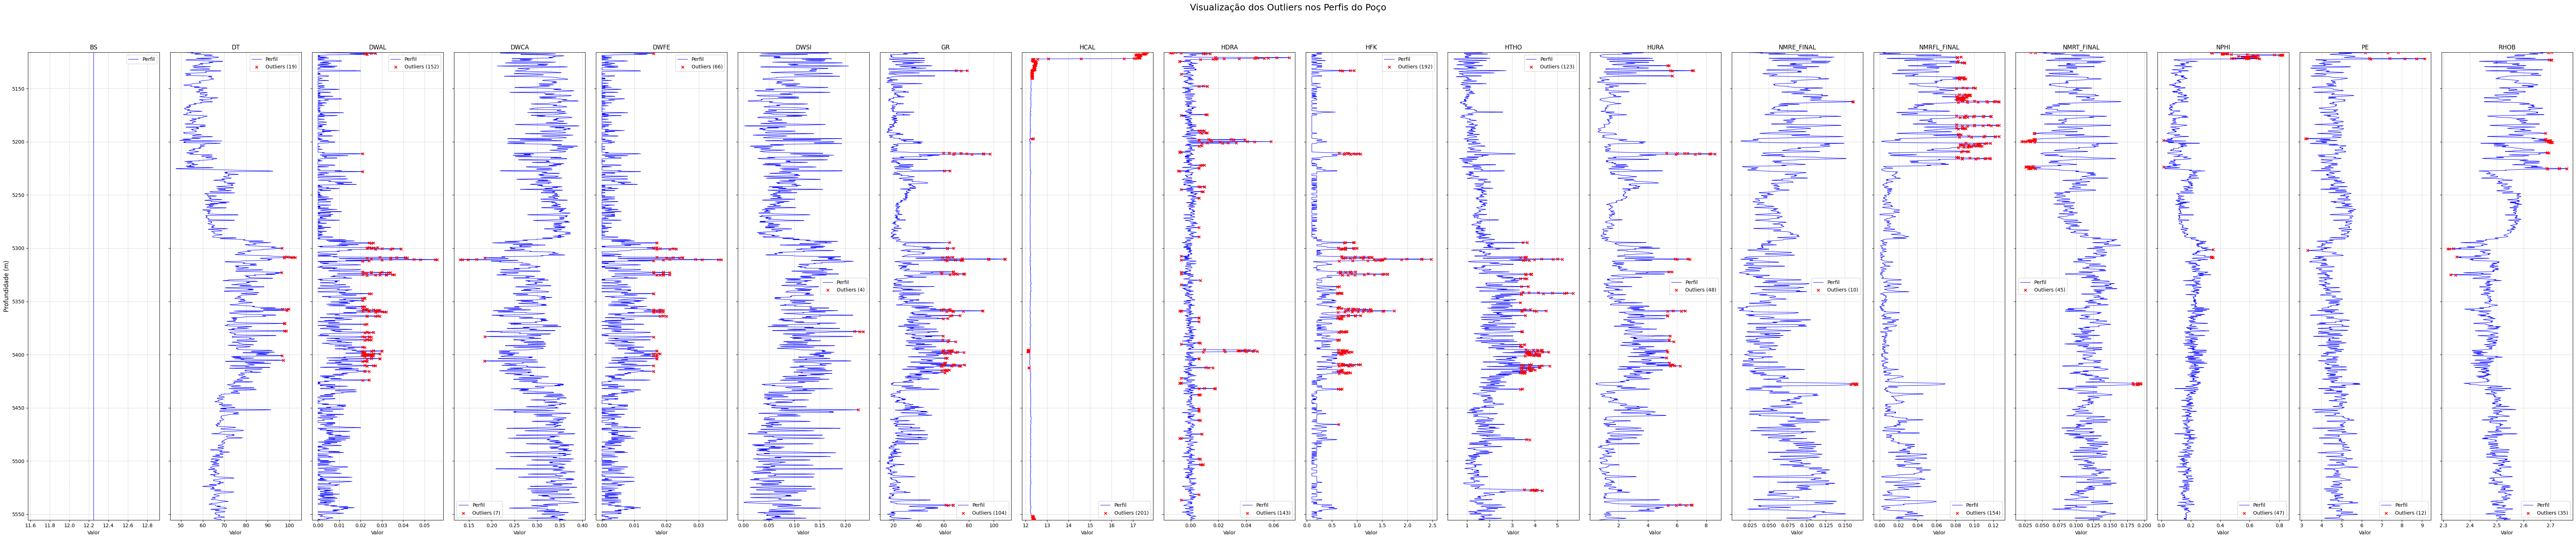

In [66]:
import pandas as pd
import numpy as np
from sklearn.covariance import MinCovDet
from scipy.stats import chi2
# ==============================================================================
# Bloco Principal de Execução
# ==============================================================================
target_curves = [
    'BS', 'DT', 'DWAL', 'DWCA', 'DWFE', 'DWSI',
    'GR', 'HCAL', 'HDRA', 'HFK', 'HTHO', 'HURA',
    'NMRE_FINAL', 'NMRFL_FINAL', 'NMRT_FINAL', 'NPHI', 'PE', 'RHOB'
]
### --- 1. Método: Intervalo Interquartil (IQR) --- ###
logger.info("### EXECUTANDO 1: Método do Intervalo Interquartil (IQR) ###")
outliers_iqr = detectar_anomalia_unidimensional_iqr(df_logs, columns=target_curves, factor_iqr=1.5)
plotar_poco_usando_outliers_identificados(
    df=df_logs,
    df_outliers_mask=outliers_iqr,
    curvas_a_plotar=target_curves
)


1. CONFIGURAÇÃO E DEFINIÇÕES (CORES E CURVAS)


In [67]:
# Definição das Cores para o Gráfico (Essencial para a função de plotagem)
# Removed conflicting CORES_DIAGRAMA definition as it is defined in cell 3490bfe1
COR_PADRAO = '#808080' # Cinza

In [68]:
# Suas colunas de interesse
colunas_para_analise = ['BS', 'DT', 'DWAL', 'DWCA', 'DWFE', 'DWSI', 'GR', 'HCAL', 'HDRA', 'HFK', 'HTHO', 'HURA', 'NMRE_FINAL', 'NMRFL_FINAL', 'NMRT_FINAL', 'NPHI', 'PE', 'RHOB']

In [69]:
# Garante que só usaremos colunas que realmente existem no df_logs
cols_existentes = [c for c in colunas_para_analise if c in df_logs.columns]

In [70]:
logger.info(f">>> Processando {len(df_logs)} linhas...")
logger.info(f">>> Curvas analisadas: {cols_existentes}")

2026-09-04 21:37:53,618 | INFO     | __main__ | >>> Processando 2884 linhas...
2026-09-04 21:37:53,626 | INFO     | __main__ | >>> Curvas analisadas: ['BS', 'DT', 'DWAL', 'DWCA', 'DWFE', 'DWSI', 'GR', 'HCAL', 'HDRA', 'HFK', 'HTHO', 'HURA', 'NMRE_FINAL', 'NMRFL_FINAL', 'NMRT_FINAL', 'NPHI', 'PE', 'RHOB']


In [71]:
# ==============================================================================
# 2. EXECUÇÃO DA ANÁLISE (PIPELINE EXPLORATÓRIO - NÃO É O PIPELINE DO ARTIGO)
# ==============================================================================
# este bloco (unificar_outliers, alpha=0.08,
# threshold Z fixo em 3.0) é um pipeline de 3 classes usado durante a fase
# exploratória do trabalho. Ele NÃO corresponde ao pipeline oficial descrito
# no artigo (Seção 3.3: alphamg=0.01, sistema de 4 flags via
# calcular_mahalanobis_multigrupo + unificar_outliers_por_masks, executado
# logo abaixo). Antes, ambos rodavam sempre, na mesma célula, sem isolamento
# -- risco real de uma execução parcial do notebook exportar/plotar os
# artefatos ERRADOS como se fossem os resultados do artigo. Agora este bloco
# só executa se EXECUTAR_PIPELINE_EXPLORATORIO=True (ver configuração no
# topo do notebook), e grava seus artefatos em pasta própria para nunca
# colidir com 'relatorio_final' (pipeline oficial).
if EXECUTAR_PIPELINE_EXPLORATORIO:
    logger.info("Executando pipeline EXPLORATÓRIO (alpha=0.08) - NÃO usado no artigo.")

    # df_classificacao terá o mesmo tamanho de df_logs, mas com valores 0, 1, 2...
    df_classificacao = unificar_outliers(
        df=df_logs,
        columns=cols_existentes,
        method='zscore',
        zscore_threshold=3.0,
        mahalanobis_alpha=0.08
    )

    # ==============================================================================
    # 3. PREPARAÇÃO DOS DADOS PARA PLOTAGEM
    # ==============================================================================

    # Dados Brutos + Colunas de Status
    # 1. Pegamos o df_classificacao e adicionamos o sufixo "_STATUS" nos nomes das colunas
    #    Ex: A coluna 'GR' vira 'GR_STATUS'
    df_status_renomeado = df_classificacao.add_suffix('_STATUS')

    # 2. Juntamos (concatenamos) lado a lado com os dados originais
    #    O pandas alinha automaticamente pelos índices das linhas
    df_completo_para_plot = pd.concat([df_logs, df_status_renomeado], axis=1)



    # ==============================================================================
    # 5. CHAMADA FINAL DA PLOTAGEM
    # ==============================================================================

    # Defina aqui quais curvas você quer ver agora
    curvas_visualizacao = 'BS', 'DT', 'DWAL', 'DWCA', 'DWFE', 'DWSI', 'GR', 'HCAL', 'HDRA', 'HFK', 'HTHO', 'HURA', 'NMRE_FINAL', 'NMRFL_FINAL', 'NMRT_FINAL', 'NPHI', 'PE', 'RD', 'RHOB', 'RM'

    plotar_logs_com_outliers_individuais(
        df=df_completo_para_plot,       # Passamos o DF unificado aqui
        curvas_a_plotar=curvas_visualizacao,
        sufixo_status='_STATUS'         # O mesmo sufixo que usamos no passo 3
    )
else:
    logger.debug("Pipeline exploratório (EXECUTAR_PIPELINE_EXPLORATORIO=False) ignorado.")

In [72]:
# ==============================================================================
# PIPELINE OFICIAL (usado no artigo - Tabela 2 / Figura 3)
# ==============================================================================
# 0. Calcular as flags MCD por grupo
df_mcd_flags, mapa_curvas = calcular_mahalanobis_multigrupo(df_logs, grupos_mahalanobis,alphamg=0.01)

2026-09-04 21:37:53,725 | INFO     | __main__ | --- Iniciando Cálculo de Mahalanobis por Grupos (versão corrigida: NA preservado + multi-grupo) ---
2026-09-04 21:37:53,727 | INFO     | __main__ | Grupo PETROFISICA_BASICA: p=5 graus de liberdade (curvas: ['RHOB', 'NPHI', 'PE', 'HDRA', 'DT'])
2026-09-04 21:37:57,127 | INFO     | __main__ | Grupo PETROFISICA_BASICA: OK -> 370 anomalias detectadas | 0 linhas <NA> (ausência local de dado no grupo)
2026-09-04 21:37:57,132 | INFO     | __main__ | Grupo ELEMENTARES: p=4 graus de liberdade (curvas: ['DWAL', 'DWCA', 'DWFE', 'DWSI'])
2026-09-04 21:38:03,787 | INFO     | __main__ | Grupo ELEMENTARES: OK -> 450 anomalias detectadas | 0 linhas <NA> (ausência local de dado no grupo)
2026-09-04 21:38:03,791 | INFO     | __main__ | Grupo ESPECTRAL: p=4 graus de liberdade (curvas: ['GR', 'HFK', 'HTHO', 'HURA'])
2026-09-04 21:38:07,463 | INFO     | __main__ | Grupo ESPECTRAL: OK -> 721 anomalias detectadas | 0 linhas <NA> (ausência local de dado no grupo

In [73]:
# 1. Reset
df_logs_run = df_logs.reset_index(drop=True)
df_mcd_run = df_mcd_flags.reset_index(drop=True)

In [74]:
# 2. Diagnóstico
df_status_final = unificar_outliers_por_masks(
    df_logs=df_logs_run,
    df_mcd_flags=df_mcd_run,
    mapa_curva_grupo=mapa_curvas,
    z_cutoff_padrao=3.5,
    z_cutoff_moderado_padrao=1.5,
    z_cutoff_qc=7.0,
    z_cutoff_moderado_qc=3.5)

2026-09-04 21:38:11,470 | INFO     | __main__ | --- UNIFICAÇÃO COM THRESHOLDS DINÂMICOS (NA-aware, multi-grupo) ---
2026-09-04 21:38:11,472 | INFO     | __main__ |    > Padrão: Extremo=3.5 | Moderado=1.5
2026-09-04 21:38:11,474 | INFO     | __main__ |    > QC    : Extremo=7.0 | Moderado=3.5
2026-09-04 21:38:11,560 | INFO     | __main__ | Classificação concluída. Curvas Padrão: 17 | Curvas QC: 2


In [75]:
# 3. Gráficos (Agora usando a função relatorio_grafico que liberou o QC)
relatorio_grafico(df_logs_run, df_status_final, grupos_mahalanobis)

2026-09-04 21:38:11,573 | INFO     | __main__ | --- INICIANDO GERAÇÃO DE RELATÓRIOS ---
2026-09-04 21:38:11,574 | INFO     | __main__ | 1. Gerando Painéis Individuais...
2026-09-04 21:38:12,297 | INFO     | fontTools.subset | maxp pruned
2026-09-04 21:38:12,311 | INFO     | fontTools.subset | cmap pruned
2026-09-04 21:38:12,314 | INFO     | fontTools.subset | kern dropped
2026-09-04 21:38:12,316 | INFO     | fontTools.subset | post pruned
2026-09-04 21:38:12,317 | INFO     | fontTools.subset | FFTM dropped
2026-09-04 21:38:12,322 | INFO     | fontTools.subset | GPOS pruned
2026-09-04 21:38:12,326 | INFO     | fontTools.subset | GSUB pruned
2026-09-04 21:38:12,335 | INFO     | fontTools.subset | glyf pruned
2026-09-04 21:38:12,337 | INFO     | fontTools.subset | Added gid0 to subset
2026-09-04 21:38:12,339 | INFO     | fontTools.subset | Added first four glyphs to subset
2026-09-04 21:38:12,341 | INFO     | fontTools.subset | Closing glyph list over 'GSUB': 25 glyphs before
2026-09-04 2

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [76]:
relatorio_grafico(
    df_logs=df_logs,
    df_status=df_status_final,
    config_grupos=grupos_mahalanobis,
    df_lito=df_lito_p14,
    mapeamento_cores=mapeamento_cores,
    mapeamento_siglas=mapeamento_siglas
)

2026-09-04 21:38:30,024 | INFO     | __main__ | --- Iniciando Processamento de Litologia ---
2026-09-04 21:38:30,038 | INFO     | __main__ | >>> Litologia mapeada e pronta para plotagem!
2026-09-04 21:38:30,039 | INFO     | __main__ | --- INICIANDO GERAÇÃO DE RELATÓRIOS ---
2026-09-04 21:38:30,040 | INFO     | __main__ | 1. Gerando Painéis Individuais...
2026-09-04 21:38:30,653 | INFO     | fontTools.subset | maxp pruned
2026-09-04 21:38:30,666 | INFO     | fontTools.subset | cmap pruned
2026-09-04 21:38:30,667 | INFO     | fontTools.subset | kern dropped
2026-09-04 21:38:30,671 | INFO     | fontTools.subset | post pruned
2026-09-04 21:38:30,672 | INFO     | fontTools.subset | FFTM dropped
2026-09-04 21:38:30,677 | INFO     | fontTools.subset | GPOS pruned
2026-09-04 21:38:30,682 | INFO     | fontTools.subset | GSUB pruned
2026-09-04 21:38:30,690 | INFO     | fontTools.subset | glyf pruned
2026-09-04 21:38:30,692 | INFO     | fontTools.subset | Added gid0 to subset
2026-09-04 21:38:30,

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [77]:
# ==============================================================================
# EXECUÇÃO DA AUDITORIA
# ==============================================================================
auditoria_outliers_cruzados(
    df_logs=df_logs_run,
    df_mcd_flags=df_mcd_run,
    df_status_final=df_status_final,
    mapa_curva_grupo=mapa_curvas,
    func_deteccao_zscore=detectar_anomalia_zscore_robusto,
    z_cutoff_std=3.5,  # Use os mesmos valores que usou no unificar_outliers
    z_cutoff_qc=7.0
)

2026-09-04 21:38:51,317 | INFO     | __main__ | 
2026-09-04 21:38:51,319 | INFO     | __main__ | AUDITORIA DE COERÊNCIA: Z-SCORE vs MAHALANOBIS vs STATUS FINAL
2026-09-04 21:38:51,319 | INFO     | __main__ | ================================================================================
2026-09-04 21:38:51,320 | INFO     | __main__ | 1. Recalculando máscaras brutas para conferência...
2026-09-04 21:38:51,327 | WARNING  | __main__ | Coluna 'BS': MAD é zero, não há outliers a serem detectados. Pulando.
2026-09-04 21:38:51,355 | WARNING  | __main__ | Coluna 'BS': MAD é zero, não há outliers a serem detectados. Pulando.
2026-09-04 21:38:51,423 | INFO     | __main__ | ✅ DIAGNÓSTICO: LÓGICA ÍNTEGRA.


      Curva  Total_Z_Alto  Teoria_RED (Z+ MCD-)  Real_RED (Status 1)  Teoria_GREEN (Z+ MCD+) Check
         DT             1                     1                    1                       0    OK
       DWAL            71                     0                    0                      71    OK
       DWCA             3                     0                    0                       3    OK
       DWFE           154                     0                    0                     154    OK
         GR            95                     0                    0                      95    OK
       HCAL           125                     0                    0                     125    OK
       HDRA            57                     0                    0                      57    OK
        HFK           122                     0                    0                     122    OK
       HTHO            66                     0                    0                      66    OK
       HUR

# 5. Auditoria Metodológica


## 5.1 Sistema de Quatro Flags — Contagens Completas

In [78]:
# =============================================================================
# 5.1 CORREÇÃO 1 — Sistema de quatro flags: contagens completas (Seção 4 do artigo)
# =============================================================================
# DEFINIÇÃO INEQUÍVOCA DA UNIDADE DA FLAG:
#   Cada valor de flag (-1, 0, 1, 2 ou 3) é atribuído a um par (CURVA, PROFUNDIDADE)
#   -- uma célula da matriz df_status_final. Esta é a unidade "curva-profundidade".
#   Duas agregações são derivadas dela, sempre declaradas explicitamente:
#     - "grupo-profundidade": agregação por Grupo Mahalanobis (uma curva em 2
#       grupos, ex. NPHI, contribui para os dois grupos nessa agregação);
#     - "profundidade": uma profundidade conta 1 vez se QUALQUER curva nela tiver
#       flag em {1,2,3} (união sobre curvas).

df_status_full = df_status_final.copy()
df_status_full['DEPTH'] = df_logs_run['DEPTH'].values

status_cols = [c for c in df_status_full.columns if c.endswith('_STATUS')]
curva_de_status = {c: c.replace('_STATUS', '') for c in status_cols}

long_flags = df_status_full.melt(id_vars=['DEPTH'], value_vars=status_cols,
                                  var_name='STATUS_COL', value_name='FLAG')
long_flags['CURVA'] = long_flags['STATUS_COL'].map(curva_de_status)

# --- (a) Contagens de Flag -1/0/1/2/3, unidade = curva-profundidade ---
contagem_flags = long_flags['FLAG'].value_counts().sort_index()
print("Contagem de flags (unidade = curva-profundidade):")
print(contagem_flags.to_string())

# --- (b) Profundidades únicas sinalizadas (união sobre curvas; flags 1/2/3) ---
n_prof_total = df_status_full['DEPTH'].nunique()
prof_sinalizadas = long_flags.loc[long_flags['FLAG'].isin([1, 2, 3]), 'DEPTH'].unique()
prof_nao_classificadas = long_flags.loc[long_flags['FLAG'] == -1, 'DEPTH'].unique()
print(f"\nProfundidades totais no dataset: {n_prof_total}")
print(f"Profundidades únicas com >=1 curva em Flag 1/2/3: {len(prof_sinalizadas)} "
      f"({100*len(prof_sinalizadas)/n_prof_total:.2f}%)")
print(f"Profundidades únicas com >=1 curva Não Classificada (-1): {len(prof_nao_classificadas)} "
      f"({100*len(prof_nao_classificadas)/n_prof_total:.2f}%)")

# --- (c) Tabela grupo x flag (curvas em >1 grupo contam em cada grupo -- regra explícita) ---
def _grupos_da_curva(curva):
    g = mapa_curvas.get(curva, [])
    if isinstance(g, str):
        return [g]
    return list(g) if g else ['(sem grupo)']

long_flags['GRUPOS'] = long_flags['CURVA'].map(_grupos_da_curva)
long_flags_exp = long_flags.explode('GRUPOS')
tabela_grupo_flag = pd.crosstab(long_flags_exp['GRUPOS'], long_flags_exp['FLAG'])
print("\nTabela Grupo x Flag (unidade = curva-profundidade; NPHI conta nos 2 grupos aos quais pertence):")
print(tabela_grupo_flag)

# --- (d) Ocorrências exclusivamente univariadas ---
n_flag1_celulas = int((long_flags['FLAG'] == 1).sum())
por_prof = long_flags.groupby('DEPTH')['FLAG'].apply(lambda s: set(s.unique()))
prof_apenas_univariada = por_prof[por_prof.apply(lambda s: (1 in s) and not ({2, 3} & s))]
print(f"\nCélulas curva-profundidade em Flag 1 (não correlacionada): {n_flag1_celulas}")
print(f"Profundidades cujo ÚNICO tipo de anomalia presente é Flag 1 (univariada isolada): "
      f"{len(prof_apenas_univariada)}")


Contagem de flags (unidade = curva-profundidade):
FLAG
0    49734
1        1
2     1061
3     4000

Profundidades totais no dataset: 2884
Profundidades únicas com >=1 curva em Flag 1/2/3: 1631 (56.55%)
Profundidades únicas com >=1 curva Não Classificada (-1): 0 (0.00%)

Tabela Grupo x Flag (unidade = curva-profundidade; NPHI conta nos 2 grupos aos quais pertence):
FLAG                    0  1    2     3
GRUPOS                                 
(sem grupo)          2884  0    0     0
ELEMENTARES         10489  0  228   819
ESPECTRAL            9824  0  333  1379
PETROFISICA_BASICA  13465  1  114   840
QUALITY_CONTROL      5567  0  125    76
RESSONANCIA         10062  0  298  1176

Células curva-profundidade em Flag 1 (não correlacionada): 1
Profundidades cujo ÚNICO tipo de anomalia presente é Flag 1 (univariada isolada): 0


## 5.2 Recalculo por Intervalo de Profundidade

In [79]:
# =============================================================================
# 5.2 CORREÇÃO 2 — Resultados recalculados POR INTERVALO (não o total da seção)
# =============================================================================
# Notação brasileira: "5.290-5.350 m" = profundidades 5290 a 5350 m (o ponto é
# separador de milhar, não decimal). Ajuste os limites abaixo se a intenção do
# manuscrito for outra.
intervalos_artigo = {
    '5130-5150 m': (5130.0, 5150.0),
    '5250-5355 m': (5250.0, 5355.0),
    '5290-5350 m': (5290.0, 5350.0),
}

resumo_intervalos = []
for nome, (topo, base) in intervalos_artigo.items():
    sub = long_flags[(long_flags['DEPTH'] >= topo) & (long_flags['DEPTH'] <= base)]
    print(f"\n### Intervalo {nome} ###")
    if sub.empty:
        print("  -> Nenhuma amostra de DEPTH encontrada neste intervalo. "
              "Verifique se DEPTH está em metros e se os limites correspondem "
              "à faixa amostrada no poço (STRT/STOP).")
        continue
    n_prof_intervalo = sub['DEPTH'].nunique()
    prof_unicas = sub.loc[sub['FLAG'].isin([1, 2, 3]), 'DEPTH'].unique()
    contagem = sub['FLAG'].value_counts().sort_index()
    print(f"  Profundidades amostradas no intervalo: {n_prof_intervalo}")
    print(f"  Profundidades únicas sinalizadas (Flag 1/2/3): {len(prof_unicas)}")
    print("  Contagem de flags (curva-profundidade):")
    print(contagem.to_string())
    resumo_intervalos.append({
        'Intervalo': nome, 'Profundidades_amostradas': n_prof_intervalo,
        'Profundidades_sinalizadas': len(prof_unicas),
        'Flag_-1': int(contagem.get(-1, 0)), 'Flag_0': int(contagem.get(0, 0)),
        'Flag_1': int(contagem.get(1, 0)), 'Flag_2': int(contagem.get(2, 0)),
        'Flag_3': int(contagem.get(3, 0)),
    })

df_resumo_intervalos = pd.DataFrame(resumo_intervalos)
print("\nResumo consolidado (usar estes números em main.tex, substituindo 450/721):")
print(df_resumo_intervalos.to_string(index=False))



### Intervalo 5130-5150 m ###
  Profundidades amostradas no intervalo: 132
  Profundidades únicas sinalizadas (Flag 1/2/3): 132
  Contagem de flags (curva-profundidade):
FLAG
0    2148
2      58
3     302

### Intervalo 5250-5355 m ###
  Profundidades amostradas no intervalo: 689
  Profundidades únicas sinalizadas (Flag 1/2/3): 242
  Contagem de flags (curva-profundidade):
FLAG
0    12228
1        1
2      196
3      666

### Intervalo 5290-5350 m ###
  Profundidades amostradas no intervalo: 394
  Profundidades únicas sinalizadas (Flag 1/2/3): 225
  Contagem de flags (curva-profundidade):
FLAG
0    6677
1       1
2     194
3     614

Resumo consolidado (usar estes números em main.tex, substituindo 450/721):
  Intervalo  Profundidades_amostradas  Profundidades_sinalizadas  Flag_-1  Flag_0  Flag_1  Flag_2  Flag_3
5130-5150 m                       132                        132        0    2148       0      58     302
5250-5355 m                       689                        242      

## 5.3 Tabela 2 Corrigida (Denominadores por Grupo) e Efeito do Bug de `dropna()


In [80]:
# =============================================================================
# 5.3 CORREÇÃO 3 (efeito quantificado) + CORREÇÃO 4 — Denominadores da Tabela 2
# =============================================================================
# df_logs_before_dropna foi capturado ANTES do dropna() global (linha a linha,
# sobre as 27 curvas). Com ele conseguimos reportar, por grupo: registros
# válidos, ausentes, ocorrências e taxa sobre válidos -- em vez de dividir tudo
# por um único N=2884 assumido implicitamente.

linhas_tabela2 = []
for grupo, curvas in grupos_mahalanobis.items():
    curvas_exist = [c for c in curvas if c in df_logs_before_dropna.columns]
    if not curvas_exist:
        continue
    total_bruto = len(df_logs_before_dropna)
    validos_grupo = df_logs_before_dropna[curvas_exist].dropna().shape[0]
    ausentes_grupo = total_bruto - validos_grupo

    cols_status_grupo = [f"{c}_STATUS" for c in curvas_exist if f"{c}_STATUS" in df_status_final.columns]
    ocorrencias = int((df_status_final[cols_status_grupo].isin([1, 2, 3])).sum().sum()) if cols_status_grupo else 0
    validos_pipeline_oficial = len(df_logs_run)  # uniforme por construção (dropna global)
    denominador_oficial = validos_pipeline_oficial * len(cols_status_grupo)
    taxa_oficial = 100 * ocorrencias / denominador_oficial if denominador_oficial else float('nan')

    linhas_tabela2.append({
        'Grupo': grupo,
        'Curvas_no_grupo': len(curvas_exist),
        'Registros_validos_por_grupo_pre_dropna_global': validos_grupo,
        'Registros_ausentes_por_grupo_pre_dropna_global': ausentes_grupo,
        'Registros_validos_no_pipeline_oficial (pos-dropna-global, N uniforme)': validos_pipeline_oficial,
        'Ocorrencias_Flags_1_2_3': ocorrencias,
        'Taxa_sobre_validos_oficial (%)': round(taxa_oficial, 3),
    })

tabela2_corrigida = pd.DataFrame(linhas_tabela2)
print("Tabela 2 corrigida (N explícito por grupo, não assumido):")
print(tabela2_corrigida.to_string(index=False))

print("\nNOTA METODOLÓGICA IMPORTANTE:")
print("O N é de fato uniforme (2884) para todos os grupos no pipeline OFICIAL "
      "-- mas isso é uma CONSEQUÊNCIA do dropna() global linha-a-linha aplicado "
      "sobre as 27 curvas ANTES da análise por grupo, e não uma propriedade "
      "intrínseca dos dados. A tabela abaixo mostra quantos registros cada "
      "grupo teria disponíveis se o dropna fosse feito apenas por grupo (a "
      "estratégia para a qual calcular_mahalanobis_multigrupo foi originalmente "
      "projetada, conforme sua própria docstring).")

# --- Pipeline alternativo: dropna por grupo (não global) ---------------------
df_logs_before_dropna_reset = df_logs_before_dropna.reset_index()
if 'DEPTH' not in df_logs_before_dropna_reset.columns and df_logs_before_dropna.index.name == 'DEPTH':
    df_logs_before_dropna_reset = df_logs_before_dropna_reset.rename(columns={'index': 'DEPTH'})

df_mcd_flags_alt, mapa_curvas_alt = calcular_mahalanobis_multigrupo(
    df_logs_before_dropna_reset, grupos_mahalanobis, alphamg=0.01
)
n_celulas_na_alt = int(df_mcd_flags_alt.isna().sum().sum())
print(f"\nPipeline alternativo (dropna por grupo): {n_celulas_na_alt} células de contexto "
      f"(grupo-linha) ficaram <NA> por ausência local de dado -- estas seriam "
      f"incorretamente tratadas como 'Normal/False' na versão original do código.")
print(df_mcd_flags_alt.notna().sum().rename('linhas_validas_por_grupo (dropna por grupo)').to_frame())


2026-09-04 21:38:51,954 | INFO     | __main__ | --- Iniciando Cálculo de Mahalanobis por Grupos (versão corrigida: NA preservado + multi-grupo) ---
2026-09-04 21:38:51,955 | INFO     | __main__ | Grupo PETROFISICA_BASICA: p=5 graus de liberdade (curvas: ['RHOB', 'NPHI', 'PE', 'HDRA', 'DT'])


Tabela 2 corrigida (N explícito por grupo, não assumido):
             Grupo  Curvas_no_grupo  Registros_validos_por_grupo_pre_dropna_global  Registros_ausentes_por_grupo_pre_dropna_global  Registros_validos_no_pipeline_oficial (pos-dropna-global, N uniforme)  Ocorrencias_Flags_1_2_3  Taxa_sobre_validos_oficial (%)
PETROFISICA_BASICA                5                                           2910                                           22671                                                                   2884                      955                           6.623
       ELEMENTARES                4                                           6081                                           19500                                                                   2884                     1047                           9.076
         ESPECTRAL                4                                           6047                                           19534                                   

2026-09-04 21:38:53,866 | INFO     | __main__ | Grupo PETROFISICA_BASICA: OK -> 395 anomalias detectadas | 22671 linhas <NA> (ausência local de dado no grupo)
2026-09-04 21:38:53,868 | INFO     | __main__ | Grupo ELEMENTARES: p=4 graus de liberdade (curvas: ['DWAL', 'DWCA', 'DWFE', 'DWSI'])
2026-09-04 21:38:57,543 | INFO     | __main__ | Grupo ELEMENTARES: OK -> 1403 anomalias detectadas | 19500 linhas <NA> (ausência local de dado no grupo)
2026-09-04 21:38:57,544 | INFO     | __main__ | Grupo ESPECTRAL: p=4 graus de liberdade (curvas: ['GR', 'HFK', 'HTHO', 'HURA'])
2026-09-04 21:38:59,487 | INFO     | __main__ | Grupo ESPECTRAL: OK -> 1459 anomalias detectadas | 19534 linhas <NA> (ausência local de dado no grupo)
2026-09-04 21:38:59,488 | INFO     | __main__ | Grupo RESSONANCIA: p=4 graus de liberdade (curvas: ['NMRE_FINAL', 'NMRFL_FINAL', 'NMRT_FINAL', 'NPHI'])
2026-09-04 21:39:02,396 | INFO     | __main__ | Grupo RESSONANCIA: OK -> 1574 anomalias detectadas | 19672 linhas <NA> (ausê


Pipeline alternativo (dropna por grupo): 103828 células de contexto (grupo-linha) ficaram <NA> por ausência local de dado -- estas seriam incorretamente tratadas como 'Normal/False' na versão original do código.
                    linhas_validas_por_grupo (dropna por grupo)
PETROFISICA_BASICA                                         2910
ELEMENTARES                                                6081
ESPECTRAL                                                  6047
RESSONANCIA                                                5909
QUALITY_CONTROL                                            3130


## 5.4 Análise de Sensibilidade (α e Thresholds de Z-score) — Executada

In [81]:
# =============================================================================
# 5.4 CORREÇÃO 5 — Análise de sensibilidade
# =============================================================================
# Varre alpha (limiar do MCD) e o threshold de Z-score padrão, reportando a
# estabilidade das contagens de flag e das profundidades sinalizadas.
#
# O MinCovDet assume distribuições aproximadamente gaussianas/unimodais e
# simétricas, e a documentação do scikit-learn pressupõe observações
# independentes -- premissa discutível para perfis sequenciais em profundidade
# (autocorrelados). A estratificação abaixo (por litofácies e por janela de
# profundidade) é uma forma de diagnosticar, não de eliminar, esse problema.

alphas_teste = [0.10, 0.05, 0.01, 0.005, 0.001]
z_padrao_teste = [3.0, 3.5, 4.0]

resultados_sensibilidade = []
sets_prof = {}
for alpha in alphas_teste:
    df_mcd_s, mapa_s = calcular_mahalanobis_multigrupo(df_logs_run, grupos_mahalanobis, alphamg=alpha)
    for zc in z_padrao_teste:
        df_status_s = unificar_outliers_por_masks(
            df_logs=df_logs_run, df_mcd_flags=df_mcd_s, mapa_curva_grupo=mapa_s,
            z_cutoff_padrao=zc, z_cutoff_moderado_padrao=zc / 2.33,
            z_cutoff_qc=7.0, z_cutoff_moderado_qc=3.5)
        cols = [c for c in df_status_s.columns if c.endswith('_STATUS')]
        df_status_s2 = df_status_s[cols].copy()
        df_status_s2['DEPTH'] = df_logs_run['DEPTH'].values
        long_s = df_status_s2.melt(id_vars=['DEPTH'], value_vars=cols, value_name='FLAG')
        prof_flag = set(long_s.loc[long_s['FLAG'].isin([1, 2, 3]), 'DEPTH'].unique())
        sets_prof[(alpha, zc)] = prof_flag
        resultados_sensibilidade.append({
            'alpha': alpha, 'z_cutoff_padrao': zc,
            'Flag_-1': int((long_s['FLAG'] == -1).sum()),
            'Flag_1': int((long_s['FLAG'] == 1).sum()),
            'Flag_2': int((long_s['FLAG'] == 2).sum()),
            'Flag_3': int((long_s['FLAG'] == 3).sum()),
            'Profundidades_sinalizadas': len(prof_flag),
        })

df_sensibilidade = pd.DataFrame(resultados_sensibilidade)

baseline_key = (0.01, 3.5)
baseline_set = sets_prof.get(baseline_key, set())

def _jaccard(a, b):
    if not a and not b:
        return 1.0
    return len(a & b) / len(a | b) if (a | b) else float('nan')

df_sensibilidade['Jaccard_vs_baseline(alpha=0.01,z=3.5)'] = [
    round(_jaccard(sets_prof[(row.alpha, row.z_cutoff_padrao)], baseline_set), 4)
    for row in df_sensibilidade.itertuples()
]

print("Estabilidade das contagens/profundidades sob variação de alpha e do threshold de Z-score:")
print(df_sensibilidade.to_string(index=False))

# --- Estratificação por litofácies ---
if 'df_lito_p14' in globals() and df_lito_p14 is not None and 'MD' in df_lito_p14.columns:
    df_status_lito = df_status_final.copy()
    df_status_lito['DEPTH'] = df_logs_run['DEPTH'].values
    df_status_lito = df_status_lito.sort_values('DEPTH')
    df_lito_sorted = df_lito_p14.dropna(subset=['MD']).sort_values('MD')
    coluna_facies = 'Lito Plug' if 'Lito Plug' in df_lito_sorted.columns else df_lito_sorted.columns[-1]
    df_status_lito = pd.merge_asof(df_status_lito, df_lito_sorted[['MD', coluna_facies]],
                                    left_on='DEPTH', right_on='MD', direction='nearest')
    cols_status = [c for c in df_status_lito.columns if c.endswith('_STATUS')]
    long_lito = df_status_lito.melt(id_vars=['DEPTH', coluna_facies], value_vars=cols_status, value_name='FLAG')
    tabela_facies = pd.crosstab(long_lito[coluna_facies], long_lito['FLAG'])
    print("\nEstratificação por litofácies (unidade = curva-profundidade):")
    print(tabela_facies)
else:
    print("\n(df_lito_p14 sem coluna 'MD' -- estratificação por litofácies pulada.)")

# --- Estratificação por janela de profundidade (bins de 100 m) ---
df_status_full = df_status_final.copy()
df_status_full['DEPTH'] = df_logs_run['DEPTH'].values

status_cols = [c for c in df_status_full.columns if c.endswith('_STATUS')]
curva_de_status = {c: c.replace('_STATUS', '') for c in status_cols}

long_flags = df_status_full.melt(id_vars=['DEPTH'], value_vars=status_cols,
                                  var_name='STATUS_COL', value_name='FLAG')
long_flags['CURVA'] = long_flags['STATUS_COL'].map(curva_de_status)

depth_min = float(df_logs_run['DEPTH'].min())
depth_max = float(df_logs_run['DEPTH'].max())
bins = np.arange((depth_min // 100) * 100, depth_max + 100, 100)
long_flags_bin = long_flags.copy()
long_flags_bin['DEPTH_BIN'] = pd.cut(long_flags_bin['DEPTH'], bins=bins)
tabela_janela = pd.crosstab(long_flags_bin['DEPTH_BIN'], long_flags_bin['FLAG'])
print("\nEstratificação por janela de profundidade (100 m; unidade = curva-profundidade):")
print(tabela_janela)


2026-09-04 21:39:02,784 | INFO     | __main__ | --- Iniciando Cálculo de Mahalanobis por Grupos (versão corrigida: NA preservado + multi-grupo) ---
2026-09-04 21:39:02,785 | INFO     | __main__ | Grupo PETROFISICA_BASICA: p=5 graus de liberdade (curvas: ['RHOB', 'NPHI', 'PE', 'HDRA', 'DT'])
2026-09-04 21:39:04,127 | INFO     | __main__ | Grupo PETROFISICA_BASICA: OK -> 755 anomalias detectadas | 0 linhas <NA> (ausência local de dado no grupo)
2026-09-04 21:39:04,129 | INFO     | __main__ | Grupo ELEMENTARES: p=4 graus de liberdade (curvas: ['DWAL', 'DWCA', 'DWFE', 'DWSI'])
2026-09-04 21:39:06,007 | INFO     | __main__ | Grupo ELEMENTARES: OK -> 828 anomalias detectadas | 0 linhas <NA> (ausência local de dado no grupo)
2026-09-04 21:39:06,008 | INFO     | __main__ | Grupo ESPECTRAL: p=4 graus de liberdade (curvas: ['GR', 'HFK', 'HTHO', 'HURA'])
2026-09-04 21:39:07,698 | INFO     | __main__ | Grupo ESPECTRAL: OK -> 1011 anomalias detectadas | 0 linhas <NA> (ausência local de dado no grup

Estabilidade das contagens/profundidades sob variação de alpha e do threshold de Z-score:
 alpha  z_cutoff_padrao  Flag_-1  Flag_1  Flag_2  Flag_3  Profundidades_sinalizadas  Jaccard_vs_baseline(alpha=0.01,z=3.5)
 0.100              3.0      132       0    1581    5798                       1974                                 0.8262
 0.100              3.5        0       0    1062    5092                       1851                                 0.8811
 0.100              4.0        0       0     799    4151                       1731                                 0.8803
 0.050              3.0      132       1    1580    5220                       1853                                 0.8802
 0.050              3.5        0       0    1062    4710                       1771                                 0.9209
 0.050              4.0        0       0     799    3935                       1677                                 0.9044
 0.010              3.0      132       9    1572 

In [82]:
import time

In [98]:
# Registra o carimbo de data/hora do fim da execução
fim_notebook = time.time()
print(f"Fim do notebook: {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(fim_notebook))}")

Fim do notebook: 2026-09-04 21:41:25


In [84]:
# Calcula o tempo total em segundos
tempo_total = fim_notebook - inicio_notebook

In [85]:
# Converte e formata o tempo para horas, minutos e segundos
horas = int(tempo_total // 3600)
minutos = int((tempo_total % 3600) // 60)
segundos = tempo_total % 60

In [86]:
logger.info("-" * 50)
logger.info("🎉 PROCESSO COMPLETO CONCLUÍDO COM SUCESSO!")
if horas > 0:
    logger.info(f"⏱️ Tempo total de execução: {horas}h {minutos}min {segundos:.2f}s")
elif minutos > 0:
    logger.info(f"⏱️ Tempo total de execução: {minutos}min {segundos:.2f}s")
else:
    logger.info(f"⏱️ Tempo total de execução: {segundos:.2f} segundos")
logger.info("-" * 50)

2026-09-04 21:39:40,260 | INFO     | __main__ | --------------------------------------------------
2026-09-04 21:39:40,263 | INFO     | __main__ | 🎉 PROCESSO COMPLETO CONCLUÍDO COM SUCESSO!
2026-09-04 21:39:40,265 | INFO     | __main__ | ⏱️ Tempo total de execução: 2min 6.57s
2026-09-04 21:39:40,267 | INFO     | __main__ | --------------------------------------------------


In [87]:
curvas_teste = [
    'DT', 'DWAL', 'GR', 'HFK', 'HTHO', 'HURA'
]

In [88]:
# Filter out curves that are not in df_logs
curvas_teste_existentes = [c for c in curvas_teste if c in df_logs.columns]

In [89]:
# 2. Execução das detecções
# Threshold 3.0 para o padrão e 3.5 para o robusto
mascara_padrao = detectar_anomalia_zscore_padrao(df_logs, columns=curvas_teste_existentes, threshold=3.0)
mascara_robusta = detectar_anomalia_zscore_robusto(df_logs, columns=curvas_teste_existentes, threshold=3.5)

2026-09-04 21:39:40,321 | INFO     | __main__ | ### COMPARANDO MÉTODOS: Z-SCORE PADRÃO (AZUL) VS ROBUSTO (VERMELHO) ###


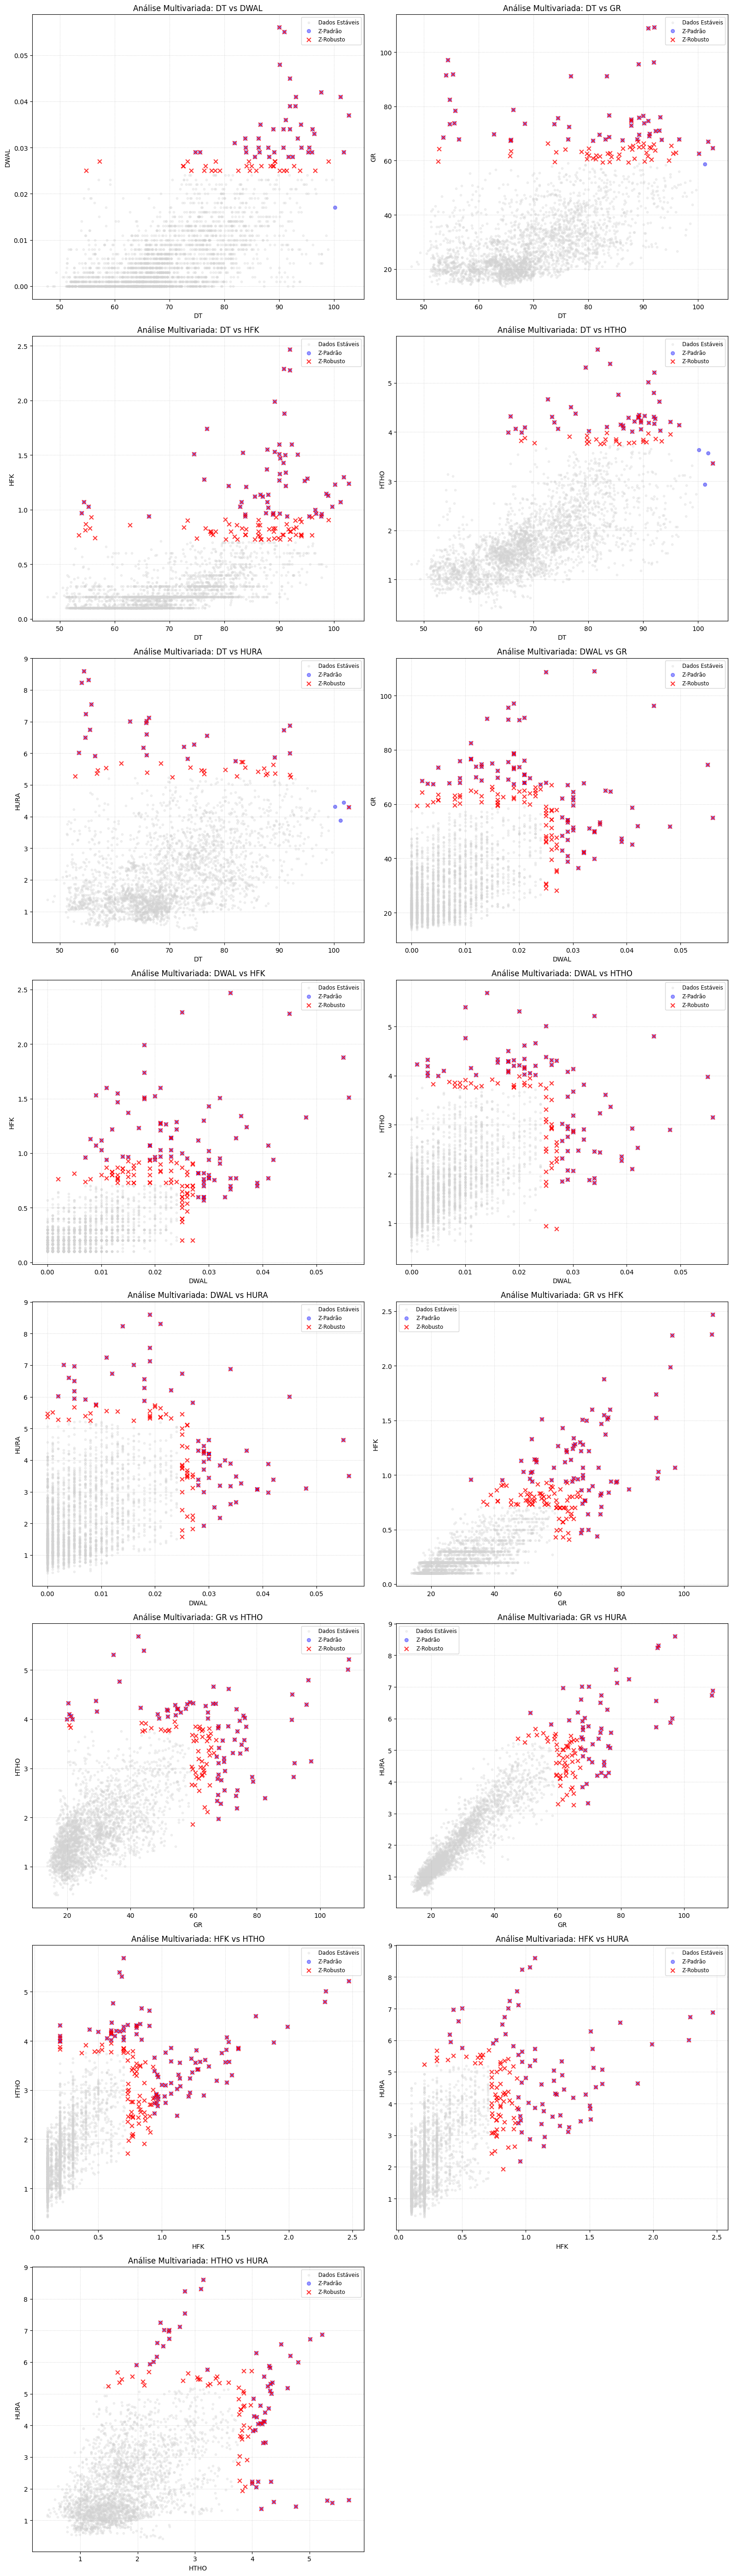

In [90]:
# 3. Visualização Comparativa
logger.info("### COMPARANDO MÉTODOS: Z-SCORE PADRÃO (AZUL) VS ROBUSTO (VERMELHO) ###")
plotar_crossplots_comparativos(df_logs, mascara_padrao, mascara_robusta, curvas_teste_existentes)

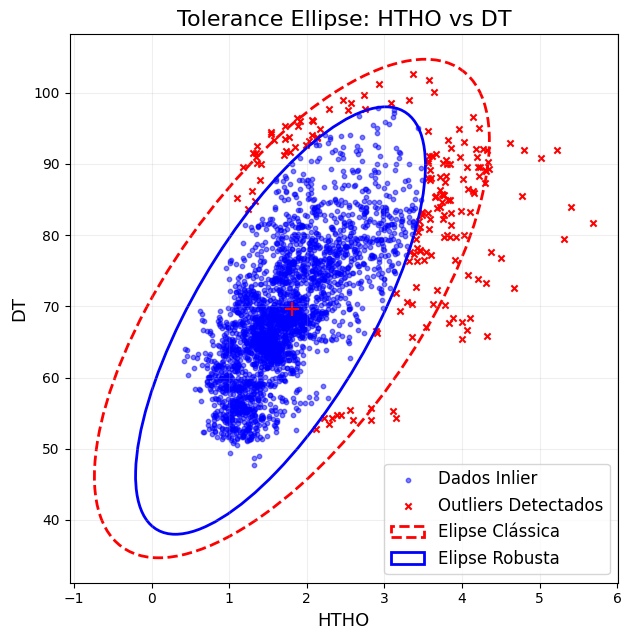

In [91]:

colunas_para_comparar = ['HTHO', 'DT']
plotar_analise_elipses_robusta(df_logs, colunas_para_comparar, threshold=3.5)

In [92]:
# 1. Definição da lista de elementos
meus_elementos = ['HTHO', 'DT']

In [93]:
# 2. Criar o novo DataFrame filtrado
# O método .intersection garante que o código não quebre caso uma das colunas não exista
colunas_para_filtrar = df_logs.columns.intersection(meus_elementos)
df_novo = df_logs[colunas_para_filtrar].copy()

In [94]:
# 3. (Opcional) Adicionar a coluna de profundidade se for necessária para plots futuros
if 'DEPTH' in df_logs.columns and 'DEPTH' not in df_novo.columns:
    df_novo.insert(0, 'DEPTH', df_logs['DEPTH'])

In [95]:
# Visualizar o resultado
logger.info(f"Colunas no novo DataFrame: {df_novo.columns.tolist()}")
df_novo.head()

2026-09-04 21:39:47,905 | INFO     | __main__ | Colunas no novo DataFrame: ['DEPTH', 'DT', 'HTHO']


,DEPTH,DT,HTHO
0,5116.009,52.222,1.323
1,5116.161,53.187,1.591
2,5116.314,54.686,1.683
3,5116.466,55.432,1.535
4,5116.618,55.590,1.241


In [96]:
# =============================================================================
# BLOCO DE VALIDAÇÃO (ipytest)
# =============================================================================
import os
import hashlib
import numpy as np
import pandas as pd
import pytest
import ipytest

# Limpa testes antigos da memória do Colab para evitar conflitos (fantasmas)
ipytest.clean()
ipytest.autoconfig()

@pytest.fixture(scope="module")
def dataset_oficial():
    file_path = '/content/drive/MyDrive/artigo outliers/dados_artigo/sapinhoa/9-SPS-95-SP_BASE.las'
    if not os.path.exists(file_path):
        pytest.skip(f"Arquivo não encontrado: {file_path}")

    import lasio
    las = lasio.read(file_path, encoding='latin-1')
    df = las.df().copy()
    df.rename(columns={'DEPT': 'DEPTH', 'GR_EDTC': 'GR', 'RHOB_EDTC': 'RHOB', 'NPHI_EDTC': 'NPHI'}, inplace=True)
    df.replace(las.well.NULL.value, np.nan, inplace=True)
    df.reset_index(inplace=True)

    curvas_18 = ['BS', 'DT', 'DWAL', 'DWCA', 'DWFE', 'DWSI', 'GR', 'HCAL', 'HDRA', 'HFK', 'HTHO', 'HURA', 'NMRE_FINAL', 'NMRFL_FINAL', 'NMRT_FINAL', 'NPHI', 'PE', 'RHOB']
    df_clean = df[['DEPTH'] + curvas_18].dropna().reset_index(drop=True)
    data_hash = hashlib.md5(pd.util.hash_pandas_object(df_clean, index=True).values).hexdigest()

    return df_clean, curvas_18, data_hash, las

# =============================================================================
# 1. REPRODUÇÃO BASE E TABELA DE CURVAS
# =============================================================================
def test_tabela_curvas_filtrada(dataset_oficial):
    _, curvas_18, _, las = dataset_oficial

    tabela = []
    for c in curvas_18:
        unidade = next((cv.unit for cv in las.curves if cv.mnemonic == c), 'N/A')
        desc = next((cv.descr for cv in las.curves if cv.mnemonic == c), 'N/A')
        tabela.append({'CURVA': c, 'UNIDADE': unidade, 'DESCRICAO': desc})

    pd.DataFrame(tabela).to_csv('13_curvas_unidades_grupos_filtrado.csv', index=False)
    assert len(tabela) == 18

def test_reproduz_cenario_base_artigo(dataset_oficial):
    df_clean, curvas_18, data_hash, _ = dataset_oficial
    z_s_exact = 1.5021459

    df_mcd, mapa = calcular_mahalanobis_multigrupo(df_clean, grupos_mahalanobis, alphamg=0.01)
    df_status = unificar_outliers_por_masks(
        df_clean, df_mcd, mapa, z_cutoff_padrao=3.5, z_cutoff_moderado_padrao=z_s_exact, z_cutoff_qc=7.0, z_cutoff_moderado_qc=3.5
    )

    cols = [f"{c}_STATUS" for c in curvas_18]
    matriz = df_status[cols]

    assert (matriz == 0).sum().sum() == 46861
    assert (matriz == 1).sum().sum() == 1
    assert (matriz == 2).sum().sum() == 1061
    assert (matriz == 3).sum().sum() == 3989
    assert (matriz > 0).any(axis=1).sum() == 1631

# =============================================================================
# 2. ISOLAMENTO DAS 11 CÉLULAS DIVERGENTES (1.5 vs 1.502)
# =============================================================================
def test_isola_11_celulas_divergentes(dataset_oficial):
    df_clean, curvas_18, _, _ = dataset_oficial

    df_mcd, mapa = calcular_mahalanobis_multigrupo(df_clean, grupos_mahalanobis, alphamg=0.01)

    status_150 = unificar_outliers_por_masks(df_clean, df_mcd, mapa, z_cutoff_padrao=3.5, z_cutoff_moderado_padrao=1.5, z_cutoff_qc=7.0, z_cutoff_moderado_qc=3.5)
    status_1502 = unificar_outliers_por_masks(df_clean, df_mcd, mapa, z_cutoff_padrao=3.5, z_cutoff_moderado_padrao=1.5021459, z_cutoff_qc=7.0, z_cutoff_moderado_qc=3.5)

    cols = [f"{c}_STATUS" for c in curvas_18]
    diff_mask = status_150[cols] != status_1502[cols]

    divergencias = []
    idx_linha, idx_col = np.where(diff_mask)
    for r, c in zip(idx_linha, idx_col):
        curva = cols[c].replace('_STATUS', '')
        divergencias.append({
            'DEPTH': df_clean.loc[r, 'DEPTH'],
            'CURVA': curva,
            'STATUS_1.50': status_150.loc[r, cols[c]],
            'STATUS_1.502': status_1502.loc[r, cols[c]],
            'VALOR_REAL': df_clean.loc[r, curva]
        })

    pd.DataFrame(divergencias).to_csv('06_celulas_divergentes_zs.csv', index=False)
    assert len(divergencias) == 11

# =============================================================================
# 3. SENSIBILIDADE ESTRUTURADA
# =============================================================================
def test_sensibilidade_estruturada_expandida(dataset_oficial):
    df_clean, curvas_18, data_hash, _ = dataset_oficial
    z_s_exact = 1.5021459

    grade = [
        {'id': 'BASE', 'z_e': 3.5, 'z_s': z_s_exact, 'qc_e': 7.0, 'qc_s': 3.5},
        {'id': 'ALT_ZS_1.25', 'z_e': 3.5, 'z_s': 1.25, 'qc_e': 7.0, 'qc_s': 3.5},
        {'id': 'ALT_ZS_1.75', 'z_e': 3.5, 'z_s': 1.75, 'qc_e': 7.0, 'qc_s': 3.5},
        {'id': 'ALT_QCE_6.5', 'z_e': 3.5, 'z_s': z_s_exact, 'qc_e': 6.5, 'qc_s': 3.5},
        {'id': 'ALT_QCE_7.5', 'z_e': 3.5, 'z_s': z_s_exact, 'qc_e': 7.5, 'qc_s': 3.5},
        {'id': 'ALT_QCS_3.0', 'z_e': 3.5, 'z_s': z_s_exact, 'qc_e': 7.0, 'qc_s': 3.0},
        {'id': 'ALT_QCS_4.0', 'z_e': 3.5, 'z_s': z_s_exact, 'qc_e': 7.0, 'qc_s': 4.0},
    ]

    df_mcd, mapa = calcular_mahalanobis_multigrupo(df_clean, grupos_mahalanobis, alphamg=0.01)
    resultados = []
    mask_base = None

    for c in grade:
        status = unificar_outliers_por_masks(df_clean, df_mcd, mapa, z_cutoff_padrao=c['z_e'], z_cutoff_moderado_padrao=c['z_s'], z_cutoff_qc=c['qc_e'], z_cutoff_moderado_qc=c['qc_s'])
        matriz = status[[f"{c}_STATUS" for c in curvas_18]]
        depths_atual = (matriz > 0).any(axis=1)

        if c['id'] == 'BASE':
            mask_base = depths_atual
            jaccard = 1.0
        else:
            uniao = (depths_atual | mask_base).sum()
            jaccard = (depths_atual & mask_base).sum() / uniao if uniao > 0 else 1.0

        resultados.append({
            'SCENARIO_ID': c['id'], 'Z_S': round(c['z_s'], 4), 'QC_E': c['qc_e'], 'QC_S': c['qc_s'],
            'FLAG_2': (matriz == 2).sum().sum(), 'FLAG_3': (matriz == 3).sum().sum(),
            'DEPTHS_SINALIZADAS': depths_atual.sum(), 'JACCARD': round(jaccard, 4)
        })

    pd.DataFrame(resultados).to_csv('07_sensibilidade_expandida.csv', index=False)

# =============================================================================
# 4. MULTIPLICIDADE E PERSISTÊNCIA ESPACIAL
# =============================================================================
def test_multiplicidade_e_persistencia(dataset_oficial):
    df_clean, curvas_18, _, _ = dataset_oficial
    z_s_exact = 1.5021459

    df_mcd, mapa = calcular_mahalanobis_multigrupo(df_clean, grupos_mahalanobis, alphamg=0.01)
    status = unificar_outliers_por_masks(df_clean, df_mcd, mapa, z_cutoff_padrao=3.5, z_cutoff_moderado_padrao=z_s_exact, z_cutoff_qc=7.0, z_cutoff_moderado_qc=3.5)

    matriz_mask = status[[f"{c}_STATUS" for c in curvas_18]] > 0
    mask_any = matriz_mask.any(axis=1)

    # Multiplicidade
    n_curvas = matriz_mask.sum(axis=1)[mask_any]

    group_counts = []
    for i, row in matriz_mask[mask_any].iterrows():
        grp_set = set()
        for c in curvas_18:
            if row[f"{c}_STATUS"]:
                grps = mapa.get(c, [c])
                grp_set.update(grps if isinstance(grps, list) else [grps])
        group_counts.append(len(grp_set))
    n_grupos = pd.Series(group_counts, index=n_curvas.index)

    pd.DataFrame([{
        '1_CURVA': (n_curvas == 1).sum(), '2_CURVAS': (n_curvas == 2).sum(),
        '3_A_5_CURVAS': ((n_curvas >= 3) & (n_curvas <= 5)).sum(), 'MAIS_DE_5_CURVAS': (n_curvas > 5).sum(),
        '1_GRUPO': (n_grupos == 1).sum(), '2_GRUPOS': (n_grupos == 2).sum(), '3_OU_MAIS_GRUPOS': (n_grupos >= 3).sum(),
    }]).to_csv('10_multiplicidade_profundidade.csv', index=False)

    # Persistência
    quebra_profundidade = df_clean['DEPTH'].diff() > 0.2
    mudancas = mask_any.ne(mask_any.shift()) | quebra_profundidade
    mudancas_cumsum = mudancas.cumsum()

    blocos = df_clean.loc[mask_any].groupby(mudancas_cumsum.loc[mask_any])
    extensoes = blocos['DEPTH'].max() - blocos['DEPTH'].min()

    id_max = extensoes.idxmax()
    bloco_max = blocos.get_group(id_max)
    pd.DataFrame([{
        'START_DEPTH': bloco_max['DEPTH'].min(), 'END_DEPTH': bloco_max['DEPTH'].max(),
        'LENGTH_M': extensoes.max(), 'N_SAMPLES': len(bloco_max)
    }]).to_csv('09_inspecao_segmento_maximo.csv', index=False)

    pd.DataFrame([{
        'TOTAL_SEGMENTOS_ANOMALOS': len(extensoes),
        'OCORRENCIAS_ISOLADAS_0M': (extensoes == 0).sum(),
        'DEPTHS_EM_SEG_>=0.5M': blocos.size()[extensoes >= 0.5].sum(),
        'DEPTHS_EM_SEG_>=1.0M': blocos.size()[extensoes >= 1.0].sum(),
        'DEPTHS_EM_SEG_>=5.0M': blocos.size()[extensoes >= 5.0].sum()
    }]).to_csv('08_persistencia_espacial.csv', index=False)

# =============================================================================
# 5. COMPARAÇÃO QC FÍSICO (HCAL - BS)
# =============================================================================
def test_comparacao_qc_fisico(dataset_oficial):
    df_clean, _, _, _ = dataset_oficial
    z_s_exact = 1.5021459

    df_mcd, mapa = calcular_mahalanobis_multigrupo(df_clean, grupos_mahalanobis, alphamg=0.01)
    status = unificar_outliers_por_masks(df_clean, df_mcd, mapa, z_cutoff_padrao=3.5, z_cutoff_moderado_padrao=z_s_exact, z_cutoff_qc=7.0, z_cutoff_moderado_qc=3.5)

    df_clean['EXCESS_CALIPER'] = (df_clean['HCAL'] - df_clean['BS']).abs()
    qc_flags = (status['HCAL_STATUS'] > 0) | (status['BS_STATUS'] > 0)

    bins = [-np.inf, 0.5, 1.0, 1.5, np.inf]
    labels = ['<0.5', '0.5-1.0', '1.0-1.5', '>1.5']
    df_clean['CALIPER_BIN'] = pd.cut(df_clean['EXCESS_CALIPER'], bins=bins, labels=labels)

    resumo = df_clean.groupby('CALIPER_BIN', observed=False).apply(
        lambda x: pd.Series({
            'TOTAL_SAMPLES': len(x),
            'FLAGGED_BY_QC': qc_flags[x.index].sum(),
            'PCT_FLAGGED': round(qc_flags[x.index].mean() * 100, 2) if len(x) > 0 else 0.0
        }),
        include_groups=False # Remove aviso do Pandas
    ).reset_index()
    resumo.to_csv('15_comparacao_qc_caliper.csv', index=False)

# =============================================================================
# 6. PERMUTAÇÃO ESTATÍSTICA
# =============================================================================
def test_permutacao_robusta(dataset_oficial):
    df_clean, curvas_18, _, _ = dataset_oficial
    np.random.seed(42)
    z_s_exact = 1.5021459

    df_mcd, mapa = calcular_mahalanobis_multigrupo(df_clean, grupos_mahalanobis, alphamg=0.01)
    status = unificar_outliers_por_masks(df_clean, df_mcd, mapa, z_cutoff_padrao=3.5, z_cutoff_moderado_padrao=z_s_exact, z_cutoff_qc=7.0, z_cutoff_moderado_qc=3.5)

    matriz_mask = status[[f"{c}_STATUS" for c in curvas_18]] > 0
    obs_flagged_depths = matriz_mask.any(axis=1).sum()

    mask_arrays = [matriz_mask[col].to_numpy() for col in matriz_mask.columns]
    n_permutacoes = 1000
    resultados_perm = []

    for _ in range(n_permutacoes):
        perm_matrix = np.column_stack([np.random.permutation(arr) for arr in mask_arrays])
        resultados_perm.append(perm_matrix.any(axis=1).sum())

    resultados_perm = np.array(resultados_perm)

    k = (resultados_perm <= obs_flagged_depths).sum()
    p_val_num = (k + 1) / (n_permutacoes + 1)
    p_val_str = "< 0.001" if p_val_num < 0.001 else str(round(p_val_num, 4))

    pd.DataFrame([{
        'N_PERMUTACOES': n_permutacoes,
        'OBSERVED_DEPTHS': obs_flagged_depths,
        'PERMUTED_MEAN': round(np.mean(resultados_perm), 2),
        'PERMUTED_STD': round(np.std(resultados_perm), 2),
        'PERMUTED_P2.5': np.percentile(resultados_perm, 2.5),
        'PERMUTED_P97.5': np.percentile(resultados_perm, 97.5),
        'EMPIRICAL_P_VALUE': p_val_str
    }]).to_csv('11_resultados_permutacao.csv', index=False)

    assert obs_flagged_depths < np.percentile(resultados_perm, 2.5)

# =============================================================================
# 7. INJEÇÃO SINTÉTICA CORRIGIDA (Especificidade/Precisão)
# =============================================================================
def test_injecao_sintetica_corrigida(dataset_oficial):
    df_clean, curvas_18, _, _ = dataset_oficial
    z_s_exact = 1.5021459

    df_mcd_base, mapa = calcular_mahalanobis_multigrupo(df_clean, grupos_mahalanobis, alphamg=0.01)
    status_base = unificar_outliers_por_masks(df_clean, df_mcd_base, mapa, z_cutoff_padrao=3.5, z_cutoff_moderado_padrao=z_s_exact, z_cutoff_qc=7.0, z_cutoff_moderado_qc=3.5)
    mask_base = status_base[[f"{c}_STATUS" for c in curvas_18]] > 0

    df_sin = df_clean.copy()
    gt_degrau = pd.Series(False, index=df_sin.index)

    clean_rhob = ~mask_base['RHOB_STATUS']
    idx_deg = clean_rhob[clean_rhob].index[100:121]

    df_sin.loc[idx_deg, 'RHOB'] += 1.5
    gt_degrau.loc[idx_deg] = True

    df_mcd_sin, _ = calcular_mahalanobis_multigrupo(df_sin, grupos_mahalanobis, alphamg=0.01)
    status_sin = unificar_outliers_por_masks(df_sin, df_mcd_sin, mapa, z_cutoff_padrao=3.5, z_cutoff_moderado_padrao=z_s_exact, z_cutoff_qc=7.0, z_cutoff_moderado_qc=3.5)
    mask_sin = status_sin[[f"{c}_STATUS" for c in curvas_18]] > 0

    novas_sinalizacoes_rhob = mask_sin['RHOB_STATUS'] & ~mask_base['RHOB_STATUS']

    tp = (novas_sinalizacoes_rhob & gt_degrau).sum()
    fp = (novas_sinalizacoes_rhob & ~gt_degrau).sum()
    fn = (~mask_sin['RHOB_STATUS'] & gt_degrau).sum()

    tn = (~mask_sin['RHOB_STATUS'] & ~mask_base['RHOB_STATUS'] & ~gt_degrau).sum()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    especificidade = tn / (tn + fp) if (tn + fp) > 0 else 0

    pd.DataFrame([{
        'TP': tp, 'FN': fn, 'FP': fp, 'TN': tn,
        'PRECISION_NOVO_EVENTO': round(precision, 4),
        'RECALL_NOVO_EVENTO': round(recall, 4),
        'ESPECIFICIDADE': round(especificidade, 4)
    }]).to_csv('12_resultados_sinteticos_corrigido.csv', index=False)

ipytest.run("-v")

======================================= test session starts ========================================
platform linux -- Python 3.13.15, pytest-8.4.2, pluggy-1.6.0
rootdir: /content
plugins: langsmith-0.11.1, typeguard-4.6.0, anyio-4.14.2
collected 8 items

t_ba8b7eb62c3440b6b55a2a649c11b15f.py 

2026-09-04 21:39:49,532 | INFO     | lasio.reader | Opening /content/drive/MyDrive/artigo outliers/dados_artigo/sapinhoa/9-SPS-95-SP_BASE.las as latin-1 and treating errors with "replace"
2026-09-04 21:39:50,220 | INFO     | lasio.las | The read substitutions ['run-on(-)']have been removed as this file appears to contain hyphens.


.

2026-09-04 21:39:51,751 | INFO     | __main__ | --- Iniciando Cálculo de Mahalanobis por Grupos (versão corrigida: NA preservado + multi-grupo) ---
2026-09-04 21:39:51,754 | INFO     | __main__ | Grupo PETROFISICA_BASICA: p=5 graus de liberdade (curvas: ['RHOB', 'NPHI', 'PE', 'HDRA', 'DT'])
2026-09-04 21:39:54,464 | INFO     | __main__ | Grupo PETROFISICA_BASICA: OK -> 370 anomalias detectadas | 0 linhas <NA> (ausência local de dado no grupo)
2026-09-04 21:39:54,467 | INFO     | __main__ | Grupo ELEMENTARES: p=4 graus de liberdade (curvas: ['DWAL', 'DWCA', 'DWFE', 'DWSI'])
2026-09-04 21:40:02,720 | INFO     | __main__ | Grupo ELEMENTARES: OK -> 450 anomalias detectadas | 0 linhas <NA> (ausência local de dado no grupo)
2026-09-04 21:40:02,724 | INFO     | __main__ | Grupo ESPECTRAL: p=4 graus de liberdade (curvas: ['GR', 'HFK', 'HTHO', 'HURA'])
2026-09-04 21:40:05,338 | INFO     | __main__ | Grupo ESPECTRAL: OK -> 721 anomalias detectadas | 0 linhas <NA> (ausência local de dado no grupo

.

...

2026-09-04 21:40:59,439 | INFO     | __main__ | --- Iniciando Cálculo de Mahalanobis por Grupos (versão corrigida: NA preservado + multi-grupo) ---
2026-09-04 21:40:59,441 | INFO     | __main__ | Grupo PETROFISICA_BASICA: p=5 graus de liberdade (curvas: ['RHOB', 'NPHI', 'PE', 'HDRA', 'DT'])
2026-09-04 21:41:00,750 | INFO     | __main__ | Grupo PETROFISICA_BASICA: OK -> 370 anomalias detectadas | 0 linhas <NA> (ausência local de dado no grupo)
2026-09-04 21:41:00,752 | INFO     | __main__ | Grupo ELEMENTARES: p=4 graus de liberdade (curvas: ['DWAL', 'DWCA', 'DWFE', 'DWSI'])
2026-09-04 21:41:02,408 | INFO     | __main__ | Grupo ELEMENTARES: OK -> 450 anomalias detectadas | 0 linhas <NA> (ausência local de dado no grupo)
2026-09-04 21:41:02,409 | INFO     | __main__ | Grupo ESPECTRAL: p=4 graus de liberdade (curvas: ['GR', 'HFK', 'HTHO', 'HURA'])
2026-09-04 21:41:03,572 | INFO     | __main__ | Grupo ESPECTRAL: OK -> 721 anomalias detectadas | 0 linhas <NA> (ausência local de dado no grupo

.

2026-09-04 21:41:09,115 | INFO     | __main__ | --- Iniciando Cálculo de Mahalanobis por Grupos (versão corrigida: NA preservado + multi-grupo) ---
2026-09-04 21:41:09,116 | INFO     | __main__ | Grupo PETROFISICA_BASICA: p=5 graus de liberdade (curvas: ['RHOB', 'NPHI', 'PE', 'HDRA', 'DT'])
2026-09-04 21:41:10,717 | INFO     | __main__ | Grupo PETROFISICA_BASICA: OK -> 370 anomalias detectadas | 0 linhas <NA> (ausência local de dado no grupo)
2026-09-04 21:41:10,718 | INFO     | __main__ | Grupo ELEMENTARES: p=4 graus de liberdade (curvas: ['DWAL', 'DWCA', 'DWFE', 'DWSI'])
2026-09-04 21:41:12,456 | INFO     | __main__ | Grupo ELEMENTARES: OK -> 450 anomalias detectadas | 0 linhas <NA> (ausência local de dado no grupo)
2026-09-04 21:41:12,458 | INFO     | __main__ | Grupo ESPECTRAL: p=4 graus de liberdade (curvas: ['GR', 'HFK', 'HTHO', 'HURA'])
2026-09-04 21:41:13,559 | INFO     | __main__ | Grupo ESPECTRAL: OK -> 721 anomalias detectadas | 0 linhas <NA> (ausência local de dado no grupo

.                                               [100%]

=================================== 8 passed in 92.84s (0:01:32) ===================================


<ExitCode.OK: 0>

In [ ]:


# 1. Carregamento e Limpeza (Escopo Global)
file_path = '/content/drive/MyDrive/artigo outliers/dados_artigo/sapinhoa/9-SPS-95-SP_BASE.las'
las = lasio.read(file_path, encoding='latin-1')
df_global = las.df().copy()
df_global.rename(columns={'DEPT': 'DEPTH', 'GR_EDTC': 'GR', 'RHOB_EDTC': 'RHOB', 'NPHI_EDTC': 'NPHI'}, inplace=True)
df_global.replace(las.well.NULL.value, np.nan, inplace=True)
df_global.reset_index(inplace=True)

curvas_18 = ['BS', 'DT', 'DWAL', 'DWCA', 'DWFE', 'DWSI', 'GR', 'HCAL', 'HDRA', 'HFK', 'HTHO', 'HURA', 'NMRE_FINAL', 'NMRFL_FINAL', 'NMRT_FINAL', 'NPHI', 'PE', 'RHOB']

# Isola as 2.884 linhas exatas
df_clean = df_global[['DEPTH'] + curvas_18].dropna().reset_index(drop=True)

# 2. Diagnóstico de Profundidade
prof_min = df_clean['DEPTH'].min()
prof_max = df_clean['DEPTH'].max()
print(f"Intervalo real validado nas {len(df_clean)} amostras: {prof_min:.3f} m a {prof_max:.3f} m")